In [1]:
import os
import re
import pandas as pd
import numpy as np
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.patches as mpatches
from sklearn.preprocessing import StandardScaler
from scipy.spatial import ConvexHull
from matplotlib.gridspec import GridSpec

In [258]:
# Pandas 출력 옵션 조정 - All
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

In [259]:
# Pandas 출력 옵션 조정 - Default
pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')
pd.reset_option('display.width')
pd.reset_option('display.max_colwidth')

In [2]:
## Defines
# Data confirmmation :: Nan counts + Nan Ratios, Unique values
def analyse_dataframe(df):
    # NaN 개수, 비율 및 고유 값 개수 계산
    nan_counts = df.isnull().sum()
    nan_ratios = df.isnull().mean() * 100  # 백분율로 표시
    unique_values_count = df.nunique()

    # 결과 데이터 프레임 생성
    analysis_result = pd.DataFrame({
        'NaN Counts': nan_counts,
        'NaN Ratios (%)': nan_ratios,
        'Unique Values Count': unique_values_count
    })

    return analysis_result

In [3]:
# Configs
base = r'C:\Dev_AIWM\jupyter\KNN'
cbk = f'{base}\\1212_M02'
raw_path = f'{base}\\1212_M02\\dataset'
crt_path = f'{base}\\1212_M02\\creatures'
result_M01 = f'{base}\\1212_M02\\creatures\\Results\\M01'
m01_c4 = f'{result_M01}\\C4'

In [7]:
req_cols = [
'sex_sys_val', 'birthdt'    # 'birthdt_sys_val' 없음, 'birthdt'
, 'MAGE', 'GRAN', 'PARN', 'AMNI', 'MCOU', 'METC', 'FCOU', 'FETC', 'FETC2'
, 'MULG', 'BIR1', 'BIR2', 'BIR3', 'BIR4', 'PREP', 'DM', 'HTN', 'CHOR', 'PROM', 'PROMN', 'PROMD', 'PRHO', 'PROMH', 'PRDH', 'STER', 'STERP', 'STERD1', 'STERD2', 'STERD4', 'ATBYN'
, 'BIRD', 'BIRDH', 'BIRDM', 'BPIA', 'ADMD', 'GAGEW', 'GAGED'
, 'APGS1', 'APGUK1', 'APGS5', 'APGUK5', 'RESU', 'RESUO', 'RESUP', 'RESUI', 'RESUH', 'RESUE', 'RESUC', 'BWEI', 'BHEI', 'BHEIUK', 'BHEAD', 'BHEADUK', 'BTEM', 'BTEMUK', 'BBPH', 'BBPHUK', 'SIGN', 'BBBE', 'BBBEUK'
, 'BHTCUT', 'BHDCUT', 'ALS', 'MPH', 'PH', 'PHUD1', 'PHUD2', 'PHUD3', 'PHUD4', 'PHUD5', 'PHUD6'
, 'PHUDOT', 'PHUDSTDT', 'RDS', 'SFT', 'SFTUP', 'SFTUR', 'SFTTH', 'SFTTHDT', 'SFTFUDT', 'SFTUH', 'SFTUM', 'SFTUN', 'STRDU', 'STRDUT1', 'STRDUT2', 'STRDUD1', 'STRDUD2', 'STRDUD3', 'STRDUD4', 'STRDUOT', 'OXYT28', 'ARRE28', 'DATE36', 'DEATH36', 'OXYT36', 'ARRE36', 'BDP', 'IARVPPD', 'NIARVRPD', 'NIARVHFNC', 'AOXYUPPD'
, 'DATE362'    #, 'DTHDT1'
, 'PDATR', 'PDAD', 'PDADTY', 'PDADDT', 'PDADDTH', 'PADDR1', 'PADDR2', 'ACL', 'ACLDT', 'LBP', 'LBPD1', 'LBPD2', 'LBPD3', 'LBPDOT', 'NESE', 'INHG'
, 'PVL', 'IBIF', 'IBIFCMT', 'SEPS', 'BSF1', 'BSFDT1', 'BSFFS1', 'BSF2'
, 'BSFFS2', 'BSF3', 'BSFDT3', 'BSFFS3', 'FSF1', 'FSFDT1', 'FSFFS1', 'FSF2', 'FSFDT2', 'FSFFS2', 'MENI', 'MENIDT', 'MENIFS'
, 'INVFPOD', 'NTET', 'NTETDT', 'NTETY', 'NTETDTY', 'NTETOY', 'IPERR', 'IPERRDT', 'IPERROY'
]
# 모든 칼럼 이름을 소문자로 변환
cols = [col.lower() for col in req_cols]

knn_df = pd.read_excel(os.path.join(raw_path, "KNN_origin.xlsx"), usecols = cols)
# df.drop('subjnm', axis=1, inplace=True)

knn_df

,sex_sys_val,birthdt,mulg,bir1,bir2,bir3,bir4,prep,dm,htn,...,menifs,invfpod,ntet,ntetdt,ntety,ntetoy,ntetdty,iperr,iperroy,iperrdt
0,1,2013-12-18,1,NaN,NaN,NaN,NaN,1,1,2,...,NaN,10,1,NaN,NaN,NaN,NaN,1,NaN,NaN
1,1,2013-11-15,1,NaN,NaN,NaN,NaN,1,1,1,...,NaN,32,1,NaN,NaN,NaN,NaN,1,NaN,NaN
2,1,2013-11-15,2,1.0,NaN,NaN,NaN,1,1,1,...,NaN,30,1,NaN,NaN,NaN,NaN,1,NaN,NaN
3,1,2013-11-15,2,NaN,2.0,NaN,NaN,1,1,1,...,NaN,69,2,NaN,1.0,NaN,NaN,1,NaN,NaN
4,1,2013-11-11,1,NaN,NaN,NaN,NaN,1,1,1,...,NaN,34,2,NaN,1.0,NaN,NaN,1,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20408,1,2022-11-28,1,NaN,NaN,NaN,NaN,1,1,1,...,NaN,8,1,NaN,NaN,NaN,NaN,1,NaN,NaN
20409,1,2022-12-27,1,NaN,NaN,NaN,NaN,1,1,1,...,NaN,93,1,NaN,NaN,NaN,NaN,1,NaN,NaN
20410,2,2022-12-01,1,NaN,NaN,NaN,NaN,2,1,1,...,NaN,11,1,NaN,NaN,NaN,NaN,1,NaN,NaN
20411,1,2022-11-30,2,NaN,2.0,NaN,NaN,2,2,1,...,NaN,9,1,NaN,NaN,NaN,NaN,1,NaN,NaN


In [18]:
analyse_dataframe(knn_df)

,NaN Counts,NaN Ratios (%),Unique Values Count
sex_sys_val,0,0.000000,3
birthdt,0,0.000000,3593
mulg,0,0.000000,4
bir1,17067,83.608485,1
bir2,16421,80.443835,1
bir3,20096,98.447068,1
bir4,20401,99.941214,1
prep,0,0.000000,2
dm,0,0.000000,3
htn,0,0.000000,3


In [41]:
codebk = pd.read_excel(os.path.join(cbk, "KNN 코드북 및 안내문_20241212정리.xlsx")
                       , sheet_name= '코드북(iCReaT eCRF_ver4)'
                       , usecols= ['eCRF명', '항목명'
                                   , '변수명'
                                   , '데이터유형', '단위', '코드리스트'
                                  ]
                      )
codebk = codebk.rename(columns={'eCRF명': 'eCRF_name'
                                , '항목명': 'cat_name'
                                , '변수명': 'var_name'
                                , '데이터유형': 'types'
                                , '단위': 'unit'
                                , '코드리스트': 'value_desc'
                               }
                      )

print(codebk)
req_cols_ext = req_cols + ['birthdt_sys_val']
codebk_ftd = codebk[codebk['var_name'].isin(req_cols_ext)]

# var_name의 모든 값을 소문자로 변환
codebk_ftd['var_name'] = codebk_ftd['var_name'].str.lower()
codebk_ftd['var_name'] = codebk_ftd['var_name'].replace('birthdt_sys_val', 'birthdt')

codebk_ftd

    eCRF_name                     cat_name         var_name    types unit  \
0    연구대상자 등록                          기관명           sitenm   String  NaN   
1         NaN                        서면동의일    icfdt_sys_val     Date  NaN   
2         NaN                           성별      sex_sys_val  Integer  NaN   
3         NaN                         생년월일  birthdt_sys_val     Date  NaN   
4         NaN                           나이      age_sys_val  Integer  NaN   
..        ...                          ...              ...      ...  ...   
780   생후 36개월                  출생 후 나이(개월)          GD5AGE2  Integer   개월   
781   생후 36개월                    교정 나이(개월)         GD5CAGE2  Integer   개월   
782   생후 36개월                     어린이집/놀이방            GD5DC  Integer  NaN   
783   생후 36개월  * [미숙아 지속관리 시범사업]의 참여기관입니까?            GD5YN  Integer  NaN   
784   생후 36개월       "KNN에도 등록된 연구대상자 입니까?"           GD5KNN  Integer  NaN   

                     value_desc  
0                           NaN  
1      

C:\Users\AIWM_W01\AppData\Local\Temp\ipykernel_20424\2401731147.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  codebk_ftd['var_name'] = codebk_ftd['var_name'].str.lower()
C:\Users\AIWM_W01\AppData\Local\Temp\ipykernel_20424\2401731147.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  codebk_ftd['var_name'] = codebk_ftd['var_name'].replace('birthdt_sys_val', 'birthdt')


,eCRF_name,cat_name,var_name,types,unit,value_desc
2,NaN,성별,sex_sys_val,Integer,NaN,1=Male|2=Female|3=Unknown
3,NaN,생년월일,birthdt,Date,NaN,NaN
10,Eligibility evaluation & Demographic,산모 나이(Maternal age),mage,Integer,Yrs,NaN
11,Eligibility evaluation & Demographic,임신력(Gravida),gran,Integer,회,NaN
12,Eligibility evaluation & Demographic,출산력(Parity),parn,Integer,회,NaN
...,...,...,...,...,...,...
171,질환 관련 정보(Ⅲ),괴사성 장염으로 인한 최초 수술일,ntetdty,Date,NaN,NaN
172,질환 관련 정보(Ⅲ),괴사성 장염으로 인한 수술 종류,ntetoy,Integer,NaN,1=Drain|2=Laparotomy|3=Drain 후 laparotomy
173,질환 관련 정보(Ⅲ),특발성 장천공,iperr,Integer,NaN,1=없음|2=있음|3=수술 전 사망|4=수술 위해 타원 전원
174,질환 관련 정보(Ⅲ),특발성 장천공 최초 수술일,iperrdt,Date,NaN,NaN


In [42]:
def analyse_dataframe(df):
    # NaN 개수, 비율 및 고유 값 개수 계산
    nan_counts = df.isnull().sum()
    nan_ratios = df.isnull().mean() * 100  # 백분율로 표시
    unique_values_count = df.nunique()
    unique_vals = df.apply(lambda x: x.dropna().unique().tolist(), axis=0)  # 고유 값 리스트

    # 결과 데이터 프레임 생성
    analysis_result = pd.DataFrame({
        'NaN Counts': nan_counts,
        'NaN Ratios (%)': nan_ratios,
        'Unique Values Count': unique_values_count,
        'Unique Values': unique_vals
    })

    return analysis_result

ana = analyse_dataframe(knn_df)
ana

,NaN Counts,NaN Ratios (%),Unique Values Count,Unique Values
sex_sys_val,0,0.000000,3,"[1, 2, 3]"
birthdt,0,0.000000,3593,"[2013-12-18, 2013-11-15, 2013-11-11, 2013-10-2..."
mulg,0,0.000000,4,"[1, 2, 3, 4]"
bir1,17067,83.608485,1,[1.0]
bir2,16421,80.443835,1,[2.0]
...,...,...,...,...
ntetoy,19718,96.595307,3,"[2.0, 3.0, 1.0]"
ntetdty,19897,97.472199,474,"[2015-12-07, 2016-01-10, 2015-09-16, 2016-01-2..."
iperr,0,0.000000,4,"[1, 2, 3, 4]"
iperroy,19952,97.741635,4,"[4.0, 3.0, 2.0, 1.0]"


In [43]:
desc_combined = codebk_ftd.merge(ana
                              , left_on='var_name'
                              , right_index=True
                              , how='left'
                             )
desc_combined

,eCRF_name,cat_name,var_name,types,unit,value_desc,NaN Counts,NaN Ratios (%),Unique Values Count,Unique Values
2,NaN,성별,sex_sys_val,Integer,NaN,1=Male|2=Female|3=Unknown,0,0.000000,3,"[1, 2, 3]"
3,NaN,생년월일,birthdt,Date,NaN,NaN,0,0.000000,3593,"[2013-12-18, 2013-11-15, 2013-11-11, 2013-10-2..."
10,Eligibility evaluation & Demographic,산모 나이(Maternal age),mage,Integer,Yrs,NaN,0,0.000000,40,"[29, 35, 26, 36, 32, 42, 33, 30, 31, 28, 37, 3..."
11,Eligibility evaluation & Demographic,임신력(Gravida),gran,Integer,회,NaN,0,0.000000,16,"[1, 4, 2, 3, 5, 7, 6, 10, 8, 9, 13, 11, 16, 14..."
12,Eligibility evaluation & Demographic,출산력(Parity),parn,Integer,회,NaN,0,0.000000,10,"[0, 1, 2, 3, 4, 9, 5, 8, 6, 7]"
...,...,...,...,...,...,...,...,...,...,...
171,질환 관련 정보(Ⅲ),괴사성 장염으로 인한 최초 수술일,ntetdty,Date,NaN,NaN,19897,97.472199,474,"[2015-12-07, 2016-01-10, 2015-09-16, 2016-01-2..."
172,질환 관련 정보(Ⅲ),괴사성 장염으로 인한 수술 종류,ntetoy,Integer,NaN,1=Drain|2=Laparotomy|3=Drain 후 laparotomy,19718,96.595307,3,"[2.0, 3.0, 1.0]"
173,질환 관련 정보(Ⅲ),특발성 장천공,iperr,Integer,NaN,1=없음|2=있음|3=수술 전 사망|4=수술 위해 타원 전원,0,0.000000,4,"[1, 2, 3, 4]"
174,질환 관련 정보(Ⅲ),특발성 장천공 최초 수술일,iperrdt,Date,NaN,NaN,20055,98.246216,327,"[2015-12-07, 2015-12-21, 2015-10-30, 2015-09-1..."


In [45]:
desc_combined.to_csv(os.path.join(raw_path, "data_description.csv"), encoding='utf-8-sig')

In [47]:
knn_df

,sex_sys_val,birthdt,mulg,bir1,bir2,bir3,bir4,prep,dm,htn,...,menifs,invfpod,ntet,ntetdt,ntety,ntetoy,ntetdty,iperr,iperroy,iperrdt
0,1,2013-12-18,1,NaN,NaN,NaN,NaN,1,1,2,...,NaN,10,1,NaN,NaN,NaN,NaN,1,NaN,NaN
1,1,2013-11-15,1,NaN,NaN,NaN,NaN,1,1,1,...,NaN,32,1,NaN,NaN,NaN,NaN,1,NaN,NaN
2,1,2013-11-15,2,1.0,NaN,NaN,NaN,1,1,1,...,NaN,30,1,NaN,NaN,NaN,NaN,1,NaN,NaN
3,1,2013-11-15,2,NaN,2.0,NaN,NaN,1,1,1,...,NaN,69,2,NaN,1.0,NaN,NaN,1,NaN,NaN
4,1,2013-11-11,1,NaN,NaN,NaN,NaN,1,1,1,...,NaN,34,2,NaN,1.0,NaN,NaN,1,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20408,1,2022-11-28,1,NaN,NaN,NaN,NaN,1,1,1,...,NaN,8,1,NaN,NaN,NaN,NaN,1,NaN,NaN
20409,1,2022-12-27,1,NaN,NaN,NaN,NaN,1,1,1,...,NaN,93,1,NaN,NaN,NaN,NaN,1,NaN,NaN
20410,2,2022-12-01,1,NaN,NaN,NaN,NaN,2,1,1,...,NaN,11,1,NaN,NaN,NaN,NaN,1,NaN,NaN
20411,1,2022-11-30,2,NaN,2.0,NaN,NaN,2,2,1,...,NaN,9,1,NaN,NaN,NaN,NaN,1,NaN,NaN


In [348]:
col_1 = 'iperr'
value_col_1 = 2

col_2 = 'promh'
value_col_2 = 0

# col_1에서 특정 값의 데이터 수 계산
count_value_col_1 = knn_df[col_1].eq(value_col_1).sum()

if value_col_1 is None:
    # 입력값이 없을 때, 결측치 수 계산
    count_value_col_1 = knn_df[col_1].isnull().sum()
    description_col_1 = "missing values"
else:
    # 입력값이 있을 때, 해당 값의 데이터 수 계산
    count_value_col_1 = knn_df[col_1].eq(value_col_1).sum()
    description_col_1 = f"'{value_col_1}' values"

if value_col_2 is None:
    # 입력값이 없을 때, 결측치 수 계산
    count_col_2 = knn_df[col_2].isnull().sum()
    description_col_2 = "missing values"
else:
    # 입력값이 있을 때, 해당 값의 데이터 수 계산
    count_col_2 = knn_df[col_2].eq(value_col_2).sum()
    description_col_2 = f"'{value_col_2}' values"

print(f"Number of {description_col_1} in {col_1}: {count_value_col_1}")
print(f"Number of {description_col_2} in {col_2}: {count_col_2}")

if count_value_col_1 > count_col_2:
    print(f"There are more {description_col_1} in {col_1} than {description_col_2} in {col_2}.")
elif count_value_col_1 < count_col_2:
    print(f"There are fewer {description_col_1} in {col_1} than {description_col_2} in {col_2}.")
else:
    print(f"The number of {description_col_1} in {col_1} and {description_col_2} in {col_2} are equal.")


Number of '2' values in iperr: 461
Number of '0' values in promh: 361
There are more '2' values in iperr than '0' values in promh.


In [329]:
# 'NNone'

col_1 = 'ntet'
value_col_1 = 1

col_2 = 'ntety'
value_col_2 = 'NNone'

# col_1
if value_col_1 is None:
    filtered_rows = knn_df[knn_df[col_1].isnull()]
    count_value_col_1 = filtered_rows[col_1].isnull().sum()
    description_col_1 = f"missing values in {col_1}"
elif isinstance(value_col_1, str) and value_col_1.lower() == 'nnone':
    filtered_rows = knn_df[knn_df[col_1].notnull()]
    count_value_col_1 = len(filtered_rows)
    description_col_1 = f"all non-missing values in {col_1}"
else:
    filtered_rows = knn_df[knn_df[col_1] == value_col_1]
    count_value_col_1 = filtered_rows[col_1].eq(value_col_1).sum()
    description_col_1 = f"'{value_col_1}' values in {col_1}"

# col_2
if value_col_2 is None:
    count_col_2_in_col_1 = filtered_rows[col_2].isnull().sum()
    description_col_2 = f"missing values in {col_2} among {description_col_1}"
elif isinstance(value_col_2, str) and value_col_2.lower() == 'nnone':
    count_col_2_in_col_1 = filtered_rows[col_2].notnull().sum()
    description_col_2 = f"all non-missing values in {col_2} among {description_col_1}"
else:
    count_col_2_in_col_1 = filtered_rows[col_2].eq(value_col_2).sum()
    description_col_2 = f"'{value_col_2}' values in {col_2} among {description_col_1}"

# 결과 출력
print(f"Number of {description_col_1}: {count_value_col_1}")
print(f"Number of {description_col_2}: {count_col_2_in_col_1}")

Number of missing values in ntet: 0
Number of all non-missing values in ntety among missing values in ntet: 0


In [171]:
for column in knn_df.columns:
    print(f"칼럼 이름: {column}")
    print(f"데이터 타입: {knn_df[column].dtype}")
    print(f"유니크한 값:")
    print(knn_df[column].unique())
    print("-" * 40)

칼럼 이름: sex_sys_val
데이터 타입: int64
유니크한 값:
[1 2 3]
----------------------------------------
칼럼 이름: birthdt
데이터 타입: object
유니크한 값:
['2013-12-18' '2013-11-15' '2013-11-11' ... '2022-05-05' '2022-07-09'
 '2022-06-19']
----------------------------------------
칼럼 이름: mulg
데이터 타입: int64
유니크한 값:
[1 2 3 4]
----------------------------------------
칼럼 이름: bir1
데이터 타입: float64
유니크한 값:
[nan  1.]
----------------------------------------
칼럼 이름: bir2
데이터 타입: float64
유니크한 값:
[nan  2.]
----------------------------------------
칼럼 이름: bir3
데이터 타입: float64
유니크한 값:
[nan  3.]
----------------------------------------
칼럼 이름: bir4
데이터 타입: float64
유니크한 값:
[nan  4.]
----------------------------------------
칼럼 이름: prep
데이터 타입: int64
유니크한 값:
[1 2]
----------------------------------------
칼럼 이름: dm
데이터 타입: int64
유니크한 값:
[1 2 3]
----------------------------------------
칼럼 이름: htn
데이터 타입: int64
유니크한 값:
[2 1 3]
----------------------------------------
칼럼 이름: chor
데이터 타입: int64
유니크한 값:
[3 2 1]
---------------------------

In [ ]:
## Compare features by Cluster

In [4]:
path1 = f'{base}\\1212_M02\\creatures\\Results\\M15_dataset08\\~0516\\WholeExp\\C4'
# C:\Dev_AIWM\jupyter\KNN\1212_M02\creatures\Results\M15_dataset08\~0516\WholeExp\C4
dfc = pd.read_csv(os.path.join(path1, "KNN_df_combined.csv"))
# dfc.drop(columns = 'Unnamed: 0', inplace = True)
dfc = dfc.set_index(keys='idx_code')
dfc


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_22120\3332279794.py:3: DtypeWarning: Columns (22) have mixed types. Specify dtype option on import or set low_memory=False.
  dfc = pd.read_csv(os.path.join(path1, "KNN_df_combined.csv"))


,sex_sys_val,birthdt,bird,admd,apgs1,apgs5,bwei,mage,gran,parn,...,ntetoy_1,iperr_1,iperr_2,iperr_3,iperr_4,iperroy_1,iperroy_4,iperroy_3,iperroy_2,Cluster_Labels
idx_code,,,,,,,,,,,,,,,,,,,,,
0,1,2013-12-18,2013-12-18,2013-12-18,4.0,5.0,1350,29,1,0,...,0,1,0,0,0,1,0,0,0,1
1,1,2013-11-15,2013-11-15,2013-11-15,4.0,5.0,790,35,1,0,...,0,1,0,0,0,1,0,0,0,3
2,1,2013-11-15,2013-11-15,2013-11-15,5.0,6.0,1400,26,1,0,...,0,1,0,0,0,1,0,0,0,1
3,1,2013-11-15,2013-11-15,2013-11-15,6.0,7.0,1340,26,1,0,...,0,1,0,0,0,1,0,0,0,1
4,1,2013-11-11,2013-11-11,2013-11-11,4.0,5.0,1240,36,4,1,...,0,1,0,0,0,1,0,0,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20408,1,2022-11-28,2022-11-28,2022-11-28,5.0,8.0,1350,23,1,0,...,0,1,0,0,0,1,0,0,0,1
20409,1,2022-12-27,2022-12-27,2022-12-27,4.0,7.0,860,38,3,1,...,0,1,0,0,0,1,0,0,0,3
20410,0,2022-12-01,2022-12-01,2022-12-01,5.0,7.0,1910,30,2,0,...,0,1,0,0,0,1,0,0,0,1


In [5]:
for column in dfc.columns:
    print(f"칼럼 이름: {column}")
    print(f"데이터 타입: {dfc[column].dtype}")
    print(f"유니크한 값:")
    print(dfc[column].unique())
    print("-" * 40)

칼럼 이름: sex_sys_val
데이터 타입: int64
유니크한 값:
[1 0]
----------------------------------------
칼럼 이름: birthdt
데이터 타입: object
유니크한 값:
['2013-12-18' '2013-11-15' '2013-11-11' ... '2022-05-05' '2022-07-09'
 '2022-06-19']
----------------------------------------
칼럼 이름: bird
데이터 타입: object
유니크한 값:
['2013-12-18' '2013-11-15' '2013-11-11' ... '2022-05-05' '2022-07-09'
 '2022-06-19']
----------------------------------------
칼럼 이름: admd
데이터 타입: object
유니크한 값:
['2013-12-18' '2013-11-15' '2013-11-11' ... '2022-05-05' '2022-07-09'
 '2022-06-19']
----------------------------------------
칼럼 이름: apgs1
데이터 타입: float64
유니크한 값:
[ 4.          5.          6.          3.          7.          1.
  9.          8.          2.          4.75271096  0.         10.        ]
----------------------------------------
칼럼 이름: apgs5
데이터 타입: float64
유니크한 값:
[ 5.          6.          7.          8.          4.          9.
  1.          3.         10.          2.          6.92736054  0.        ]
---------------------------------

In [7]:
# (Violin + Box) plot
def plot_violin_with_box(df, feature):
    # death_label이 하나만 존재하는 경우 체크
    death_values = df['death_label'].unique()
    hue_flag = 'death_label' if len(death_values) > 1 else None

    plt.figure(figsize=(10, 6))
    sns.violinplot(x='Cluster_Labels', y=feature, hue=hue_flag, data=df, inner='box', palette='Set2', split=True if hue_flag else False)
    plt.title(f'Violin + Boxplot for {feature} by Cluster{" and Survival" if hue_flag else ""}')
    plt.xlabel('Cluster')
    plt.ylabel(feature)
    plt.legend(title='Deceased' if hue_flag else None)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

# Box plot
# def plot_box_by_group(df, feature):
#     # death_label이 하나만 존재하는 경우 체크
#     death_values = df['death_label'].unique()
#     hue_flag = 'death_label' if len(death_values) > 1 else None

#     plt.figure(figsize=(10, 6))
#     sns.boxplot(x='Cluster_Labels', y=feature, hue=hue_flag, data=df, palette='Set2')
#     plt.title(f'Boxplot for {feature} by Cluster{" and Survival" if hue_flag else ""}')
#     plt.xlabel('Cluster')
#     plt.ylabel(feature)
#     if hue_flag:
#         plt.legend(title='Death Label')
#     plt.grid(True, linestyle='--', alpha=0.5)
#     plt.tight_layout()
#     plt.show()
def plot_box_or_bar_by_group(df, feature):
    # death_label 유무 판단
    death_values = df['death_label'].unique()
    hue_flag = 'death_label' if len(death_values) > 1 else None

    # binary 여부 판단
    unique_vals = sorted(df[feature].dropna().unique())
    is_binary = len(unique_vals) == 2 and set(unique_vals).issubset({0, 1})

    if is_binary:
        print(f"▶ Binary feature detected: {feature}")

        # 비율 계산용 그룹화
        if hue_flag:
            crosstab = pd.crosstab(index=[df['Cluster_Labels'], df['death_label']], columns=df[feature], normalize='index') * 100
            crosstab_count = pd.crosstab(index=[df['Cluster_Labels'], df['death_label']], columns=df[feature])
            crosstab = crosstab.reset_index()
            group_cols = ['Cluster_Labels', 'death_label']
        else:
            crosstab = pd.crosstab(index=df['Cluster_Labels'], columns=df[feature], normalize='index') * 100
            crosstab_count = pd.crosstab(index=df['Cluster_Labels'], columns=df[feature])
            crosstab = crosstab.reset_index()
            group_cols = ['Cluster_Labels']

        print("\n▶ 값별 count:")
        print(crosstab_count)

        print("\n▶ 값별 비율(%):")
        print(crosstab.round(2))

        # melt해서 long-form 데이터로 변환
        melted = crosstab.melt(id_vars=group_cols, var_name='Feature Value', value_name='Percentage')

        plt.figure(figsize=(10, 6))
        ax = sns.barplot(
            data=melted, 
            x='Cluster_Labels', 
            y='Percentage', 
            hue='Feature Value', 
            palette='pastel', 
            edgecolor='black',
            errorbar=None
        )

        # 각 막대 위에 비율 숫자 표시
        for p in ax.patches:
            height = p.get_height()
            if height > 0:
                ax.annotate(f'{height:.2f}%', (p.get_x() + p.get_width() / 2., height),
                            ha='center', va='bottom', fontsize=9, color='black')

        plt.title(f'Binary Feature Bar Chart for {feature} by Cluster{" and Survival" if hue_flag else ""}')
        plt.ylabel('Percentage (%)')
        plt.xlabel('Cluster')
        plt.legend(title='Deceased')
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()

    else:
        # 일반 수치형 feature는 boxplot 유지
        plt.figure(figsize=(10, 6))
        sns.boxplot(x='Cluster_Labels', y=feature, hue=hue_flag, data=df, palette='Set2')
        plt.title(f'Boxplot for {feature} by Cluster{" and Survival" if hue_flag else ""}')
        plt.xlabel('Cluster')
        plt.ylabel(feature)
        if hue_flag:
            plt.legend(title='Deceased')
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


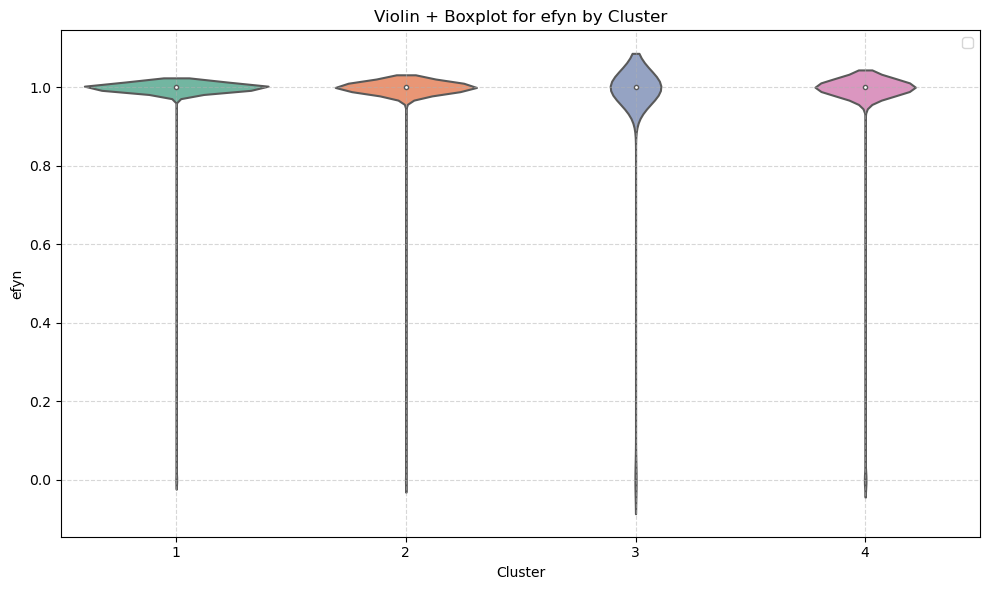

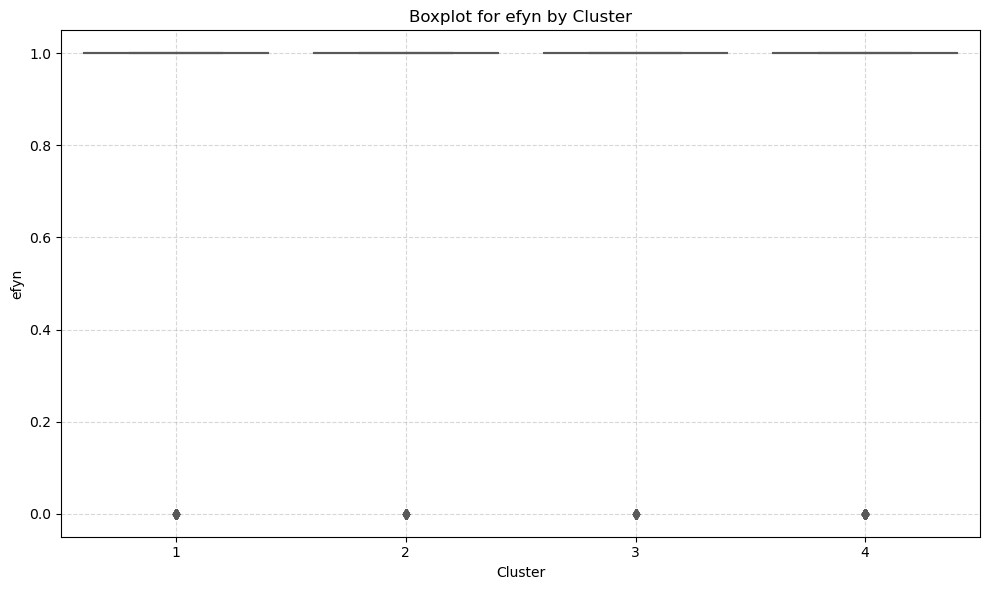

▶ Binary feature detected: efyn

▶ 값별 count:
efyn             0     1
Cluster_Labels          
1               42  8085
2               18  2939
3               13   537
4               98  6029

▶ 값별 비율(%):
efyn  Cluster_Labels     0      1
0                  1  0.52  99.48
1                  2  0.61  99.39
2                  3  2.36  97.64
3                  4  1.60  98.40


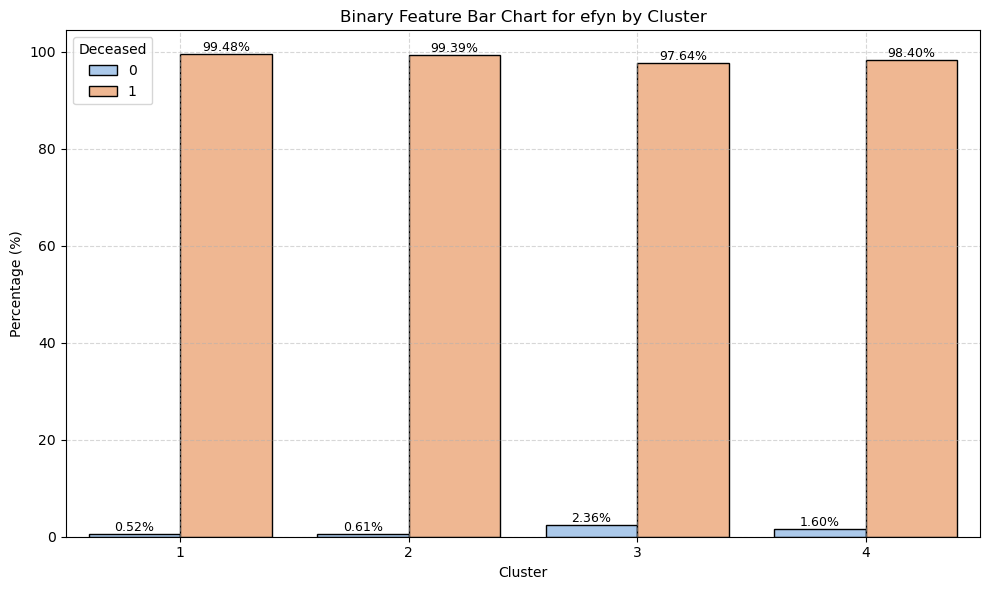

############################################################################################


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


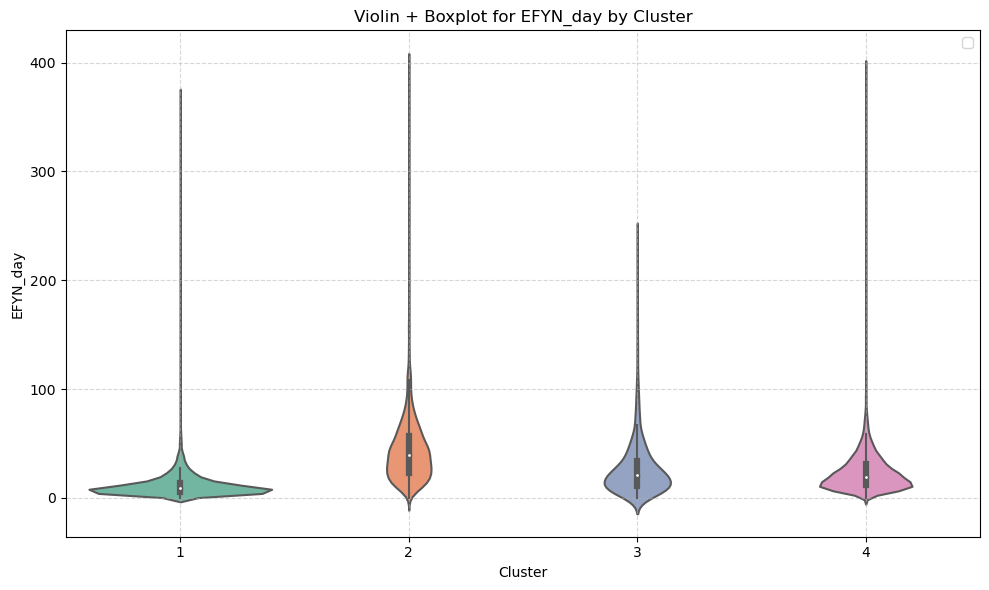

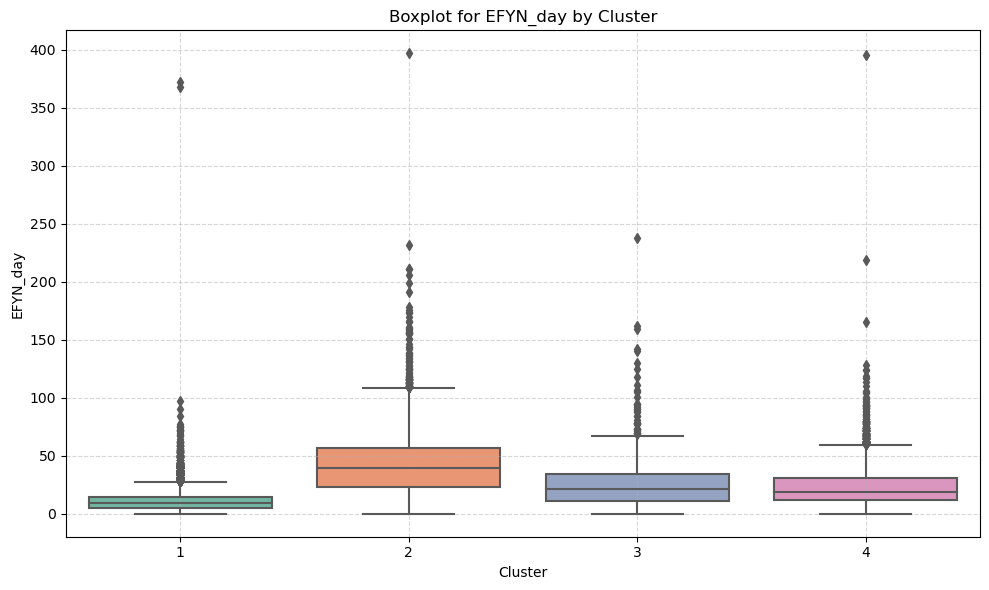

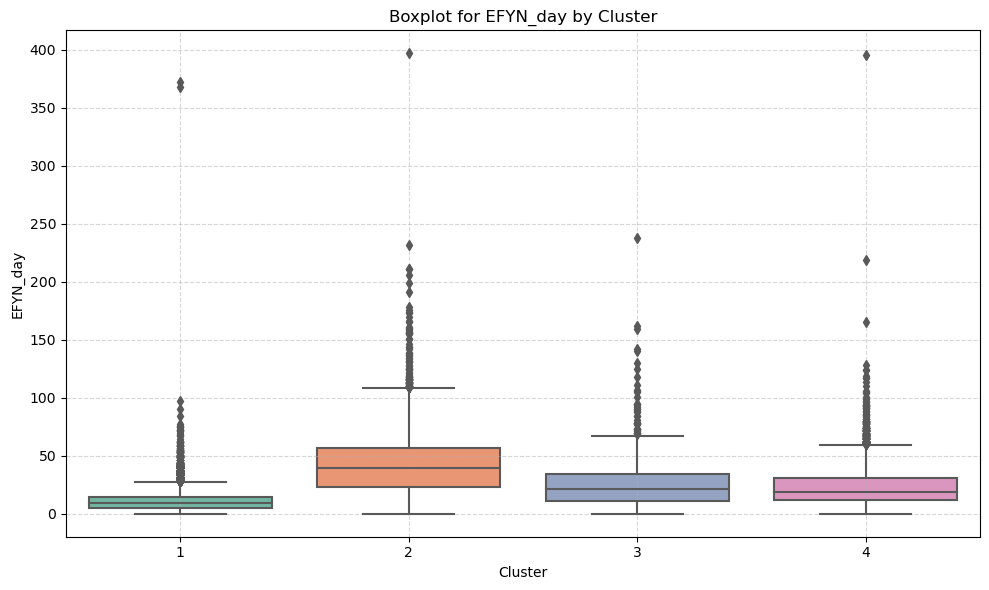

In [181]:
plot_violin_with_box(dfc, 'efyn')
plot_box_by_group(dfc, 'efyn')
plot_box_or_bar_by_group(dfc, 'efyn')
print('############################################################################################')
plot_violin_with_box(dfc, 'EFYN_day')
plot_box_by_group(dfc, 'EFYN_day')
plot_box_or_bar_by_group(dfc, 'EFYN_day')

In [182]:
# 특정 값 비율
def plot_value_counts_by_group(df, feature, value, tol=1e-4):
    # 전체 개수
    total_all = len(df)

    # 조건 필터링: ±0.0001 허용
    filtered = df[np.isclose(df[feature], value, atol=tol)]

    # 조건 만족 개수
    total_cond = len(filtered)
    percent = total_cond / total_all * 100
    print(f"\n▶ '{feature} ≈ {value}' (±{tol}) n with condition: {total_cond} / {total_all} ({percent:.3f}%)")

    # 값이 하나도 없으면 중단
    if total_cond == 0:
        print("No data with conditions")
        return

    # death_label 존재 여부 판단
    death_values = df['death_label'].unique()
    hue_flag = 'death_label' if len(death_values) > 1 else None

    result_df = pd.DataFrame()

    if hue_flag:
        # 조건 만족 수
        count_table = (
            filtered.groupby(['Cluster_Labels', 'death_label'])
            .size()
            .rename('n')
            .reset_index()
        )

        # 조건 만족자 그룹별 총합
        total_per_group = (
            filtered.groupby(['Cluster_Labels'])
            .size()
            .rename('group_total')
            .reset_index()
        )

        # 클러스터 전체 인원
        cluster_total_all = (
            df.groupby('Cluster_Labels')
            .size()
            .rename('cluster_total')
            .reset_index()
        )

        # merge
        merged = count_table.merge(total_per_group, on='Cluster_Labels')
        merged = merged.merge(cluster_total_all, on='Cluster_Labels')

        # 비율 계산
        merged['cond_percent'] = merged['n'] / merged['group_total'] * 100              # 조건 내 비율
        merged['group_percent'] = merged['group_total'] / merged['cluster_total'] * 100  # 클러스터 내 조건 만족 비율

        # 컬럼 순서 및 이름 정리
        result_df = merged[['Cluster_Labels', 'death_label', 'n', 'cond_percent', 'group_total', 'group_percent', 'cluster_total']].copy()
        result_df.columns = ['Cluster', 'Death_Label', 'Matched_n', 'Matched_Percent', 'Cluster_Matched_n', 'Cluster_Matched_Percent', 'Cluster_Total']

        # 출력
        print("\n▶ In detail :")
        print(result_df)

    else:
        count_series = filtered['Cluster_Labels'].value_counts().sort_index()
        cluster_total_all = df.groupby('Cluster_Labels').size()

        records = []
        for cluster, matched_n in count_series.items():
            cluster_total = cluster_total_all.get(cluster, 0)
            percent = matched_n / cluster_total * 100 if cluster_total > 0 else 0
            records.append({
                'Cluster': cluster,
                'Matched_n': matched_n,
                'Matched_Percent': 100.0,  # 단일 그룹이므로 항상 100%
                'Cluster_Matched_n': matched_n,
                'Cluster_Matched_Percent': percent,
                'Cluster_Total': cluster_total
            })

        result_df = pd.DataFrame(records)

        # 출력
        print("\n▶ n by cluster:")
        print(result_df.to_string(index=False, formatters={
            'Matched_Percent': '{:.1f}%'.format,
            'Cluster_Matched_Percent': '{:.1f}%'.format
        }))

    # 시각화
    plt.figure(figsize=(10, 6))
    ax = sns.countplot(x='Cluster_Labels', hue=hue_flag, data=filtered, palette='Set2')

    # bar 위에 % 표시
    if hue_flag:
        for _, row in result_df.iterrows():
            cluster = row['Cluster']
            death = row['Death_Label']
            count = row['Matched_n']
            percent = row['Matched_Percent']
            for bar in ax.patches:
                if bar.get_height() == count:
                    x = bar.get_x() + bar.get_width() / 2.
                    y = bar.get_height()
                    ax.annotate(f"{percent:.1f}%", (x, y), ha='center', va='bottom', fontsize=9)
                    break
    else:
        total_count = result_df['Cluster_Matched_n'].sum()
        for p in ax.patches:
            height = p.get_height()
            if height > 0:
                percent = height / total_count * 100
                ax.annotate(f"{percent:.1f}%", 
                            (p.get_x() + p.get_width() / 2., height), 
                            ha='center', va='bottom', fontsize=9)

    plt.title(f'Count of {feature} ≈ {value} by Cluster{" & Survival" if hue_flag else ""}')
    plt.xlabel('Cluster')
    plt.ylabel('Count')
    if hue_flag:
        plt.legend(title='Death Label')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    return result_df


▶ 'EFYN_day ≈ 21.56314' (±0.0001) n with condition: 171 / 17761 (0.963%)

▶ n by cluster:
 Cluster  Matched_n Matched_Percent  Cluster_Matched_n Cluster_Matched_Percent  Cluster_Total
       1         42          100.0%                 42                    0.5%           8127
       2         18          100.0%                 18                    0.6%           2957
       3         13          100.0%                 13                    2.4%            550
       4         98          100.0%                 98                    1.6%           6127


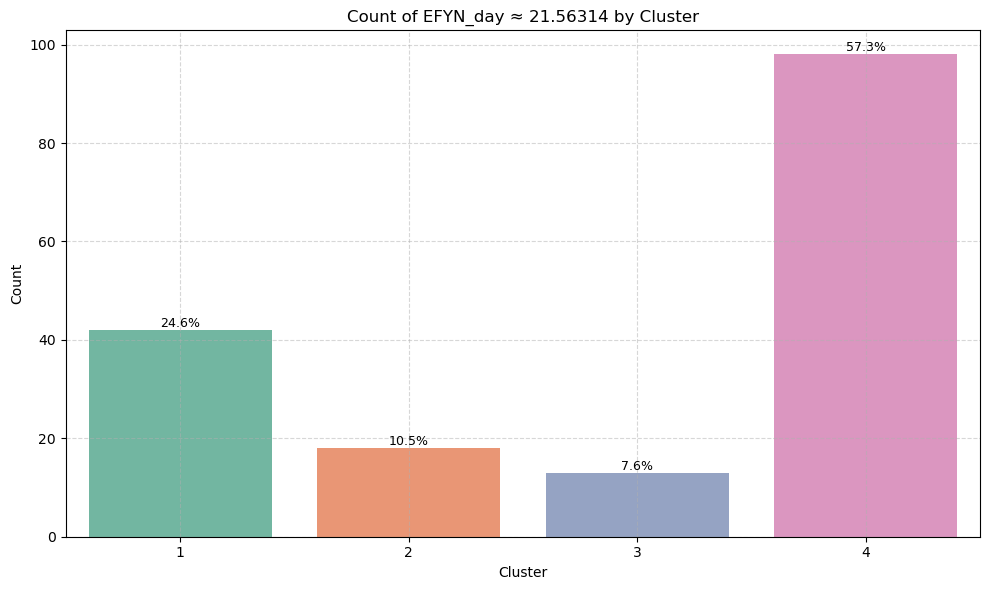

C:\Users\AIWM_W01\.conda\envs\Dev_AIWM\lib\site-packages\pandas\util\_decorators.py:211: FutureWarning: the 'encoding' keyword is deprecated and will be removed in a future version. Please take steps to stop the use of 'encoding'
  return func(*args, **kwargs)


In [183]:
# plot_value_counts_by_group(dfc, 'EFYN_day', 21.56314)
df_result = plot_value_counts_by_group(dfc, 'invfpod', 21.56314)
df_result.to_excel(os.path.join(path1, 'invfpod.xlsx')
                   , encoding='utf-8-sig'
                   , index=False
                  )

In [193]:
def plot_value_counts_by_group(df, feature, value, tol=1e-4):
    total_all = len(df)

    # 조건 필터링: ±tol 허용
    filtered = df[np.isclose(df[feature], value, atol=tol)]
    total_cond = len(filtered)
    percent = total_cond / total_all * 100

    print(f"\n▶ '{feature} ≈ {value}' (±{tol}) → {total_cond} / {total_all} ({percent:.3f}%)")

    if total_cond == 0:
        print("⚠️ 조건을 만족하는 데이터가 없습니다.")
        return pd.DataFrame()

    # 클러스터 기준 집계
    count_series = filtered['Cluster_Labels'].value_counts().sort_index()
    cluster_total_all = df.groupby('Cluster_Labels').size()

    records = []
    for cluster in cluster_total_all.index:
        matched_n = count_series.get(cluster, 0)
        cluster_total = cluster_total_all[cluster]
        percent = matched_n / cluster_total * 100 if cluster_total > 0 else 0
        records.append({
            'Cluster': cluster,
            'Matched_n': matched_n,
            'Cluster_Total': cluster_total,
            'Cluster_Percent': percent
        })

    result_df = pd.DataFrame(records)

    # 출력
    print("\n▶ 클러스터별 요약:")
    print(result_df.to_string(index=False, formatters={
        'Cluster_Percent': '{:.1f}%'.format
    }))

    # 시각화 (클러스터 내 비율 기준 퍼센트 표기)
    plt.figure(figsize=(10, 6))
    ax = sns.barplot(data=result_df, x='Cluster', y='Matched_n', palette='pastel')

    for i, row in result_df.iterrows():
        height = row['Matched_n']
        percent = row['Cluster_Percent']
        if height > 0:
            ax.annotate(f"{percent:.1f}%", 
                        (i, height), 
                        ha='center', va='bottom', fontsize=9)

    plt.title(f'Cluster-wise Count & Percent of {feature} ≈ {value}')
    plt.xlabel('Cluster')
    plt.ylabel('Matched Count')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    return result_df


▶ 'invfpod ≈ 0' (±0.0001) → 1316 / 17761 (7.409%)

▶ 클러스터별 요약:
 Cluster  Matched_n  Cluster_Total Cluster_Percent
       1       1199           8127           14.8%
       2          3           2957            0.1%
       3         33            550            6.0%
       4         81           6127            1.3%


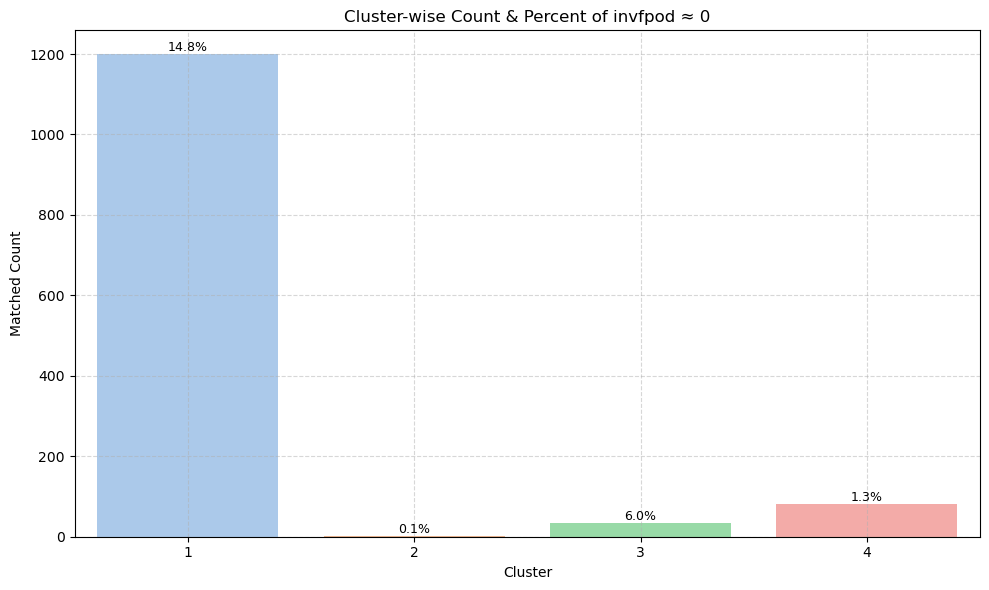

In [195]:
# plot_value_counts_by_group(dfc, 'EFYN_day', 21.56314)
dfr = plot_value_counts_by_group(dfc, 'invfpod', 0)
# df_result.to_excel(os.path.join(path1, 'ANA_EFYN_day.xlsx')
#                    , encoding='utf-8-sig'
#                    , index=False
#                   )

In [ ]:
## Colouring & Heatmap

In [21]:
ipt_dir = f'{crt_path}/Results/M15_dataset08/0711/WholeExp/C37'
# ipt_dir = f'{crt_path}/Results/M06_Modified-dth/3C_Opt-Silhouette'

df_ana = pd.read_csv(os.path.join(ipt_dir, "KNN_df_combined_wilcoxon+p_val.csv"))
df_ana = df_ana.rename(columns={'Unnamed: 0': 'col_name'})
df_ana

,col_name,Cluster 1,Cluster 10,Cluster 11,Cluster 12,Cluster 13,Cluster 14,Cluster 15,Cluster 16,Cluster 17,...,Cluster 34,Cluster 35,Cluster 36,Cluster 37,Cluster 4,Cluster 5,Cluster 6,Cluster 7,Cluster 8,Cluster 9
0,sex_sys_val,0.4431 ± 0.4969 (2.0200e-06),0.4562 ± 0.4984 (0.0061),0.5989 ± 0.4915 (n.s.),0.5745 ± 0.4950 (0.0020),0.5478 ± 0.4980 (0.0036),0.5315 ± 0.5000 (n.s.),0.4764 ± 0.5004 (n.s.),0.5545 ± 0.4983 (n.s.),0.4965 ± 0.5006 (n.s.),...,0.5361 ± 0.4993 (n.s.),0.5079 ± 0.5003 (n.s.),0.5784 ± 0.4950 (n.s.),0.4900 ± 0.5002 (n.s.),0.4337 ± 0.4962 (0.0053),0.4786 ± 0.5001 (n.s.),0.4651 ± 0.4989 (0.0019),0.5424 ± 0.4985 (n.s.),0.4561 ± 0.4987 (n.s.),0.4796 ± 0.5002 (n.s.)
1,apgs1,6.5208 ± 1.6449 (9.0965e-247),5.2913 ± 1.8245 (1.7332e-14),1.4393 ± 1.1676 (4.4881e-80),3.2408 ± 1.7013 (2.5209e-56),3.2330 ± 1.7127 (6.6100e-127),1.5295 ± 1.2027 (3.6236e-110),2.7904 ± 1.7614 (2.6919e-48),1.9740 ± 1.3740 (2.8164e-70),3.8219 ± 1.7247 (1.3025e-23),...,4.8858 ± 1.6528 (n.s.),4.7759 ± 1.6378 (n.s.),2.4461 ± 1.3176 (1.1635e-55),4.7450 ± 1.6470 (n.s.),6.1384 ± 1.7768 (3.1001e-39),5.9710 ± 1.5532 (2.4216e-41),5.6350 ± 1.6197 (4.6015e-71),5.2572 ± 1.7870 (5.3556e-13),5.1390 ± 1.6979 (0.0002),5.2577 ± 1.7555 (3.6511e-07)
2,apgs5,8.3195 ± 1.1097 (4.6072e-231),7.4511 ± 1.4525 (1.1180e-14),2.5476 ± 1.8635 (7.0372e-94),5.6887 ± 1.8048 (1.5810e-52),5.5514 ± 1.9974 (1.9163e-121),3.2396 ± 2.0597 (1.4225e-112),5.4367 ± 1.9983 (1.9770e-35),3.7673 ± 2.0026 (8.1479e-79),6.1389 ± 1.8410 (7.0008e-22),...,7.1034 ± 1.3679 (n.s.),7.0051 ± 1.3680 (n.s.),4.7696 ± 1.6964 (1.5595e-56),7.0667 ± 1.3102 (n.s.),8.0778 ± 1.1921 (3.0542e-40),7.8939 ± 1.1145 (5.7392e-35),7.6449 ± 1.2862 (1.2322e-55),7.4114 ± 1.3635 (2.8867e-11),7.4195 ± 1.2171 (2.6975e-05),7.3212 ± 1.3183 (0.0009)
3,bwei,1339.0804 ± 170.9032 (5.6573e-261),1202.4636 ± 217.6130 (2.8208e-25),776.1808 ± 317.6182 (1.3531e-34),771.7516 ± 276.2564 (8.2217e-100),756.3314 ± 261.6316 (8.8298e-250),806.3543 ± 289.9431 (4.9030e-46),1173.0669 ± 253.3919 (4.2099e-05),808.4257 ± 239.9218 (2.7080e-39),885.7819 ± 221.7904 (9.0994e-51),...,1163.9183 ± 209.7184 (1.8706e-05),1071.5772 ± 221.4961 (0.0010),950.8725 ± 231.6457 (2.6790e-13),1060.0027 ± 231.2020 (2.6761e-05),1323.3469 ± 161.0134 (3.6026e-60),1198.5927 ± 233.9882 (7.6179e-16),1289.8320 ± 203.9823 (4.4627e-159),1269.0505 ± 205.8654 (4.7637e-73),1262.7902 ± 231.4429 (3.5140e-30),1246.6199 ± 209.1421 (1.7110e-25)
4,mage,34.0368 ± 3.8500 (1.7672e-08),32.3243 ± 4.7826 (4.8557e-13),32.5085 ± 4.6954 (n.s.),33.4384 ± 4.2360 (n.s.),33.1287 ± 4.7218 (n.s.),34.0433 ± 4.4404 (n.s.),32.8583 ± 4.3206 (n.s.),33.1485 ± 4.3990 (n.s.),34.4153 ± 4.1776 (1.9748e-05),...,32.9399 ± 4.3151 (0.0029),32.7277 ± 4.3644 (1.3470e-06),32.8676 ± 3.7897 (n.s.),33.4003 ± 4.3781 (n.s.),32.9107 ± 4.6239 (n.s.),32.8758 ± 4.1195 (0.0026),33.7075 ± 3.8471 (0.0062),32.7408 ± 4.3899 (3.8593e-07),35.7878 ± 4.6318 (1.0469e-27),33.0051 ± 4.4784 (n.s.)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143,iperr_4,0.0000 ± 0.0000 (n.s.),0.0000 ± 0.0000 (n.s.),0.0000 ± 0.0000 (n.s.),0.0000 ± 0.0000 (n.s.),0.0000 ± 0.0000 (n.s.),0.0000 ± 0.0000 (n.s.),0.0000 ± 0.0000 (n.s.),0.0000 ± 0.0000 (n.s.),0.0000 ± 0.0000 (n.s.),...,0.0000 ± 0.0000 (n.s.),0.0000 ± 0.0000 (n.s.),0.0049 ± 0.0700 (0.0004),0.0000 ± 0.0000 (n.s.),0.0000 ± 0.0000 (n.s.),0.0000 ± 0.0000 (n.s.),0.0000 ± 0.0000 (n.s.),0.0000 ± 0.0000 (n.s.),0.0000 ± 0.0000 (n.s.),0.0000 ± 0.0000 (n.s.)
144,iperroy_1,0.9972 ± 0.0526 (1.8083e-07),0.9926 ± 0.0857 (0.0033),1.0000 ± 0.0000 (n.s.),0.9568 ± 0.2035 (0.0022),0.9542 ± 0.2092 (1.8458e-07),0.9882 ± 0.1082 (n.s.),0.9921 ± 0.0886 (n.s.),0.9257 ± 0.2628 (5.3223e-07),0.9652 ± 0.1835 (n.s.),...,0.9904 ± 0.0977 (n.s.),0.9804 ± 0.1388 (n.s.),0.9706 ± 0.1694 (n.s.),0.9826 ± 0.1309 (n.s.),0.9974 ± 0.0505 (0.0074),0.9898 ± 0.1005 (n.s.),0.9974 ± 0.0513 (6.5677e-08),0.9931 ± 0.0827 (0.0016),1.0000 ± 0.0000 (0.0020),0.9974 ± 0.0505 (0.0074)
145,iperroy_4,0.0007 ± 0.0263 (n

In [22]:
m10c5 = f'{base}/1212_M02/creatures/Results/M15_dataset08/1_Whole/1_ALL/C4'
df_dic = pd.read_excel(os.path.join(m10c5, "C4_ana+description.xlsx"))
df_dic = df_dic[['eCRF명', '항목명', 'col_name']]
df_dic.rename(columns={'col_name': 'col_name+'}, inplace=True)
df_dic = df_dic.iloc[1:].reset_index(drop=True)
df_dic

# df_dic = pd.read_excel(os.path.join(cbk, "KNN 코드북 및 안내문_20241212정리.xlsx"), sheet_name="코드북(iCReaT eCRF_ver4)")
# df_dic = df_dic[['eCRF명', '항목명', '변수명', '코드리스트']]
# df_dic

,eCRF명,항목명,col_name+
0,NaN,성별 (Male),sex_sys_val
1,"임신, 분만, 신생아 정보",1분 아프가 점수,apgs1
2,"임신, 분만, 신생아 정보",5분 아프가 점수,apgs5
3,"임신, 분만, 신생아 정보",출생 체중,bwei
4,Eligibility evaluation & Demographic,산모 나이(Maternal age),mage
...,...,...,...
146,질환 관련 정보(Ⅲ),특발성 장천공 수술 여부 및 종류 (Drain),iperroy_2
147,NaN,NaN,Decease / Total (%)
148,NaN,NaN,IBP (Pos) / Total (%)
149,NaN,NaN,NEC (Pos) / Total (%)


In [23]:
df_merged = pd.merge(df_ana
                     , df_dic[['col_name+', 'eCRF명', '항목명']]
                     , how='left'
                     , left_on='col_name', right_on='col_name+'
                    )
df_merged.drop(columns='col_name+', inplace=True)
original_cols = df_ana.columns.tolist()
df_merged = df_merged[['eCRF명', '항목명'] + original_cols]

df_merged

,eCRF명,항목명,col_name,Cluster 1,Cluster 10,Cluster 11,Cluster 12,Cluster 13,Cluster 14,Cluster 15,...,Cluster 34,Cluster 35,Cluster 36,Cluster 37,Cluster 4,Cluster 5,Cluster 6,Cluster 7,Cluster 8,Cluster 9
0,NaN,성별 (Male),sex_sys_val,0.4431 ± 0.4969 (2.0200e-06),0.4562 ± 0.4984 (0.0061),0.5989 ± 0.4915 (n.s.),0.5745 ± 0.4950 (0.0020),0.5478 ± 0.4980 (0.0036),0.5315 ± 0.5000 (n.s.),0.4764 ± 0.5004 (n.s.),...,0.5361 ± 0.4993 (n.s.),0.5079 ± 0.5003 (n.s.),0.5784 ± 0.4950 (n.s.),0.4900 ± 0.5002 (n.s.),0.4337 ± 0.4962 (0.0053),0.4786 ± 0.5001 (n.s.),0.4651 ± 0.4989 (0.0019),0.5424 ± 0.4985 (n.s.),0.4561 ± 0.4987 (n.s.),0.4796 ± 0.5002 (n.s.)
1,"임신, 분만, 신생아 정보",1분 아프가 점수,apgs1,6.5208 ± 1.6449 (9.0965e-247),5.2913 ± 1.8245 (1.7332e-14),1.4393 ± 1.1676 (4.4881e-80),3.2408 ± 1.7013 (2.5209e-56),3.2330 ± 1.7127 (6.6100e-127),1.5295 ± 1.2027 (3.6236e-110),2.7904 ± 1.7614 (2.6919e-48),...,4.8858 ± 1.6528 (n.s.),4.7759 ± 1.6378 (n.s.),2.4461 ± 1.3176 (1.1635e-55),4.7450 ± 1.6470 (n.s.),6.1384 ± 1.7768 (3.1001e-39),5.9710 ± 1.5532 (2.4216e-41),5.6350 ± 1.6197 (4.6015e-71),5.2572 ± 1.7870 (5.3556e-13),5.1390 ± 1.6979 (0.0002),5.2577 ± 1.7555 (3.6511e-07)
2,"임신, 분만, 신생아 정보",5분 아프가 점수,apgs5,8.3195 ± 1.1097 (4.6072e-231),7.4511 ± 1.4525 (1.1180e-14),2.5476 ± 1.8635 (7.0372e-94),5.6887 ± 1.8048 (1.5810e-52),5.5514 ± 1.9974 (1.9163e-121),3.2396 ± 2.0597 (1.4225e-112),5.4367 ± 1.9983 (1.9770e-35),...,7.1034 ± 1.3679 (n.s.),7.0051 ± 1.3680 (n.s.),4.7696 ± 1.6964 (1.5595e-56),7.0667 ± 1.3102 (n.s.),8.0778 ± 1.1921 (3.0542e-40),7.8939 ± 1.1145 (5.7392e-35),7.6449 ± 1.2862 (1.2322e-55),7.4114 ± 1.3635 (2.8867e-11),7.4195 ± 1.2171 (2.6975e-05),7.3212 ± 1.3183 (0.0009)
3,"임신, 분만, 신생아 정보",출생 체중,bwei,1339.0804 ± 170.9032 (5.6573e-261),1202.4636 ± 217.6130 (2.8208e-25),776.1808 ± 317.6182 (1.3531e-34),771.7516 ± 276.2564 (8.2217e-100),756.3314 ± 261.6316 (8.8298e-250),806.3543 ± 289.9431 (4.9030e-46),1173.0669 ± 253.3919 (4.2099e-05),...,1163.9183 ± 209.7184 (1.8706e-05),1071.5772 ± 221.4961 (0.0010),950.8725 ± 231.6457 (2.6790e-13),1060.0027 ± 231.2020 (2.6761e-05),1323.3469 ± 161.0134 (3.6026e-60),1198.5927 ± 233.9882 (7.6179e-16),1289.8320 ± 203.9823 (4.4627e-159),1269.0505 ± 205.8654 (4.7637e-73),1262.7902 ± 231.4429 (3.5140e-30),1246.6199 ± 209.1421 (1.7110e-25)
4,Eligibility evaluation & Demographic,산모 나이(Maternal age),mage,34.0368 ± 3.8500 (1.7672e-08),32.3243 ± 4.7826 (4.8557e-13),32.5085 ± 4.6954 (n.s.),33.4384 ± 4.2360 (n.s.),33.1287 ± 4.7218 (n.s.),34.0433 ± 4.4404 (n.s.),32.8583 ± 4.3206 (n.s.),...,32.9399 ± 4.3151 (0.0029),32.7277 ± 4.3644 (1.3470e-06),32.8676 ± 3.7897 (n.s.),33.4003 ± 4.3781 (n.s.),32.9107 ± 4.6239 (n.s.),32.8758 ± 4.1195 (0.0026),33.7075 ± 3.8471 (0.0062),32.7408 ± 4.3899 (3.8593e-07),35.7878 ± 4.6318 (1.0469e-27),33.0051 ± 4.4784 (n.s.)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143,질환 관련 정보(Ⅲ),특발성 장천공 (수술 위해 타원 전원),iperr_4,0.0000 ± 0.0000 (n.s.),0.0000 ± 0.0000 (n.s.),0.0000 ± 0.0000 (n.s.),0.0000 ± 0.0000 (n.s.),0.0000 ± 0.0000 (n.s.),0.0000 ± 0.0000 (n.s.),0.0000 ± 0.0000 (n.s.),...,0.0000 ± 0.0000 (n.s.),0.0000 ± 0.0000 (n.s.),0.0049 ± 0.0700 (0.0004),0.0000 ± 0.0000 (n.s.),0.0000 ± 0.0000 (n.s.),0.0000 ± 0.0000 (n.s.),0.0000 ± 0.0000 (n.s.),0.0000 ± 0.0000 (n.s.),0.0000 ± 0.0000 (n.s.),0.0000 ± 0.0000 (n.s.)
144,질환 관련 정보(Ⅲ),특발성 장천공 수술 여부 및 종류 (Neg),iperroy_1,0.9972 ± 0.0526 (1.8083e-07),0.9926 ± 0.0857 (0.0033),1.0000 ± 0.0000 (n.s.),0.9568 ± 0.2035 (0.0022),0.9542 ± 0.2092 (1.8458e-07),0.9882 ± 0.1082 (n.s.),0.9921 ± 0.0886 (n.s.),...,0.9904 ± 0.0977 (n.s.),0.9804 ± 0.1388 (n.s.),0.9706 ± 0.1694 (n.s.),0.9826 ± 0.1309 (n.s.),0.9974 ± 0.0505 (0.0074),0.9898 ± 0.1005 (n.s.),0.9974 ± 0.0513 (6.5677e-08),0.9931 ± 0.0827 (0.0016),1.0000 ± 0.0000 (0.0020),0.9974 ± 0.0505 (0.0074)
145,질환 관련 정보(Ⅲ),특발성 장천공 수술 여부 및 종류 (Drain 후 Laparotomy),iperroy_4,0.0007 ± 0.0263 (n.s.),0.0000 ± 0.0000 (n.s.),0.0000 ± 0.0000 (n.s.),0.0086 ± 0.0926 (n.s.),0.0088 ± 0.0933 (0.0002),0.0000 ± 0.0000 (n.s.)

In [24]:
df_merged.to_excel(os.path.join(ipt_dir, "C4_ana+description.xlsx")
                   , encoding='utf-8-sig'
                   , index=False
                  )

C:\Users\AIWM_W01\.conda\envs\Dev_AIWM\lib\site-packages\pandas\util\_decorators.py:211: FutureWarning: the 'encoding' keyword is deprecated and will be removed in a future version. Please take steps to stop the use of 'encoding'
  return func(*args, **kwargs)


In [ ]:
## cat_name, sorting

In [44]:
# ipt_dir = f'{crt_path}/Results/M15_dataset08/2_SurvOnly/1_ALL/C4'
# ipt_dir = f'{crt_path}/Results/M06_Modified-dth/3C_Opt-Silhouette'
# ipt_dir = f'{crt_path}/Results/M15_dataset08/0531~/WholeExp/C43'
ipt_dir = f'{crt_path}/Results/M15_dataset08/0711/WholeExp/C37'

df_ana = pd.read_excel(os.path.join(ipt_dir, "C4_ana+description.xlsx"))
# assert df_ana['col_name'].is_unique
# df_ana = df_ana.rename(columns={'Unnamed: 0': 'col_name'})
df_ana

,eCRF명,항목명,col_name,Cluster 1,Cluster 2,Cluster 3,Cluster 4,Cluster 5,Cluster 6,Cluster 7,...,Cluster 28,Cluster 29,Cluster 30,Cluster 31,Cluster 32,Cluster 33,Cluster 34,Cluster 35,Cluster 36,Cluster 37
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,성별 (Male),sex_sys_val,0.4431 ± 0.4969 (2.0200e-06),0.4412 ± 0.4971 (0.0076),0.4457 ± 0.4972 (2.8733e-06),0.4337 ± 0.4962 (0.0053),0.4786 ± 0.5001 (n.s.),0.4651 ± 0.4989 (0.0019),0.5424 ± 0.4985 (n.s.),...,0.4813 ± 0.5000 (n.s.),0.6070 ± 0.4894 (0.0008),0.4825 ± 0.5001 (n.s.),0.5459 ± 0.4982 (n.s.),0.4457 ± 0.4984 (n.s.),0.5370 ± 0.4991 (n.s.),0.5361 ± 0.4993 (n.s.),0.5079 ± 0.5003 (n.s.),0.5784 ± 0.4950 (n.s.),0.4900 ± 0.5002 (n.s.)
2,"임신, 분만, 신생아 정보",1분 아프가 점수,apgs1,6.5208 ± 1.6449 (9.0965e-247),6.5521 ± 1.6354 (4.7232e-76),6.4447 ± 1.7294 (3.3870e-235),6.1384 ± 1.7768 (3.1001e-39),5.9710 ± 1.5532 (2.4216e-41),5.6350 ± 1.6197 (4.6015e-71),5.2572 ± 1.7870 (5.3556e-13),...,4.3947 ± 1.8178 (1.7997e-08),3.9942 ± 1.6772 (1.6705e-10),4.9650 ± 1.7119 (n.s.),4.2990 ± 1.7313 (2.9640e-11),4.7087 ± 1.5360 (n.s.),4.1775 ± 1.8982 (6.3390e-11),4.8858 ± 1.6528 (n.s.),4.7759 ± 1.6378 (n.s.),2.4461 ± 1.3176 (1.1635e-55),4.7450 ± 1.6470 (n.s.)
3,"임신, 분만, 신생아 정보",5분 아프가 점수,apgs5,8.3195 ± 1.1097 (4.6072e-231),8.3659 ± 1.1082 (2.1897e-76),8.3395 ± 1.1586 (3.7144e-254),8.0778 ± 1.1921 (3.0542e-40),7.8939 ± 1.1145 (5.7392e-35),7.6449 ± 1.2862 (1.2322e-55),7.4114 ± 1.3635 (2.8867e-11),...,6.8375 ± 1.5865 (0.0017),6.6181 ± 1.6352 (3.6722e-05),7.1941 ± 1.3889 (n.s.),6.5521 ± 1.5198 (4.2276e-17),6.9950 ± 1.0996 (0.0049),6.4101 ± 1.7009 (2.1655e-15),7.1034 ± 1.3679 (n.s.),7.0051 ± 1.3680 (n.s.),4.7696 ± 1.6964 (1.5595e-56),7.0667 ± 1.3102 (n.s.)
4,"임신, 분만, 신생아 정보",출생 체중,bwei,1339.0804 ± 170.9032 (5.6573e-261),1379.6475 ± 171.3987 (4.4118e-104),1316.0454 ± 167.9028 (5.9574e-226),1323.3469 ± 161.0134 (3.6026e-60),1198.5927 ± 233.9882 (7.6179e-16),1289.8320 ± 203.9823 (4.4627e-159),1269.0505 ± 205.8654 (4.7637e-73),...,1039.2010 ± 244.7970 (3.6831e-11),1010.1089 ± 240.9209 (2.2389e-07),1105.6171 ± 242.3938 (n.s.),1021.0533 ± 244.5630 (3.6640e-15),1095.8370 ± 236.9577 (n.s.),1060.8541 ± 232.0083 (0.0009),1163.9183 ± 209.7184 (1.8706e-05),1071.5772 ± 221.4961 (0.0010),950.8725 ± 231.6457 (2.6790e-13),1060.0027 ± 231.2020 (2.6761e-05)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
147,질환 관련 정보(Ⅲ),특발성 장천공 수술 여부 및 종류 (Drain),iperroy_2,0.0000 ± 0.0000 (n.s.),0.0000 ± 0.0000 (n.s.),0.0000 ± 0.0000 (n.s.),0.0000 ± 0.0000 (n.s.),0.0000 ± 0.0000 (n.s.),0.0000 ± 0.0000 (n.s.),0.0011 ± 0.0339 (n.s.),...,0.0000 ± 0.0000 (n.s.),0.0000 ± 0.0000 (n.s.),0.0000 ± 0.0000 (n.s.),0.0000 ± 0.0000 (n.s.),0.0054 ± 0.0737 (n.s.),0.0019 ± 0.0441 (n.s.),0.0000 ± 0.0000 (n.s.),0.0000 ± 0.0000 (n.s.),0.0000 ± 0.0000 (n.s.),0.0000 ± 0.0000 (n.s.)
148,NaN,NaN,Decease / Total (%),4 / 1442 (0.28%),2 / 451 (0.44%),5 / 1519 (0.33%),7 / 392 (1.79%),29 / 491 (5.91%),11 / 1518 (0.72%),25 / 872 (2.87%),...,7 / 831 (0.84%),3 / 257 (1.17%),3 / 572 (0.52%),27 / 806 (3.35%),27 / 184 (14.67%),11 / 514 (2.14%),2 / 416 (0.48%),9 / 764 (1.18%),6 / 204 (2.94%),13 / 747 (1.74%)
149,NaN,NaN,IBP (Pos) / Total (%),4 / 1442 (0.28%),0 / 451 (0.00%),2 / 1519 (0.13%),1 / 392 (0.26%),5 / 491 (1.02%),4 / 1518 (0.26%),6 / 872 (0.69%),...,6 / 831 (0.72%),7 / 257 (2.72%),8 / 572 (1.40%),21 / 806 (2.61%),7 / 184 (3.80%),11 / 514 (2.14%),4 / 416 (0.96%),15 / 764 (1.96%),6 / 204 (2.94%),13 / 747 (1.74%)
150,NaN,NaN,NEC (Pos) / Total (%),14 / 1442 (0.97%),7 / 451 (1.55%),15 / 1519 (0.99%),7 / 392 (1.79%),39 / 491 (7.94%),23 / 1518 (1.52%),18 / 872 (2.06%),...,51 / 831 (6.14%),24 / 257 (9.34%),22 / 572 (3.85%),49 / 806 (6.08%),15 / 184 (8.15%),38 / 514 (7.39%),13 / 416 (3.12%),42 / 764 (5.50%),16 / 204 (7.84%),34 / 747 (4.55%)


In [45]:
ctnm = f'{base}/1212_M02/creatures/Results/M13'    # 분석용, 건들지 말 것
df_dic = pd.read_excel(os.path.join(ctnm, "list_4_sort(features).xlsx"))
# df_dic = df_dic[['eCRF명', '항목명', 'col_name']]
# df_dic.rename(columns={'col_name': 'col_name+'}, inplace=True)
# df_dic = df_dic.iloc[1:].reset_index(drop=True)
df_dic

,cat_name,eCRF명,항목명,col_name
0,Perinatal factors,"임신, 분만, 신생아 정보",산전스테로이드 유무 (Pos),ster_1
1,Perinatal factors,"임신, 분만, 신생아 정보",산전스테로이드 유무 (Neg),ster_0
2,Perinatal factors,"임신, 분만, 신생아 정보",산전스테로이드 유무 (Unknown),ster_Unknown
3,Perinatal factors,"임신, 분만, 신생아 정보",산전 항생제 사용 여부 (Pos),atbyn_1
4,Perinatal factors,"임신, 분만, 신생아 정보",산전 항생제 사용 여부 (Neg),atbyn_0
...,...,...,...,...
142,Reason of Death,NaN,사망 원인 : Neurological,death_NL
143,Reason of Death,NaN,사망 원인 : Infection,death_Inf
144,Reason of Death,NaN,사망 원인 : Gastrointestinal,death_GI
145,Reason of Death,NaN,사망 원인 : Congenital anomalies,death_CA


In [46]:
df_dic_sel = df_dic[['col_name', 'cat_name']].drop_duplicates(subset='col_name')

# merge 실행
df_merged = pd.merge(df_ana
                     , df_dic_sel
                     , how='left'
                     , on='col_name'      # 기준 키: col_name
                    )

original_cols = df_ana.columns.tolist()
df_merged = df_merged[['cat_name'] + original_cols]

df_merged

,cat_name,eCRF명,항목명,col_name,Cluster 1,Cluster 2,Cluster 3,Cluster 4,Cluster 5,Cluster 6,...,Cluster 28,Cluster 29,Cluster 30,Cluster 31,Cluster 32,Cluster 33,Cluster 34,Cluster 35,Cluster 36,Cluster 37
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Et cetra,NaN,성별 (Male),sex_sys_val,0.4431 ± 0.4969 (2.0200e-06),0.4412 ± 0.4971 (0.0076),0.4457 ± 0.4972 (2.8733e-06),0.4337 ± 0.4962 (0.0053),0.4786 ± 0.5001 (n.s.),0.4651 ± 0.4989 (0.0019),...,0.4813 ± 0.5000 (n.s.),0.6070 ± 0.4894 (0.0008),0.4825 ± 0.5001 (n.s.),0.5459 ± 0.4982 (n.s.),0.4457 ± 0.4984 (n.s.),0.5370 ± 0.4991 (n.s.),0.5361 ± 0.4993 (n.s.),0.5079 ± 0.5003 (n.s.),0.5784 ± 0.4950 (n.s.),0.4900 ± 0.5002 (n.s.)
2,Infants' birth,"임신, 분만, 신생아 정보",1분 아프가 점수,apgs1,6.5208 ± 1.6449 (9.0965e-247),6.5521 ± 1.6354 (4.7232e-76),6.4447 ± 1.7294 (3.3870e-235),6.1384 ± 1.7768 (3.1001e-39),5.9710 ± 1.5532 (2.4216e-41),5.6350 ± 1.6197 (4.6015e-71),...,4.3947 ± 1.8178 (1.7997e-08),3.9942 ± 1.6772 (1.6705e-10),4.9650 ± 1.7119 (n.s.),4.2990 ± 1.7313 (2.9640e-11),4.7087 ± 1.5360 (n.s.),4.1775 ± 1.8982 (6.3390e-11),4.8858 ± 1.6528 (n.s.),4.7759 ± 1.6378 (n.s.),2.4461 ± 1.3176 (1.1635e-55),4.7450 ± 1.6470 (n.s.)
3,Infants' birth,"임신, 분만, 신생아 정보",5분 아프가 점수,apgs5,8.3195 ± 1.1097 (4.6072e-231),8.3659 ± 1.1082 (2.1897e-76),8.3395 ± 1.1586 (3.7144e-254),8.0778 ± 1.1921 (3.0542e-40),7.8939 ± 1.1145 (5.7392e-35),7.6449 ± 1.2862 (1.2322e-55),...,6.8375 ± 1.5865 (0.0017),6.6181 ± 1.6352 (3.6722e-05),7.1941 ± 1.3889 (n.s.),6.5521 ± 1.5198 (4.2276e-17),6.9950 ± 1.0996 (0.0049),6.4101 ± 1.7009 (2.1655e-15),7.1034 ± 1.3679 (n.s.),7.0051 ± 1.3680 (n.s.),4.7696 ± 1.6964 (1.5595e-56),7.0667 ± 1.3102 (n.s.)
4,Infants' birth,"임신, 분만, 신생아 정보",출생 체중,bwei,1339.0804 ± 170.9032 (5.6573e-261),1379.6475 ± 171.3987 (4.4118e-104),1316.0454 ± 167.9028 (5.9574e-226),1323.3469 ± 161.0134 (3.6026e-60),1198.5927 ± 233.9882 (7.6179e-16),1289.8320 ± 203.9823 (4.4627e-159),...,1039.2010 ± 244.7970 (3.6831e-11),1010.1089 ± 240.9209 (2.2389e-07),1105.6171 ± 242.3938 (n.s.),1021.0533 ± 244.5630 (3.6640e-15),1095.8370 ± 236.9577 (n.s.),1060.8541 ± 232.0083 (0.0009),1163.9183 ± 209.7184 (1.8706e-05),1071.5772 ± 221.4961 (0.0010),950.8725 ± 231.6457 (2.6790e-13),1060.0027 ± 231.2020 (2.6761e-05)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
147,GI & nutrition,질환 관련 정보(Ⅲ),특발성 장천공 수술 여부 및 종류 (Drain),iperroy_2,0.0000 ± 0.0000 (n.s.),0.0000 ± 0.0000 (n.s.),0.0000 ± 0.0000 (n.s.),0.0000 ± 0.0000 (n.s.),0.0000 ± 0.0000 (n.s.),0.0000 ± 0.0000 (n.s.),...,0.0000 ± 0.0000 (n.s.),0.0000 ± 0.0000 (n.s.),0.0000 ± 0.0000 (n.s.),0.0000 ± 0.0000 (n.s.),0.0054 ± 0.0737 (n.s.),0.0019 ± 0.0441 (n.s.),0.0000 ± 0.0000 (n.s.),0.0000 ± 0.0000 (n.s.),0.0000 ± 0.0000 (n.s.),0.0000 ± 0.0000 (n.s.)
148,NaN,NaN,NaN,Decease / Total (%),4 / 1442 (0.28%),2 / 451 (0.44%),5 / 1519 (0.33%),7 / 392 (1.79%),29 / 491 (5.91%),11 / 1518 (0.72%),...,7 / 831 (0.84%),3 / 257 (1.17%),3 / 572 (0.52%),27 / 806 (3.35%),27 / 184 (14.67%),11 / 514 (2.14%),2 / 416 (0.48%),9 / 764 (1.18%),6 / 204 (2.94%),13 / 747 (1.74%)
149,NaN,NaN,NaN,IBP (Pos) / Total (%),4 / 1442 (0.28%),0 / 451 (0.00%),2 / 1519 (0.13%),1 / 392 (0.26%),5 / 491 (1.02%),4 / 1518 (0.26%),...,6 / 831 (0.72%),7 / 257 (2.72%),8 / 572 (1.40%),21 / 806 (2.61%),7 / 184 (3.80%),11 / 514 (2.14%),4 / 416 (0.96%),15 / 764 (1.96%),6 / 204 (2.94%),13 / 747 (1.74%)
150,NaN,NaN,NaN,NEC (Pos) / Total (%),14 / 1442 (0.97%),7 / 451 (1.55%),15 / 1519 (0.99%),7 / 392 (1.79%),39 / 491 (7.94%),23 / 1518 (1.52%),...,51 / 831 (6.14%),24 / 257 (9.34%),22 / 572 (3.85%),49 / 806 (6.08%),15 / 184 (8.15%),38 / 514 (7.39%),13 / 416 (3.12%),42 / 764 (5.50%),16 / 204 (7.84%),34 / 747 (4.55%)


In [47]:
# 1) df_dic에서 col_name 순서를 리스트로 만들기
order_list = df_dic['col_name'].dropna().unique().tolist()
rank_map = {cname: i for i, cname in enumerate(order_list)}  # {col_name: index}

# 2) 특수 5행에 대한 우선순위 부여
#    - {인덱스: 우선순위} 형태. 0,141,142,143,144는 0~4로 설정
special_index_map = {0:0, 148:1, 149:2, 150:3, 151:4}

# 3) df_merged에 임시열(special_rank, col_rank) 추가
df_merged['special_rank'] = df_merged.index.map(lambda x: special_index_map.get(x, 9999))
df_merged['col_rank'] = df_merged['col_name'].map(lambda c: rank_map.get(c, 9999))

# 4) 정렬: (1) special_rank 오름차순 -> (2) col_rank 오름차순
df_merged.sort_values(['special_rank', 'col_rank'], inplace=True)

# 5) 임시열 제거 + 인덱스 리셋
df_merged.drop(['special_rank', 'col_rank'], axis=1, inplace=True)
df_merged.reset_index(drop=True, inplace=True)

df_merged

,cat_name,eCRF명,항목명,col_name,Cluster 1,Cluster 2,Cluster 3,Cluster 4,Cluster 5,Cluster 6,...,Cluster 28,Cluster 29,Cluster 30,Cluster 31,Cluster 32,Cluster 33,Cluster 34,Cluster 35,Cluster 36,Cluster 37
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,Decease / Total (%),4 / 1442 (0.28%),2 / 451 (0.44%),5 / 1519 (0.33%),7 / 392 (1.79%),29 / 491 (5.91%),11 / 1518 (0.72%),...,7 / 831 (0.84%),3 / 257 (1.17%),3 / 572 (0.52%),27 / 806 (3.35%),27 / 184 (14.67%),11 / 514 (2.14%),2 / 416 (0.48%),9 / 764 (1.18%),6 / 204 (2.94%),13 / 747 (1.74%)
2,NaN,NaN,NaN,IBP (Pos) / Total (%),4 / 1442 (0.28%),0 / 451 (0.00%),2 / 1519 (0.13%),1 / 392 (0.26%),5 / 491 (1.02%),4 / 1518 (0.26%),...,6 / 831 (0.72%),7 / 257 (2.72%),8 / 572 (1.40%),21 / 806 (2.61%),7 / 184 (3.80%),11 / 514 (2.14%),4 / 416 (0.96%),15 / 764 (1.96%),6 / 204 (2.94%),13 / 747 (1.74%)
3,NaN,NaN,NaN,NEC (Pos) / Total (%),14 / 1442 (0.97%),7 / 451 (1.55%),15 / 1519 (0.99%),7 / 392 (1.79%),39 / 491 (7.94%),23 / 1518 (1.52%),...,51 / 831 (6.14%),24 / 257 (9.34%),22 / 572 (3.85%),49 / 806 (6.08%),15 / 184 (8.15%),38 / 514 (7.39%),13 / 416 (3.12%),42 / 764 (5.50%),16 / 204 (7.84%),34 / 747 (4.55%)
4,NaN,NaN,NaN,And (Pos) / Total (%),0 / 1442 (0.00%),0 / 451 (0.00%),0 / 1519 (0.00%),0 / 392 (0.00%),2 / 491 (0.41%),0 / 1518 (0.00%),...,4 / 831 (0.48%),1 / 257 (0.39%),1 / 572 (0.17%),3 / 806 (0.37%),2 / 184 (1.09%),2 / 514 (0.39%),1 / 416 (0.24%),6 / 764 (0.79%),3 / 204 (1.47%),3 / 747 (0.40%)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
147,Reason of Death,NaN,사망 원인 : Neurological,death_NL,0.0000 ± 0.0000 (1.7527e-05),0.0000 ± 0.0000 (n.s.),0.0000 ± 0.0000 (1.0034e-05),0.0000 ± 0.0000 (n.s.),0.0020 ± 0.0451 (n.s.),0.0000 ± 0.0000 (1.0108e-05),...,0.0000 ± 0.0000 (0.0013),0.0000 ± 0.0000 (n.s.),0.0000 ± 0.0000 (0.0082),0.0025 ± 0.0498 (n.s.),0.0272 ± 0.1630 (n.s.),0.0000 ± 0.0000 (n.s.),0.0000 ± 0.0000 (n.s.),0.0000 ± 0.0000 (0.0021),0.0000 ± 0.0000 (n.s.),0.0000 ± 0.0000 (0.0024)
148,Reason of Death,NaN,사망 원인 : Infection,death_Inf,0.0007 ± 0.0263 (3.5495e-08),0.0000 ± 0.0000 (0.0019),0.0000 ± 0.0000 (4.4425e-09),0.0000 ± 0.0000 (0.0038),0.0102 ± 0.1005 (n.s.),0.0007 ± 0.0257 (1.3738e-08),...,0.0024 ± 0.0490 (0.0002),0.0039 ± 0.0624 (n.s.),0.0017 ± 0.0418 (0.0013),0.0050 ± 0.0703 (0.0015),0.0109 ± 0.1040 (n.s.),0.0058 ± 0.0762 (n.s.),0.0000 ± 0.0000 (0.0028),0.0000 ± 0.0000 (4.5083e-05),0.0098 ± 0.0988 (n.s.),0.0027 ± 0.0517 (0.0005)
149,Reason of Death,NaN,사망 원인 : Gastrointestinal,death_GI,0.0007 ± 0.0263 (4.3945e-06),0.0022 ± 0.0471 (n.s.),0.0013 ± 0.0363 (6.3941e-06),0.0026 ± 0.0505 (n.s.),0.0224 ± 0.1481 (n.s.),0.0026 ± 0.0513 (4.7368e-05),...,0.0036 ± 0.0600 (0.0066),0.0039 ± 0.0624 (n.s.),0.0000 ± 0.0000 (0.0030),0.0050 ± 0.0703 (n.s.),0.0217 ± 0.1462 (n.s.),0.0097 ± 0.0982 (n.s.),0.0024 ± 0.0490 (n.s.),0.0026 ± 0.0511 (0.0046),0.0049 ± 0.0700 (n.s.),0.0054 ± 0.0730 (n.s.)
150,Reason of Death,NaN,사망 원인 : Congenital anomalies,death_CA,0.0014 ± 0.0372 (n.s.),0.0000 ± 0.0000 (n.s.),0.0007 ± 0.0257 (n.s.),0.0051 ± 0.0713 (n.s.),0.0102 ± 0.1005 (n.s.),0.0000 ± 0.0000 (0.0058),...,0.0000 ± 0.0000 (n.s.),0.0000 ± 0.0000 (n.s.),0.0000 ± 0.0000 (n.s.),0.0012 ± 0.0352 (n.s.),0.0163 ± 0.1270 (n.s.),0.0000 ± 0.0000 (n.s.),0.0000 ± 0.0000 (n.s.),0.0013 ± 0.0362 (n.s.),0.0000 ± 0.0000 (n.s.),0.0000 ± 0.0000 (n.s.)


In [48]:
cluster_cols = [col for col in df_merged.columns if col.startswith('Cluster')]

def parse_percentage_in_bracket(cell_text):
    """
    괄호 안에 존재하는 '실수 + %' 형태를 찾아 float로 반환
      ex) "123 (45.67%)" -> 45.67
          "abc (n.s.)"   -> np.nan
          "abc (0.55)"   -> np.nan   (뒤에 %가 없으면 무시)
    """
    if not isinstance(cell_text, str):
        return np.nan

    # 괄호 안 추출
    bracket_match = re.search(r'\((.*?)\)', cell_text)
    if not bracket_match:
        return np.nan
    
    bracket_content = bracket_match.group(1)  # 괄호 내부
    
    # 퍼센트 형태(\d+(\.\d+)?) + '%'
    match_pct = re.search(r'([-+]?\d*\.?\d+)\s*%', bracket_content)
    if match_pct:
        return float(match_pct.group(1))  # 예) "45.67" -> float(45.67)
    else:
        return np.nan

def parse_mean_pval(cell_text):
    """
    문자열 cell_text에서
      1) 처음 등장하는 숫자 -> 평균
      2) 괄호 안 숫자 -> p-value (n.s. 이면 np.nan)
    를 (mean_val, pval_val) 형태로 반환
    """
    import numpy as np
    import re
    
    if not isinstance(cell_text, str):
        return (np.nan, np.nan)
    
    # 1) 평균: 처음 등장하는 숫자
    match_mean = re.search(r'[-+]?\d*\.?\d+', cell_text)
    if match_mean:
        mean_val = float(match_mean.group(0))
    else:
        mean_val = np.nan

    # 2) p-value: 괄호 안 숫자 (n.s.는 제외)
    pval_val = np.nan
    bracket_match = re.search(r'\((.*?)\)', cell_text)
    if bracket_match:
        bracket_content = bracket_match.group(1)
        # n.s.인지 확인
        if not re.search(r'n\.s\.', bracket_content):
            # 괄호 안에 있는 숫자 추출
            match_pval = re.search(r'[-+]?\d*\.?\d+', bracket_content)
            if match_pval:
                pval_val = float(match_pval.group(0))
    
    return (mean_val, pval_val)


df_cluster_mean = pd.DataFrame(
    np.nan, index=df_merged.index, columns=cluster_cols
)
df_cluster_pval = pd.DataFrame(
    np.nan, index=df_merged.index, columns=cluster_cols
)

# 행 1~4는 스킵하고(퍼센트 데이터) 그 외만 mean, p-value 파싱
for i in df_merged.index:
    if i not in [1,2,3,4]:
        for c in cluster_cols:
            cell_text = df_merged.loc[i, c]
            mean_val, pval_val = parse_mean_pval(cell_text)
            df_cluster_mean.loc[i, c] = mean_val
            df_cluster_pval.loc[i, c] = pval_val


# def highlight_min_max_in_row(row):
#     """
#     row: df_merged의 한 행(문자열들).

#     1) row.index in [1,2,3,4] → 괄호 안 퍼센트만 파싱해서
#        최솟값=lightskyblue(#87cefa), 최댓값=tomato(#ff6347)

#     2) 그 외 → 기존 로직( df_cluster_mean, df_cluster_pval )
#        - 최솟값(평균)=파랑, 최댓값=빨강(동률이면 p-value 최소)
#     """
#     idx = row.name  # 정수 index

#     # 기본 스타일
#     style_map = {col: '' for col in cluster_cols}

#     #─────────────────────────────────────────────────
#     # CASE A: 행 인덱스가 [1,2,3,4] → 괄호 퍼센트 min/max 색칠
#     #─────────────────────────────────────────────────
#     if idx in [1,2,3,4]:
#         percent_series = pd.Series({
#             col: parse_percentage_in_bracket(row[col]) for col in cluster_cols
#         })
#         min_val = percent_series.min()
#         max_val = percent_series.max()

#         # 최솟값(퍼센트)=#87cefa
#         if not np.isnan(min_val):
#             min_cols = percent_series[percent_series == min_val].index
#             for c in min_cols:
#                 style_map[c] = 'background-color: #87cefa'

#         # 최댓값(퍼센트)=#ff6347
#         if not np.isnan(max_val):
#             max_cols = percent_series[percent_series == max_val].index
#             for c in max_cols:
#                 style_map[c] = 'background-color: #ff6347'

#         return [style_map[c] for c in cluster_cols]

#     #─────────────────────────────────────────────────
#     # CASE B: 그 외 → 기존 평균/최솟값·최댓값/p-value 로직
#     #─────────────────────────────────────────────────
#     means = df_cluster_mean.loc[idx]
#     pvals = df_cluster_pval.loc[idx]

#     # (B1) 최솟값(평균)=#87cefa
#     min_val = means.min()
#     if not np.isnan(min_val):
#         min_cols = means[means == min_val].index
#         for c in min_cols:
#             style_map[c] = 'background-color: #87cefa'

#     # (B2) 최댓값(평균)
#     max_val = means.max()
#     if not np.isnan(max_val):
#         max_cols = means[means == max_val].index
#         if len(max_cols) == 1:
#             style_map[max_cols[0]] = 'background-color: #ff6347'
#         else:
#             # p-value로 tie-break
#             sub_pvals = pvals[max_cols].dropna()  # n.s. 제외
#             if len(sub_pvals) > 0:
#                 min_pval = sub_pvals.min()
#                 winners = sub_pvals[sub_pvals == min_pval].index
#                 for w in winners:
#                     style_map[w] = 'background-color: #ff6347'

#     return [style_map[c] for c in cluster_cols]
def highlight_min_max_in_row(row):
    """
    row.index in [1,2,3,4] → 괄호 안 퍼센트만 파싱해서 min·max 색칠
    나머지 → mean, p-value로 최솟값(파랑), 최댓값(빨강; 동률이면 p-value 가장 작은 것)
    """
    idx = row.name
    style_map = {col: '' for col in cluster_cols}

    # [1,2,3,4] 행 → 괄호 퍼센트 하이라이팅
    if idx in [1,2,3,4]:
        percent_series = pd.Series({
            col: parse_percentage_in_bracket(row[col]) for col in cluster_cols
        })
        min_val = percent_series.min()
        max_val = percent_series.max()

        # 최솟값 배경 파랑
        if not np.isnan(min_val):
            min_cols = percent_series[percent_series == min_val].index
            for c in min_cols:
                style_map[c] = 'background-color: #87cefa'

        # 최댓값 배경 빨강
        if not np.isnan(max_val):
            max_cols = percent_series[percent_series == max_val].index
            for c in max_cols:
                style_map[c] = 'background-color: #ff6347'

    else:
        # 그 외 → mean, p-value
        means = df_cluster_mean.loc[idx]
        pvals = df_cluster_pval.loc[idx]

        # (B1) 최솟값(평균) → 파랑
        min_val = means.min()
        if not np.isnan(min_val):
            min_cols = means[means == min_val].index
            for c in min_cols:
                style_map[c] = 'background-color: #87cefa'

        # (B2) 최댓값(평균) → 빨강 (동률이면 p-value 중 최소값인 것만 빨강)
        max_val = means.max()
        if not np.isnan(max_val):
            max_cols = means[means == max_val].index
            if len(max_cols) == 1:
                # 유일한 최댓값
                style_map[max_cols[0]] = 'background-color: #ff6347'
            else:
                # tie-break → p-value 가장 낮은 곳만 빨강
                sub_pvals = pvals[max_cols].dropna()  # n.s. 제외
                if len(sub_pvals) > 0:
                    min_pval = sub_pvals.min()
                    winners = sub_pvals[sub_pvals == min_pval].index
                    for w in winners:
                        style_map[w] = 'background-color: #ff6347'

    return [style_map[c] for c in cluster_cols]

df_styler = df_merged.style.apply(
    highlight_min_max_in_row,
    axis=1,
    subset=cluster_cols
)

df_styler

,cat_name,eCRF명,항목명,col_name,Cluster 1,Cluster 2,Cluster 3,Cluster 4,Cluster 5,Cluster 6,Cluster 7,Cluster 8,Cluster 9,Cluster 10,Cluster 11,Cluster 12,Cluster 13,Cluster 14,Cluster 15,Cluster 16,Cluster 17,Cluster 18,Cluster 19,Cluster 20,Cluster 21,Cluster 22,Cluster 23,Cluster 24,Cluster 25,Cluster 26,Cluster 27,Cluster 28,Cluster 29,Cluster 30,Cluster 31,Cluster 32,Cluster 33,Cluster 34,Cluster 35,Cluster 36,Cluster 37
0,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
1,nan,nan,nan,Decease / Total (%),4 / 1442 (0.28%),2 / 451 (0.44%),5 / 1519 (0.33%),7 / 392 (1.79%),29 / 491 (5.91%),11 / 1518 (0.72%),25 / 872 (2.87%),8 / 410 (1.95%),4 / 392 (1.02%),17 / 811 (2.10%),175 / 177 (98.87%),437 / 463 (94.38%),995 / 1026 (96.98%),244 / 254 (96.06%),5 / 254 (1.97%),36 / 202 (17.82%),22 / 431 (5.10%),115 / 402 (28.61%),26 / 67 (38.81%),113 / 557 (20.29%),8 / 459 (1.74%),124 / 466 (26.61%),59 / 544 (10.85%),3 / 147 (2.04%),5 / 390 (1.28%),2 / 396 (0.51%),2 / 524 (0.38%),7 / 831 (0.84%),3 / 257 (1.17%),3 / 572 (0.52%),27 / 806 (3.35%),27 / 184 (14.67%),11 / 514 (2.14%),2 / 416 (0.48%),9 / 764 (1.18%),6 / 204 (2.94%),13 / 747 (1.74%)
2,nan,nan,nan,IBP (Pos) / Total (%),4 / 1442 (0.28%),0 / 451 (0.00%),2 / 1519 (0.13%),1 / 392 (0.26%),5 / 491 (1.02%),4 / 1518 (0.26%),6 / 872 (0.69%),0 / 410 (0.00%),1 / 392 (0.26%),6 / 811 (0.74%),0 / 177 (0.00%),20 / 463 (4.32%),49 / 1026 (4.78%),4 / 254 (1.57%),2 / 254 (0.79%),15 / 202 (7.43%),15 / 431 (3.48%),45 / 402 (11.19%),4 / 67 (5.97%),41 / 557 (7.36%),20 / 459 (4.36%),42 / 466 (9.01%),29 / 544 (5.33%),13 / 147 (8.84%),22 / 390 (5.64%),6 / 396 (1.52%),4 / 524 (0.76%),6 / 831 (0.72%),7 / 257 (2.72%),8 / 572 (1.40%),21 / 806 (2.61%),7 / 184 (3.80%),11 / 514 (2.14%),4 / 416 (0.96%),15 / 764 (1.96%),6 / 204 (2.94%),13 / 747 (1.74%)
3,nan,nan,nan,NEC (Pos) / Total (%),14 / 1442 (0.97%),7 / 451 (1.55%),15 / 1519 (0.99%),7 / 392 (1.79%),39 / 491 (7.94%),23 / 1518 (1.52%),18 / 872 (2.06%),9 / 410 (2.20%),11 / 392 (2.81%),26 / 811 (3.21%),8 / 177 (4.52%),53 / 463 (11.45%),122 / 1026 (11.89%),16 / 254 (6.30%),12 / 254 (4.72%),34 / 202 (16.83%),42 / 431 (9.74%),86 / 402 (21.39%),14 / 67 (20.90%),89 / 557 (15.98%),48 / 459 (10.46%),90 / 466 (19.31%),74 / 544 (13.60%),30 / 147 (20.41%),51 / 390 (13.08%),18 / 396 (4.55%),22 / 524 (4.20%),51 / 831 (6.14%),24 / 257 (9.34%),22 / 572 (3.85%),49 / 806 (6.08%),15 / 184 (8.15%),38 / 514 (7.39%),13 / 416 (3.12%),42 / 764 (5.50%),16 / 204 (7.84%),34 / 747 (4.55%)
4,nan,nan,nan,And (Pos) / Total (%),0 / 1442 (0.00%),0 / 451 (0.00%),0 / 1519 (0.00%),0 / 392 (0.00%),2 / 491 (0.41%),0 / 1518 (0.00%),3 / 872 (0.34%),0 / 410 (0.00%),0 / 392 (0.00%),2 / 811 (0.25%),0 / 177 (0.00%),10 / 463 (2.16%),10 / 1026 (0.97%),2 / 254 (0.79%),1 / 254 (0.39%),6 / 202 (2.97%),4 / 431 (0.93%),19 / 402 (4.73%),2 / 67 (2.99%),12 / 557 (2.15%),6 / 459 (1.31%),19 / 466 (4.08%),11 / 544 (2.02%),3 / 147 (2.04%),5 / 390 (1.28%),3 / 396 (0.76%),0 / 524 (0.00%),4 / 831 (0.48%),1 / 257 (0.39%),1 / 572 (0.17%),3 / 806 (0.37%),2 / 184 (1.09%),2 / 514 (0.39%),1 / 416 (0.24%),6 / 764 (0.79%),3 / 204 (1.47%),3 / 747 (0.40%)
5,Perinatal factors,"임신, 분만, 신생아 정보",산전스테로이드 유무 (Pos),ster_1,0.8218 ± 0.3828 (n.s.),0.9357 ± 0.2456 (6.6661e-10),0.7209 ± 0.4487 (6.5668e-30),0.5740 ± 0.4951 (9.2174e-41),0.8982 ± 0.3027 (2.4116e-05),0.9289 ± 0.2572 (1.0294e-27),0.8681 ± 0.3386 (0.0010),0.9000 ± 0.3004 (7.8096e-05),0.8265 ± 0.3791 (n.s.),0.7583 ± 0.4284 (1.3501e-07),0.5198 ± 0.5010 (1.9974e-27),0.8510 ± 0.3565 (n.s.),0.7583 ± 0.4283 (2.4327e-09),0.6339 ± 0.4827 (2.7066e-16),0.6457 ± 0.4793 (1.5298e-14),0.7376 ± 0.4410 (0.0007),0.8538 ± 0.3537 (n.s.),0.6592 ± 0.4746 (2.7233e-19),0.8060 ± 0.3984 (n.s.),0.8384 ± 0.3684 (n.s.),0.9499 ± 0.2184 (1.8873e-12),0.8627 ± 0.3446 (n.s.),0.8805 ± 0.3247 (0.0008),0.8707 ± 0.3366 (n.s.),0.9385 ± 0.2406 (4.1526e-09),0.9571 ± 0.2030 (4.7623e-12),0.9542 ± 0.2093 (6.1367e-1

In [49]:
df_styler.to_excel(os.path.join(ipt_dir, "C4_sort(ana+desc).xlsx")
                   , engine='openpyxl'
                   , encoding='utf-8-sig'
                   , index=False
                  )
# df_styler.to_excel("df_merged_highlighted.xlsx", engine='openpyxl', index=False)

In [40]:
## Heatmap

In [50]:
# ipt_dir = f'{crt_path}/Results/M15_dataset08/1_Whole/1_ALL/C4'
# ipt_dir = f'{crt_path}/Results/M14_dM06/1_Whole/1_ALL/C4'
# ipt_dir = f'{crt_path}/Results/M13/Hierarchical/2_SurvOnly/1_ALL/C4'
ipt1_dir = f'{crt_path}/Results/M13'    # 고정

df_ana = pd.read_csv(os.path.join(ipt_dir, "KNN_df_combined.csv"))
df_ana.set_index('idx_code', inplace=True)
df_dic = pd.read_excel(os.path.join(ipt1_dir, "list_4_sort(features).xlsx"))
df_dic = df_dic[['cat_name', 'col_name']]
print(df_dic)
df_ana

              cat_name      col_name
0    Perinatal factors        ster_1
1    Perinatal factors        ster_0
2    Perinatal factors  ster_Unknown
3    Perinatal factors       atbyn_1
4    Perinatal factors       atbyn_0
..                 ...           ...
142    Reason of Death      death_NL
143    Reason of Death     death_Inf
144    Reason of Death      death_GI
145    Reason of Death      death_CA
146    Reason of Death     death_Otr

[147 rows x 2 columns]


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_12612\2831078677.py:6: DtypeWarning: Columns (22) have mixed types. Specify dtype option on import or set low_memory=False.
  df_ana = pd.read_csv(os.path.join(ipt_dir, "KNN_df_combined.csv"))


,sex_sys_val,birthdt,bird,admd,apgs1,apgs5,bwei,mage,gran,parn,...,ntetoy_1,iperr_1,iperr_2,iperr_3,iperr_4,iperroy_1,iperroy_4,iperroy_3,iperroy_2,Cluster_Labels
idx_code,,,,,,,,,,,,,,,,,,,,,
0,1,2013-12-18,2013-12-18,2013-12-18,4.0,5.0,1350,29,1,0,...,0,1,0,0,0,1,0,0,0,10
1,1,2013-11-15,2013-11-15,2013-11-15,4.0,5.0,790,35,1,0,...,0,1,0,0,0,1,0,0,0,20
2,1,2013-11-15,2013-11-15,2013-11-15,5.0,6.0,1400,26,1,0,...,0,1,0,0,0,1,0,0,0,6
3,1,2013-11-15,2013-11-15,2013-11-15,6.0,7.0,1340,26,1,0,...,0,1,0,0,0,1,0,0,0,12
4,1,2013-11-11,2013-11-11,2013-11-11,4.0,5.0,1240,36,4,1,...,0,1,0,0,0,1,0,0,0,35
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20408,1,2022-11-28,2022-11-28,2022-11-28,5.0,8.0,1350,23,1,0,...,0,1,0,0,0,1,0,0,0,10
20409,1,2022-12-27,2022-12-27,2022-12-27,4.0,7.0,860,38,3,1,...,0,1,0,0,0,1,0,0,0,17
20410,0,2022-12-01,2022-12-01,2022-12-01,5.0,7.0,1910,30,2,0,...,0,1,0,0,0,1,0,0,0,26


In [51]:
# # !!
# df_ana_plus = pd.read_csv(os.path.join(crt_path, "knn_prep-fin_M06.csv"))
# df_ana_plus.index.name = 'idx_code'

# # df_ana의 idx_code 기준으로 merge해서 'PDA_7d_IPERRorNTET' 컬럼 추가
# df_ana = df_ana.set_index('idx_code')
# df_ana['PDA_7d_IPERRorNTET'] = df_ana_plus['PDA_7d_IPERRorNTET']

# 컬럼 삭제 (존재 시)
if 'death_label' in df_ana.columns:
    df_ana = df_ana.drop(columns=['death_label'])
datetime_cols = [
    'ntetdt', 'ntetdty', 'date362', 'date36', 'menidt', 'pdaddth', 'pdaddt',
    'birthdt', 'admd', 'birtm', 'bird', 'efydt', 'death_dt', 'iperrdt'
]
df_ana = df_ana.drop(columns=[c for c in datetime_cols if c in df_ana.columns])


# 스케일링할 컬럼 선정 (Cluster_Labels 제외)
columns_to_scale = df_ana.columns.drop('Cluster_Labels')

# StandardScaler 적용
scaler = StandardScaler()
df_ana[columns_to_scale] = scaler.fit_transform(df_ana[columns_to_scale])

df_ana

,sex_sys_val,apgs1,apgs5,bwei,mage,gran,parn,bhei,bheiuk,bhead,...,ntetoy_1,iperr_1,iperr_2,iperr_3,iperr_4,iperroy_1,iperroy_4,iperroy_3,iperroy_2,Cluster_Labels
idx_code,,,,,,,,,,,,,,,,,,,,,
0,0.993145,-0.361034,-1.032974,0.867691,-1.020264,-0.760507,-0.636012,0.685902,-0.243254,0.827566,...,-0.039684,0.157396,-0.15173,-0.036447,-0.018549,0.151221,-0.052528,-0.135325,-0.0403,10
1,0.993145,-0.361034,-1.032974,-1.001814,0.360486,-0.760507,-0.636012,-0.622812,-0.243254,-1.218738,...,-0.039684,0.157396,-0.15173,-0.036447,-0.018549,0.151221,-0.052528,-0.135325,-0.0403,20
2,0.993145,0.117458,-0.497525,1.034612,-1.710639,-0.760507,-0.636012,0.685902,-0.243254,1.032196,...,-0.039684,0.157396,-0.15173,-0.036447,-0.018549,0.151221,-0.052528,-0.135325,-0.0403,6
3,0.993145,0.595950,0.037925,0.834307,-1.710639,-0.760507,-0.636012,-0.149447,-0.243254,0.827566,...,-0.039684,0.157396,-0.15173,-0.036447,-0.018549,0.151221,-0.052528,-0.135325,-0.0403,12
4,0.993145,-0.361034,-1.032974,0.500467,0.590611,1.748735,0.768667,1.521251,-0.243254,0.213674,...,-0.039684,0.157396,-0.15173,-0.036447,-0.018549,0.151221,-0.052528,-0.135325,-0.0403,35
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20408,0.993145,0.117458,0.573375,0.867691,-2.401014,-0.760507,-0.636012,0.268227,-0.243254,0.622935,...,-0.039684,0.157396,-0.15173,-0.036447,-0.018549,0.151221,-0.052528,-0.135325,-0.0403,10
20409,0.993145,-0.361034,0.037925,-0.768126,1.050861,0.912321,0.768667,-0.845572,-0.243254,-1.014108,...,-0.039684,0.157396,-0.15173,-0.036447,-0.018549,0.151221,-0.052528,-0.135325,-0.0403,17
20410,-1.006903,0.117458,0.037925,2.737197,-0.790139,0.075907,-0.636012,1.660476,-0.243254,1.236826,...,-0.039684,0.157396,-0.15173,-0.036447,-0.018549,0.151221,-0.052528,-0.135325,-0.0403,26


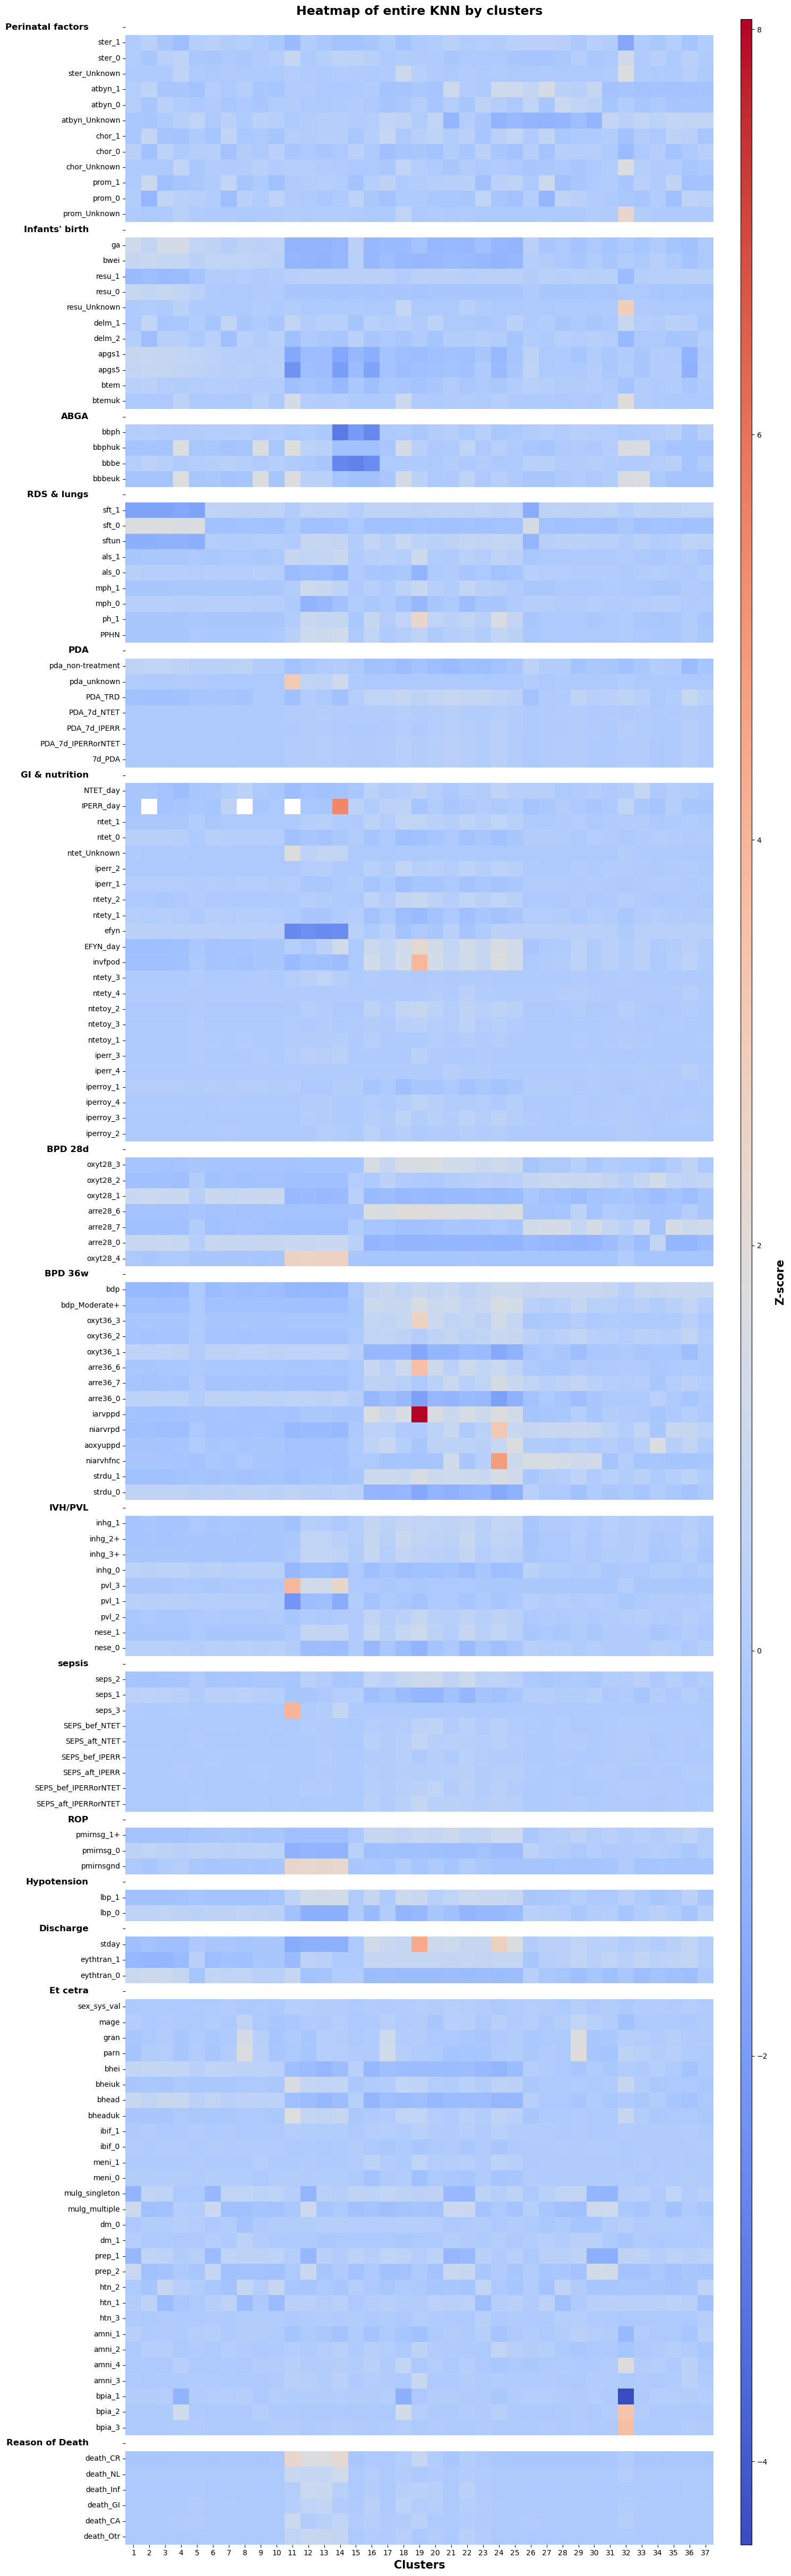

In [52]:
selected_cols = df_dic['col_name'].tolist()
df_selected = df_ana[selected_cols + ['Cluster_Labels']]
df_heatmap = df_selected.groupby('Cluster_Labels').mean().T.loc[selected_cols]

# 카테고리 이름(cat_name)이 바뀔 때마다 빈 줄 추가
expanded_idx, expanded_data = [], []  # 반드시 둘 다 초기화
previous_cat = None
cat_name_positions, cat_labels = [], []
current_pos = 0

for cat, col in zip(df_dic['cat_name'], df_dic['col_name']):
    if cat != previous_cat:
        expanded_idx.append('')  # 빈줄 (dash 제거)
        expanded_data.append([np.nan] * df_heatmap.shape[1])  # 빈줄 NaN 처리
        cat_name_positions.append(current_pos + 0.5)
        cat_labels.append(cat)
        current_pos += 1
        previous_cat = cat

    expanded_idx.append(col)
    expanded_data.append(df_heatmap.loc[col].values)
    current_pos += 1

# 확장된 히트맵 데이터 생성
df_heatmap_expanded = pd.DataFrame(expanded_data, index=expanded_idx, columns=df_heatmap.columns)

# mask 수정: 빈줄 완전히 마스킹 처리
mask = df_heatmap_expanded.isna().copy()
mask[df_heatmap_expanded.index == ''] = True

# 그림 전체 설정
fig = plt.figure(figsize=(15, len(df_heatmap_expanded) * 0.3))
gs = GridSpec(1, 7, width_ratios=[1, 1, 1, 1, 1, 0.1, 0.1], figure=fig)

# 히트맵 축 설정
ax = fig.add_subplot(gs[0, :5])

# Heatmap settings
sns.heatmap(
    df_heatmap_expanded,
    cmap='coolwarm',
    annot=False,
    cbar=False,
    linewidths=0,
    mask=df_heatmap_expanded.isna(),
    ax=ax
)

# 빈 문자열 ('')이 '-'로 보이는 것을 방지하기 위해 yticklabels을 다시 지정
yticks_labels = [' ' if idx == '' else idx for idx in df_heatmap_expanded.index.tolist()]
ax.set_yticks(np.arange(len(yticks_labels)) + 0.5)
ax.set_yticklabels(yticks_labels, fontsize=10, fontweight='normal')

# 히트맵 축 라벨 및 타이틀 설정
ax.set_xlabel('Clusters', fontsize=15, fontweight='bold')
ax.set_title('Heatmap of entire KNN by clusters', fontsize=17, fontweight='bold')

# cat_name 전용 축을 추가하여 왼쪽 정렬로 삽입
ax2 = ax.twinx()
ax2.set_ylim(ax.get_ylim())
ax2.set_yticks(cat_name_positions)
ax2.set_yticklabels(cat_labels, fontsize=12, fontweight='bold', va='center', ha='right')

# cat_name 축 눈금 및 테두리 제거
ax2.tick_params(axis='y', length=0)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['bottom'].set_visible(False)
ax2.spines['left'].set_visible(False)

# cat_name 위치를 충분히 왼쪽으로 이동
ax2.set_xlim(ax.get_xlim())
ax2.set_ylabel('')
ax2.yaxis.set_label_position("left")
ax2.yaxis.tick_left()

# cat_name 라벨의 좌우 위치 세부 조정
ax2.yaxis.set_tick_params(pad=50)

# 컬러바 축 추가
cbar_ax = fig.add_subplot(gs[0, 6])
hm = ax.collections[0]
cb = fig.colorbar(hm, cax=cbar_ax)
cb.set_label('Z-score', rotation=90, fontsize=15, labelpad=10, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(ipt_dir, "Heatmap plot.pdf"), format='pdf', bbox_inches='tight')
plt.show()

In [ ]:
# EFYN_day 결측으로 인한 인원확인

▶ Cluster‑wise overview
           n of EFYN_day(NaN)         n of Deceased  \
Cluster                                               
1           33 / 8009 (0.41%)     25 / 8009 (0.31%)   
2        2245 / 2392 (93.85%)  2285 / 2392 (95.53%)   
3          121 / 2908 (4.16%)    171 / 2908 (5.88%)   
4          128 / 7043 (1.82%)    110 / 7043 (1.56%)   

        n of EFYN_day(NaN) +Deceased  
Cluster                               
1                   8 / 8009 (0.10%)  
2               2200 / 2392 (91.97%)  
3                  86 / 2908 (2.96%)  
4                  62 / 7043 (0.88%)  


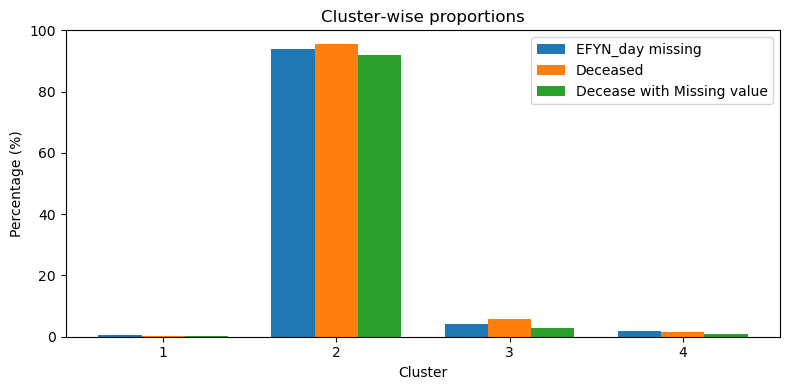

In [75]:
summary = []
for clus, g in df_ana.groupby('Cluster_Labels'):
    n_tot        = len(g)
    n_nan        = g['EFYN_day'].isna().sum()
    n_death      = (g['death_label'] == 1).sum()
    n_nan_death  = g['EFYN_day'].isna() & (g['death_label'] == 1)
    n_nan_death  = n_nan_death.sum()

    summary.append({
        "Cluster"        : clus,
        # ── 표(프린트용) 문자열 ────────────────────────────
        "n of EFYN_day(NaN)"   : f"{n_nan} / {n_tot} ({n_nan/n_tot:.2%})",
        "n of Deceased"     : f"{n_death} / {n_tot} ({n_death/n_tot:.2%})",
        "n of EFYN_day(NaN) +Deceased"  : f"{n_nan_death} / {n_tot} ({n_nan_death/n_tot:.2%})",
        # ── 그래프용 숫자(비율) ────────────────────────────
        "EFYN_NaN_pct"   : n_nan / n_tot * 100,
        "Deaths_pct"     : n_death / n_tot * 100,
        "NaN+Death_pct"  : n_nan_death / n_tot * 100
    })

summary_df = (pd.DataFrame(summary)
                .set_index("Cluster")
                .sort_index())

# 보기 좋은 표 출력
print("▶ Cluster‑wise overview")
print(summary_df[["n of EFYN_day(NaN)", "n of Deceased", "n of EFYN_day(NaN) +Deceased"]])

# -----------------------------------------------------------
# ❷ 시각화 : 비율 막대그래프
# -----------------------------------------------------------
plot_df = summary_df[["EFYN_NaN_pct", "Deaths_pct", "NaN+Death_pct"]]

x = np.arange(len(plot_df))            # 클러스터 위치
width = 0.25

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - width, plot_df['EFYN_NaN_pct'],  width, label='EFYN_day missing')
ax.bar(x        , plot_df['Deaths_pct'],     width, label='Deceased')
ax.bar(x + width, plot_df['NaN+Death_pct'],  width, label='Decease with Missing value')

ax.set_xticks(x)
ax.set_xticklabels(plot_df.index.astype(str))
ax.set_ylabel('Percentage (%)')
ax.set_xlabel('Cluster')
ax.set_ylim(0, 100)
ax.set_title('Cluster‑wise proportions')
ax.legend()
plt.tight_layout()
plt.show()

In [81]:
print(df_ana['birthdt'].info())
print(df_ana['death_dt'].info())

<class 'pandas.core.series.Series'>
Int64Index: 20352 entries, 0 to 20412
Series name: birthdt
Non-Null Count  Dtype         
--------------  -----         
0 non-null      datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 318.0 KB
None
<class 'pandas.core.series.Series'>
Int64Index: 20352 entries, 0 to 20412
Series name: death_dt
Non-Null Count  Dtype         
--------------  -----         
0 non-null      datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 318.0 KB
None


In [87]:
df_ana['birthdt']  = pd.to_datetime(df_ana['birthdt'],  format='%Y-%m-%d', errors='coerce')
df_ana['death_dt'] = pd.to_datetime(df_ana['death_dt'], format='%Y-%m-%d', errors='coerce')
df_ana['survival_days'] = (df_ana['death_dt'] - df_ana['birthdt']).dt.days

valid = df_ana['survival_days'].notna()             # 사망 기록이 있는 환자만 선택
summary = (
    df_ana.loc[valid]
          .groupby('Cluster_Labels')['survival_days']
          .agg(['count', 'mean', 'median', 'std'])
          .sort_index()
)
print(summary)

means = summary['mean']
ses   = summary['std'] / summary['count']**0.5     # 표준오차
ci95  = 1.96 * ses                                 # 95 % 신뢰구간

plt.bar(means.index.astype(str), means, yerr=ci95, edgecolor='black', capsize=3)
plt.ylabel('Mean days (From Birth to Death)')
plt.xlabel('Cluster')
plt.title('Average survival (Days) by cluster')
plt.tight_layout()
plt.show()

KeyError: 'birthdt'

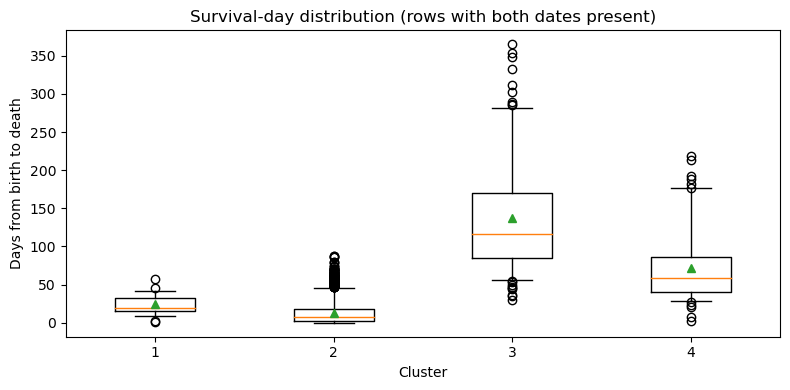

                count        mean  median        std
Cluster_Labels                                      
1                  25   24.360000    20.0  14.067930
2                2285   12.757549     7.0  15.186316
3                 171  137.461988   116.0  72.713722
4                 110   71.763636    58.5  44.859808


In [91]:
# 1) 두 날짜 모두 있는 행만 선택
mask   = df_ana['birthdt'].notna() & df_ana['death_dt'].notna()
df_sub = df_ana.loc[mask].copy()

# 2) 생존 일수 다시 계산
df_sub['survival_days'] = (df_sub['death_dt'] - df_sub['birthdt']).dt.days

# 3) 클러스터별 데이터 배열
clusters = sorted(df_sub['Cluster_Labels'].unique())
box_data = [df_sub.loc[df_sub['Cluster_Labels'] == c, 'survival_days'].values
            for c in clusters]

# 4) Box‑and‑whisker plot
plt.figure(figsize=(8, 4))
plt.boxplot(
    box_data,
    labels=[str(c) for c in clusters],
    showmeans=True,        # ◆ : 표본평균 표시
    meanline=False,
    whis=(5, 95)           # 수염을 5–95 퍼센타일로 제한(극단값 완화)
)

plt.ylabel('Days (From birth to death)')
plt.xlabel('Cluster')
plt.title('Survival‑day distribution')
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────
# 보조적으로, 클러스터별 표본 수·평균·중앙값 확인
summary = (
    df_sub.groupby('Cluster_Labels')['survival_days']
          .agg(['count', 'mean', 'median', 'std'])
          .sort_index()
)
print(summary)

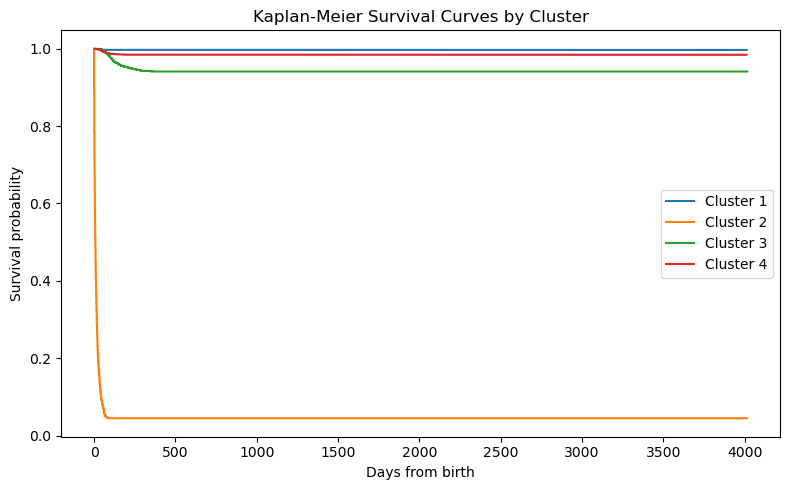

In [98]:
try:
    from lifelines import KaplanMeierFitter
    lifelines_available = True
except ImportError:
    lifelines_available = False

# --- Load the data (expects df_ana already available in notebook scope) ---
# NOTE: Adapt the following line if df_ana is not yet in memory.
try:
    df = df_ana.copy()
except NameError:
    raise NameError("⚠️  df_ana is not defined in the current session.")

# Ensure datetime conversion
df['birthdt'] = pd.to_datetime(df['birthdt'], format='%Y-%m-%d', errors='coerce')
df['death_dt'] = pd.to_datetime(df['death_dt'], format='%Y-%m-%d', errors='coerce')

# Define an end-of-follow‑up date (use dataset extraction date or today)
censor_date = pd.Timestamp('2023-12-31')  # adjust if a better cut‑off exists

# Durations & event indicator
df['duration'] = np.where(
    df['death_dt'].notna(),
    (df['death_dt'] - df['birthdt']).dt.days,
    (censor_date - df['birthdt']).dt.days
)
df['event_observed'] = df['death_dt'].notna().astype(int)

# Filter rows where both dates are present or at least birthdt present
df = df[df['birthdt'].notna() & df['duration'].notna()]

# Prepare plot
plt.figure(figsize=(8, 5))

if lifelines_available:
    kmf = KaplanMeierFitter()
    for cluster in sorted(df['Cluster_Labels'].unique()):
        mask = df['Cluster_Labels'] == cluster
        kmf.fit(
            durations=df.loc[mask, 'duration'],
            event_observed=df.loc[mask, 'event_observed'],
            label=f'Cluster {cluster}'
        )
        kmf.plot(ci_show=False)  # hides confidence band for clarity
else:
    # Manual survival curve computation (basic)
    for cluster in sorted(df['Cluster_Labels'].unique()):
        sub = df.loc[df['Cluster_Labels'] == cluster, ['duration', 'event_observed']]
        # Kaplan‑Meier estimate
        sub = sub.sort_values('duration')
        n = len(sub)
        surv = 1.0
        times, survival = [], []
        for t, e in zip(sub['duration'], sub['event_observed']):
            times.append(t)
            if e == 1:
                surv *= (n - 1) / n
            survival.append(surv)
            n -= 1
        plt.step(times, survival, where='post', label=f'Cluster {cluster}')

plt.xlabel('Days from birth')
plt.ylabel('Survival probability')
plt.title('Kaplan‑Meier Survival Curves by Cluster')
plt.legend()
plt.tight_layout()
plt.show()

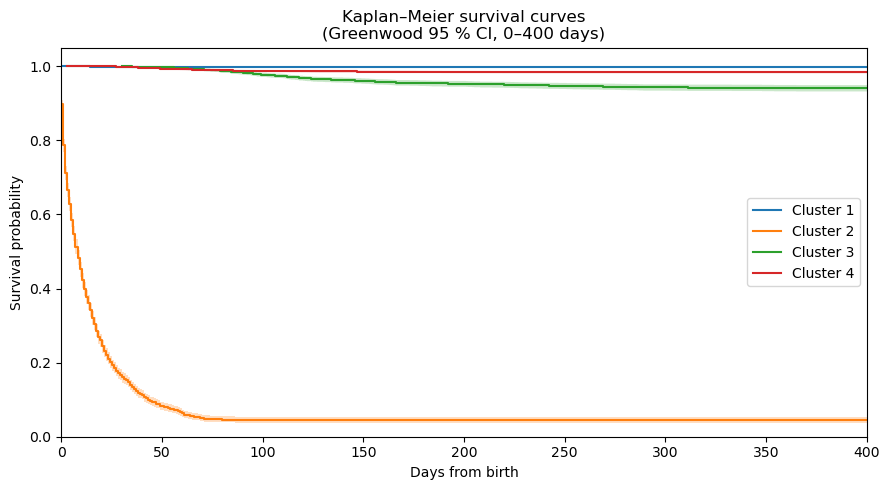

In [105]:
def km_greenwood(durations, events, alpha=0.05):
    df_t = (pd.DataFrame({'t': durations, 'e': events})
              .groupby('t')
              .agg(d=('e', 'sum'), n=('e', 'size'))
              .sort_index())
    df_t['n_at_risk'] = df_t['n'][::-1].cumsum()[::-1]

    S, var = [], []
    surv, g_sum = 1.0, 0.0
    for _, r in df_t.iterrows():
        surv *= 1 - r.d / r.n_at_risk
        g_sum += r.d / (r.n_at_risk * (r.n_at_risk - r.d))
        S.append(surv)
        var.append(surv**2 * g_sum)

    t   = df_t.index.to_numpy()
    S   = np.array(S)
    se  = np.sqrt(var)

    z = 1.96
    lnlnS = np.log(-np.log(S))
    delta = z * se / (S * np.log(S))
    lo = np.exp(-np.exp(lnlnS + delta))
    hi = np.exp(-np.exp(lnlnS - delta))
    return t, S, lo, hi

# ── PLOTs ────────────────────────────────────────────────
plt.figure(figsize=(9, 5))

for c in sorted(df['Cluster_Labels'].unique()):
    m = df['Cluster_Labels'] == c
    t, S, lo, hi = km_greenwood(df.loc[m, 'duration'].values,
                                df.loc[m, 'event_observed'].values)
    plt.step(t, S, where='post', label=f'Cluster {c}')
    plt.fill_between(t, lo, hi, step='post', alpha=0.25)

plt.xlabel('Days from birth')
plt.ylabel('Survival probability')
plt.title('Kaplan–Meier survival curves\n(Greenwood 95 % CI, 0–400 days)')
plt.ylim(0, 1.05)
plt.xlim(0, 400)                     # ← 여기서 0–400 일로 한정
plt.xticks(np.arange(0, 401, 50))    # (선택) 50 일 간격 눈금
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_19388\2680860368.py:23: RuntimeWarning: divide by zero encountered in scalar divide
  g_sum += r.d / (r.n_at_risk * (r.n_at_risk - r.d))
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_19388\2680860368.py:25: RuntimeWarning: invalid value encountered in scalar multiply
  var.append(surv**2 * g_sum)
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_19388\2680860368.py:31: RuntimeWarning: divide by zero encountered in log
  ll    = np.exp(-np.exp(np.log(-np.log(S)) + z * se / (S*np.log(S))))
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_19388\2680860368.py:31: RuntimeWarning: invalid value encountered in multiply
  ll    = np.exp(-np.exp(np.log(-np.log(S)) + z * se / (S*np.log(S))))
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_19388\2680860368.py:32: RuntimeWarning: divide by zero encountered in log
  ul    = np.exp(-np.exp(np.log(-np.log(S)) - z * se / (S*np.log(S))))
C:\Users\Public\Documents\EST

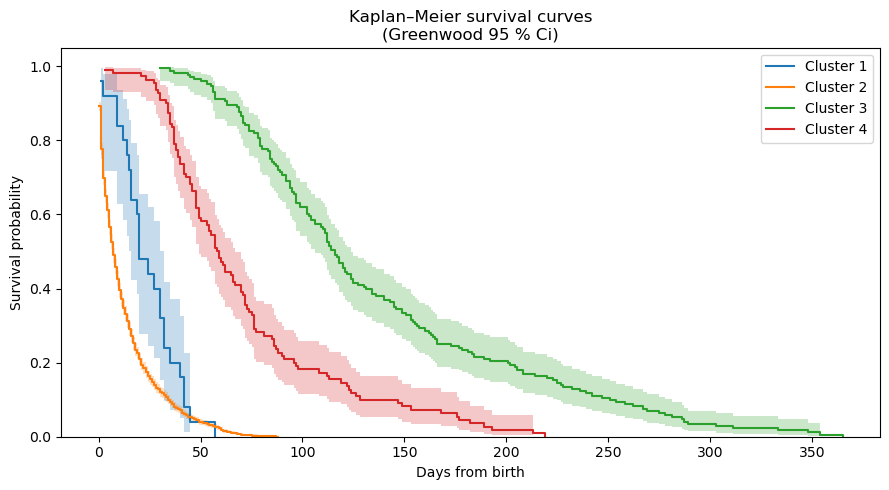

                count        mean  median        std
Cluster_Labels                                      
1                  25   24.360000    20.0  14.067930
2                2285   12.757549     7.0  15.186316
3                 171  137.461988   116.0  72.713722
4                 110   71.763636    58.5  44.859808


In [103]:
# 1) 두 날짜 모두 존재하는 행만 추출
mask   = df_ana['birthdt'].notna() & df_ana['death_dt'].notna()
df_sub = df_ana.loc[mask].copy()

df_sub['birthdt']  = pd.to_datetime(df_sub['birthdt'])
df_sub['death_dt'] = pd.to_datetime(df_sub['death_dt'])
df_sub['duration'] = (df_sub['death_dt'] - df_sub['birthdt']).dt.days
df_sub['event_observed'] = 1        # 두 날짜 모두 있으면 ‘사건(사망)=1’

# 2) Greenwood KM 함수
def km_greenwood(durations, events, alpha=0.05):
    tbl = (pd.DataFrame({'t': durations, 'e': events})
             .groupby('t')
             .agg(d=('e', 'sum'), n=('e', 'size'))
             .sort_index())
    tbl['n_at_risk'] = tbl['n'][::-1].cumsum()[::-1]

    S, var = [], []
    surv   = 1.0
    g_sum  = 0.0
    for _, r in tbl.iterrows():
        surv *= 1 - r.d / r.n_at_risk
        g_sum += r.d / (r.n_at_risk * (r.n_at_risk - r.d))
        S.append(surv)
        var.append(surv**2 * g_sum)

    t     = tbl.index.to_numpy()
    S     = np.array(S)
    se    = np.sqrt(var)
    z     = 1.96 if alpha == 0.05 else abs(np.quantile(np.random.normal(size=1_000_000), 1 - alpha/2))
    ll    = np.exp(-np.exp(np.log(-np.log(S)) + z * se / (S*np.log(S))))
    ul    = np.exp(-np.exp(np.log(-np.log(S)) - z * se / (S*np.log(S))))
    return t, S, ll, ul

# 3) 클러스터별 KM 곡선 + CI
plt.figure(figsize=(9, 5))
for c in sorted(df_sub['Cluster_Labels'].unique()):
    m = df_sub['Cluster_Labels'] == c
    t, S, lo, hi = km_greenwood(df_sub.loc[m, 'duration'].values,
                                df_sub.loc[m, 'event_observed'].values)
    plt.step(t, S, where='post', label=f'Cluster {c}')
    plt.fill_between(t, lo, hi, step='post', alpha=0.25)

plt.xlabel('Days from birth')
plt.ylabel('Survival probability')
plt.title('Kaplan–Meier survival curves\n(Greenwood 95 % Ci)')
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()

# 4) Table
km_summary = (
    df_sub.groupby('Cluster_Labels')['duration']
          .agg(count='size',
               mean='mean',
               median='median',
               std='std')
          .sort_index()
)
print(km_summary)

In [ ]:
## PCA :::::::

In [58]:
# ipt_dir = f'{crt_path}/Results/M14_dM06/2_SurvOnly/1_ALL/C4'
ipt_dir = f'{crt_path}/Results/M15_dataset08/1_Whole/1_ALL/C4'

df_ana = pd.read_csv(os.path.join(ipt_dir, "df_scd_clustered.csv"))
# df_ana = pd.read_csv(os.path.join(ipt_dir, "KNN_df_combined.csv"))
df_ana.set_index('idx_code', inplace=True)
# df_ana = df_ana.rename(columns={'Unnamed: 0': 'col_name'})
# 'death36' 컬럼 제외
if 'death36' in df_ana.columns:
    df_ana = df_ana.drop(columns=['death36'])
if 'death_label' in df_ana.columns:
    df_ana = df_ana.drop(columns=['death_label'])
datetime_cols = [
    'ntetdt', 'ntetdty', 'date362', 'date36', 'menidt', 'pdaddth', 'pdaddt',
    'birthdt', 'admd', 'birtm', 'bird', 'efydt', 'death_dt', 'iperrdt'
]
df_ana = df_ana.drop(columns=[c for c in datetime_cols if c in df_ana.columns])

# Cluster Labels 분리
cluster_labels = df_ana['Cluster_Labels']
df_scd = df_ana.drop(columns=['Cluster_Labels'])    # , 'idx_code' --> Index

df_scd

,sex_sys_val,apgs1,apgs5,bwei,mage,gran,parn,bhei,bheiuk,bhead,...,oxyt36_3,arre36_0,arre36_6,arre36_7,pvl_1,pvl_3,pvl_2,seps_1,seps_2,seps_3
idx_code,,,,,,,,,,,,,,,,,,,,,
0,1,-0.361034,-1.032974,0.867691,-1.020264,-0.760507,-0.636012,0.685902,0.0,0.827566,...,0,1,0,0,1,0,0,1,0,0
1,1,-0.361034,-1.032974,-1.001814,0.360486,-0.760507,-0.636012,-0.622812,0.0,-1.218738,...,0,1,0,0,1,0,0,0,1,0
2,1,0.117458,-0.497525,1.034612,-1.710639,-0.760507,-0.636012,0.685902,0.0,1.032196,...,0,1,0,0,1,0,0,1,0,0
3,1,0.595950,0.037925,0.834307,-1.710639,-0.760507,-0.636012,-0.149447,0.0,0.827566,...,0,1,0,0,0,1,0,0,1,0
4,1,-0.361034,-1.032974,0.500467,0.590611,1.748735,0.768667,1.521251,0.0,0.213674,...,0,1,0,0,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20408,1,0.117458,0.573375,0.867691,-2.401014,-0.760507,-0.636012,0.268227,0.0,0.622935,...,0,1,0,0,1,0,0,0,1,0
20409,1,-0.361034,0.037925,-0.768126,1.050861,0.912321,0.768667,-0.845572,0.0,-1.014108,...,1,0,0,1,1,0,0,0,1,0
20410,0,0.117458,0.037925,2.737197,-0.790139,0.075907,-0.636012,1.660476,0.0,1.236826,...,0,1,0,0,1,0,0,1,0,0


In [59]:
# PCA 수행 (설명 가능한 분산 비율 계산)
pca = PCA(n_components=df_scd.shape[1])  # 최대 10개의 주성분 계산 (or feature 개수 이하)
pca.fit(df_scd)

# 설명 가능한 분산 비율 확인
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

# 출력
explained_variance_result = pd.DataFrame({
    "Principal Component": [f"PC{i+1}" for i in range(len(explained_variance_ratio))],
    "Explained Variance Ratio": explained_variance_ratio,
    "Cumulative Explained Variance": cumulative_explained_variance
})

print(explained_variance_result)

# 결과 시각화
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained_variance_ratio)+1), cumulative_explained_variance, marker='o', linestyle='--', label='Cumulative Explained Variance')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance Ratio')
plt.axhline(y=0.8, color='r', linestyle='--', label="80% Threshold")
plt.axhline(y=0.9, color='g', linestyle='--', label="90% Threshold")
plt.legend()
plt.grid()
plt.show()

ValueError: Input X contains NaN.
PCA does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [60]:
# 설명 가능한 분산 비율 확인
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

# 1. 누적 설명 분산 90% 기준으로 최적 PC 개수 찾기
optimal_pc_90 = np.argmax(cumulative_explained_variance >= 0.90) + 1

# 2. 엘보우 방법을 활용하여 최적의 PC 개수 시각화
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained_variance_ratio)+1), explained_variance_ratio, marker='o', linestyle='-', label='Individual Explained Variance')
plt.xlabel('Number of Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.title('Elbow Method for PCA')
plt.axvline(x=optimal_pc_90, color='r', linestyle='--', label=f"Optimal PCs ({optimal_pc_90})")
plt.legend()
plt.grid()
plt.show()

# 3. 평균 고유값 기준으로 최적 PC 개수 찾기
mean_variance = np.mean(pca.explained_variance_)  # 평균 고유값
optimal_pc_mean = np.sum(pca.explained_variance_ > mean_variance)

# 최종 결과 출력
print(f"Optimal number of principal components for 90% variance: {optimal_pc_90}")
print(f"Optimal number of principal components (Mean Eigenvalue Method): {optimal_pc_mean}")

AttributeError: 'PCA' object has no attribute 'explained_variance_ratio_'

In [61]:
pca = PCA(n_components=30)  # PC1 - PC30
pca_result = pca.fit_transform(df_scd)

# PCA 실행 후 얻어진 설명 가능한 분산 비율 (백분율 변환)
explained_variance_ratio = pca.explained_variance_ratio_ * 100  # %로 변환

# X축을 1~30까지 확장하기 위해 최대 30개의 PC 사용
num_pcs = min(30, len(explained_variance_ratio))
x_values = range(1, num_pcs + 1)
y_values = explained_variance_ratio[:num_pcs]

# Scree Plot 생성 (시각적 개선)
plt.figure(figsize=(10, 6))
plt.plot(x_values, y_values
         , marker='v', linestyle='-', color='b', markersize=6
         , label='Explained Variance (%)'
        )

# X축 범위 및 눈금 조정
plt.xlim(1, 30)
xticks_labels = [1, 2, 3, 4, 5, 10, 15, 20, 25, 30]  # 원하는 눈금만 표기
plt.xticks(xticks_labels)  # X축 눈금 설정

# Y축 라벨 및 눈금 설정
plt.ylabel('Variance Explained (%)')  # 백분율로 변경
plt.yticks(np.arange(0, max(y_values) + 5, 1))  # Y축 눈금을 5% 간격으로 설정

# 제목 및 라벨 스타일 조정
plt.xlabel('Number of Principal Components', fontsize=12)
plt.title('Scree Plot for PCA', fontsize=14, fontweight='bold')

# 가독성을 위한 그리드 추가
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

# 범례 스타일 조정
plt.legend(fontsize=12, loc='upper right')

# Show plot
plt.show()

ValueError: Input X contains NaN.
PCA does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [62]:
# 설명 가능한 분산 비율 확인
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

# 1D, 2D, 3D 설명 가능한 분산 비율 계산
evr_1D = explained_variance_ratio[0]  # PC1
evr_2D = explained_variance_ratio[:2].sum()  # PC1 + PC2
evr_3D = explained_variance_ratio[:3].sum()  # PC1 + PC2 + PC3

print(f"Explained Variance Ratio of PC1 (1D): {evr_1D:.4f}")
print(f"Explained Variance Ratio of PC1 + PC2 (2D): {evr_2D:.4f}")
print(f"Explained Variance Ratio of PC1 + PC2 + PC3 (3D): {evr_3D:.4f}")

# 적절한 차원 선택
if evr_1D >= 0.80:
    print("1D PCA Plot")
elif evr_2D >= 0.80:
    print("2D PCA Plot")
elif evr_3D >= 0.80:
    print("3D PCA Plot")
else:
    print("Over 3D+")

# 차원별 설명 가능한 분산 비율 시각화
plt.figure(figsize=(8, 5))
plt.bar(["PC1", "PC1+PC2", "PC1+PC2+PC3"], [evr_1D, evr_2D, evr_3D], color=['blue', 'green', 'red'])
plt.axhline(y=0.8, color='y', linestyle='--', label="80% Threshold")
plt.axhline(y=0.9, color='r', linestyle='--', label="90% Threshold")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance Ratio for Different PCA Dimensions")
plt.legend()
plt.grid()
plt.show()

AttributeError: 'PCA' object has no attribute 'explained_variance_ratio_'

In [63]:
# Apply PCA
pca = PCA(n_components=3)  # PC1, PC2, PC3
pca_result = pca.fit_transform(df_scd)

# Results to DF
df_pca = pd.DataFrame(pca_result, columns=['PC1', 'PC2', 'PC3'])
df_pca['Cluster_Labels'] = cluster_labels

# 각 주성분이 설명하는 분산 비율 (Explained Variance Ratio)
explained_variance_ratio = pca.explained_variance_ratio_ * 100  # 백분율 변환

# feature 기여도 확인 (고유벡터 행렬)
pca_loadings = pd.DataFrame(pca.components_.T, index=df_scd.columns, columns=['PC1', 'PC2', 'PC3'])

# 기여도가 큰 상위 feature 선택
top_features_PC1 = pca_loadings['PC1'].abs().sort_values(ascending=False)
top_features_PC2 = pca_loadings['PC2'].abs().sort_values(ascending=False)
top_features_PC3 = pca_loadings['PC3'].abs().sort_values(ascending=False)
# top_features_PC1 = pca_loadings['PC1'].abs().sort_values(ascending=False).head(30)    # Top 30 F
# top_features_PC2 = pca_loadings['PC2'].abs().sort_values(ascending=False).head(30)
# top_features_PC3 = pca_loadings['PC3'].abs().sort_values(ascending=False).head(30)

# 각 PC가 설명하는 총 분산 출력
print(f"PC1 explains {explained_variance_ratio[0]:.2f}% of total variance")
print(f"PC2 explains {explained_variance_ratio[1]:.2f}% of total variance")
print(f"PC3 explains {explained_variance_ratio[2]:.2f}% of total variance")

# 기여도가 높은 feature 출력
top_features_PC1, top_features_PC2, top_features_PC3

ValueError: Input X contains NaN.
PCA does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [72]:
df_top_features = pd.DataFrame({
    "PC1_Top_Features": top_features_PC1.index,
    "PC Loading_PC1": top_features_PC1.values,
    "PC2_Top_Features": top_features_PC2.index,
    "PC Loading_PC2": top_features_PC2.values,
    "PC3_Top_Features": top_features_PC3.index,
    "PC Loading_PC3": top_features_PC3.values
})

df_top_features.to_excel(os.path.join(ipt_dir, "PC-Loadings_ALL.xlsx"), encoding='utf-8-sig')

C:\Users\AIWM_W01\.conda\envs\Dev_AIWM\lib\site-packages\pandas\util\_decorators.py:211: FutureWarning: the 'encoding' keyword is deprecated and will be removed in a future version. Please take steps to stop the use of 'encoding'
  return func(*args, **kwargs)


In [80]:
# ipt_dir = f'{crt_path}/Results/M06_Modified-dth/4C'
# ipt_dir = f'{crt_path}/Results/M06_Modified-dth/3C_Opt-Silhouette'
ipt_dir = f'{crt_path}/Results/M14_dM06/1_Whole/1_ALL/C4'
df_fn = pd.read_excel(os.path.join(ipt_dir, "C4_ana+description.xlsx"))


# # 'col_name'과 '항목명'을 매핑하기 위한 Dictionary 생성 --> Description, Column
# feature_name_map = {col: {'Description': df_fn['col_name']
#                           , 'Column': df_fn['항목명']
#                          }
#                    }

# # top_features_PC1, PC2, PC3 feature 이름 변경적용
# def format_features(df, pc_name):
#     formatted_df = pd.DataFrame({
#         'Description': df.index.map(lambda x: feature_name_map[x]['Description'] if x in feature_name_map else x),
#         'Column': df.index,
#         'PC Score': df.values
#     })
#     return formatted_df

# top_features_PC1M = format_features(top_features_PC1, 'PC1')
# top_features_PC2M = format_features(top_features_PC2, 'PC2')
# top_features_PC3M = format_features(top_features_PC3, 'PC3')

# # 결과 확인
# top_features_PC1M, top_features_PC2M, top_features_PC3M


# 'col_name'과 '항목명'을 매핑하기 위한 Dictionary 생성 --> 항목명(기존이름)
feature_name_map = {col: f"{desc}({col})" for col, desc in zip(df_fn['col_name'], df_fn['항목명'])}

# top_features_PC1, PC2, PC3 feature 이름 변경적용
top_features_PC1M = top_features_PC1
top_features_PC2M = top_features_PC2
top_features_PC3M = top_features_PC3

top_features_PC1M.rename(index=feature_name_map, inplace=True)
top_features_PC2M.rename(index=feature_name_map, inplace=True)
top_features_PC3M.rename(index=feature_name_map, inplace=True)

# 결과 확인
top_features_PC1M, top_features_PC2M, top_features_PC3M

(재원일수(stday)                                                           0.200969
 재태일수 (Genital Age)(ga)                                                0.192660
 생후 28일 시점 인공호흡기 (Neg)(arre28_0)                                       0.187992
 교정 연령 36주 시점 기관지 폐 이형성증 (2001 NICHD workshop) (Pos)(bdp)              0.186053
 교정 연령 36주 시점 기관지 폐 이형성증 (2001 NICHD workshop) (Pos)(bdp_Moderate+)    0.179917
                                                                         ...   
 뇌실 주위 백질연화증 (Pos)(pvl_3)                                              0.003385
 조직학적 융모양막염 (Unknown)(chor_Unknown)                                    0.003004
 산전 항생제 사용 여부 (Unknown)(atbyn_Unknown)                                 0.001638
 산모 나이(Maternal age)(mage)                                             0.000590
 고혈압(HTN) (Chronic)(htn_3)                                             0.000460
 Name: PC1, Length: 111, dtype: float64,
 출생 장소(Birth place) (원내)(bpia_1)        0.290851
 출생 장소(Birth place) (원외)(bpia_

In [81]:
df_top_features = pd.DataFrame({
    "PC1_Top_Features": top_features_PC1M.index,
    "PC Loading_PC1": top_features_PC1M.values,
    "PC2_Top_Features": top_features_PC2M.index,
    "PC Loading_PC2": top_features_PC2M.values,
    "PC3_Top_Features": top_features_PC3M.index,
    "PC Loading_PC3": top_features_PC3M.values
})

df_top_features.to_excel(os.path.join(ipt_dir, "PC-Loadings_ALL.xlsx"), encoding='utf-8-sig')

C:\Users\AIWM_W01\.conda\envs\Dev_AIWM\lib\site-packages\pandas\util\_decorators.py:211: FutureWarning: the 'encoding' keyword is deprecated and will be removed in a future version. Please take steps to stop the use of 'encoding'
  return func(*args, **kwargs)


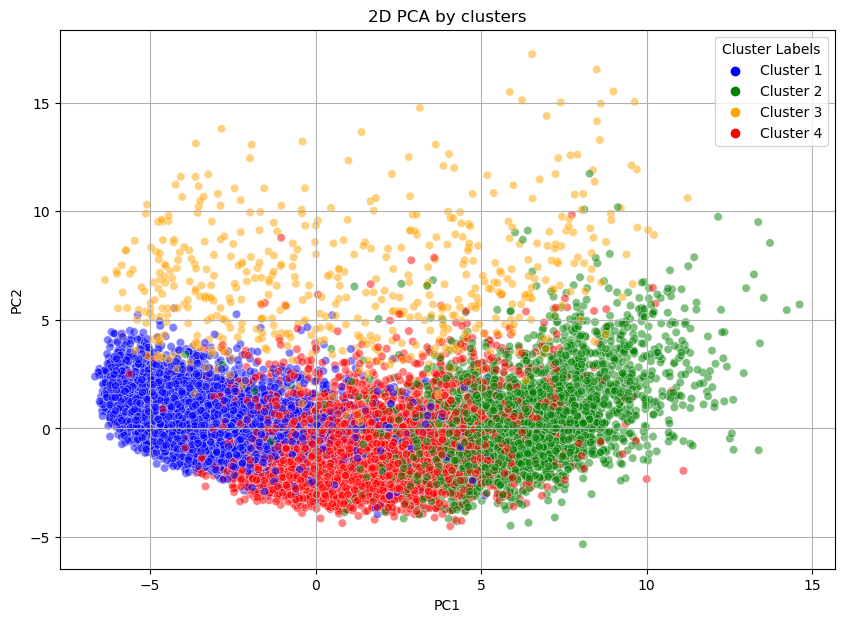

In [73]:
# PCA (2D)
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_scd)

# PCA 결과를 DataFrame으로 변환
df_pca = pd.DataFrame(data=pca_result, columns=['PC1', 'PC2'])
df_pca['Cluster_Labels'] = cluster_labels.values


# 클러스터별 색상 정의/적용
cluster_palette = {1: "blue"
                   , 2: "green"
                   , 3: "orange"
                   , 4: "red"
#                    , 5: "purple"
#                    , 6: "grey"
                  }
colors = df_pca["Cluster_Labels"].map(cluster_palette)

# PC1/PC2 (2D Scatter plot)
plt.figure(figsize=(10, 7))
sns.scatterplot(x=df_pca["PC1"], y=df_pca["PC2"],
                hue=df_pca["Cluster_Labels"],
                palette=cluster_palette,
                alpha=0.5)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("2D PCA by clusters")

# 범례 수정: Cluster {label} 형태로 설정
handles, labels = plt.gca().get_legend_handles_labels()
new_labels = [f"Cluster {lbl}" for lbl in labels]
plt.legend(handles=handles, labels=new_labels, title="Cluster Labels")

plt.grid(True)
plt.show()

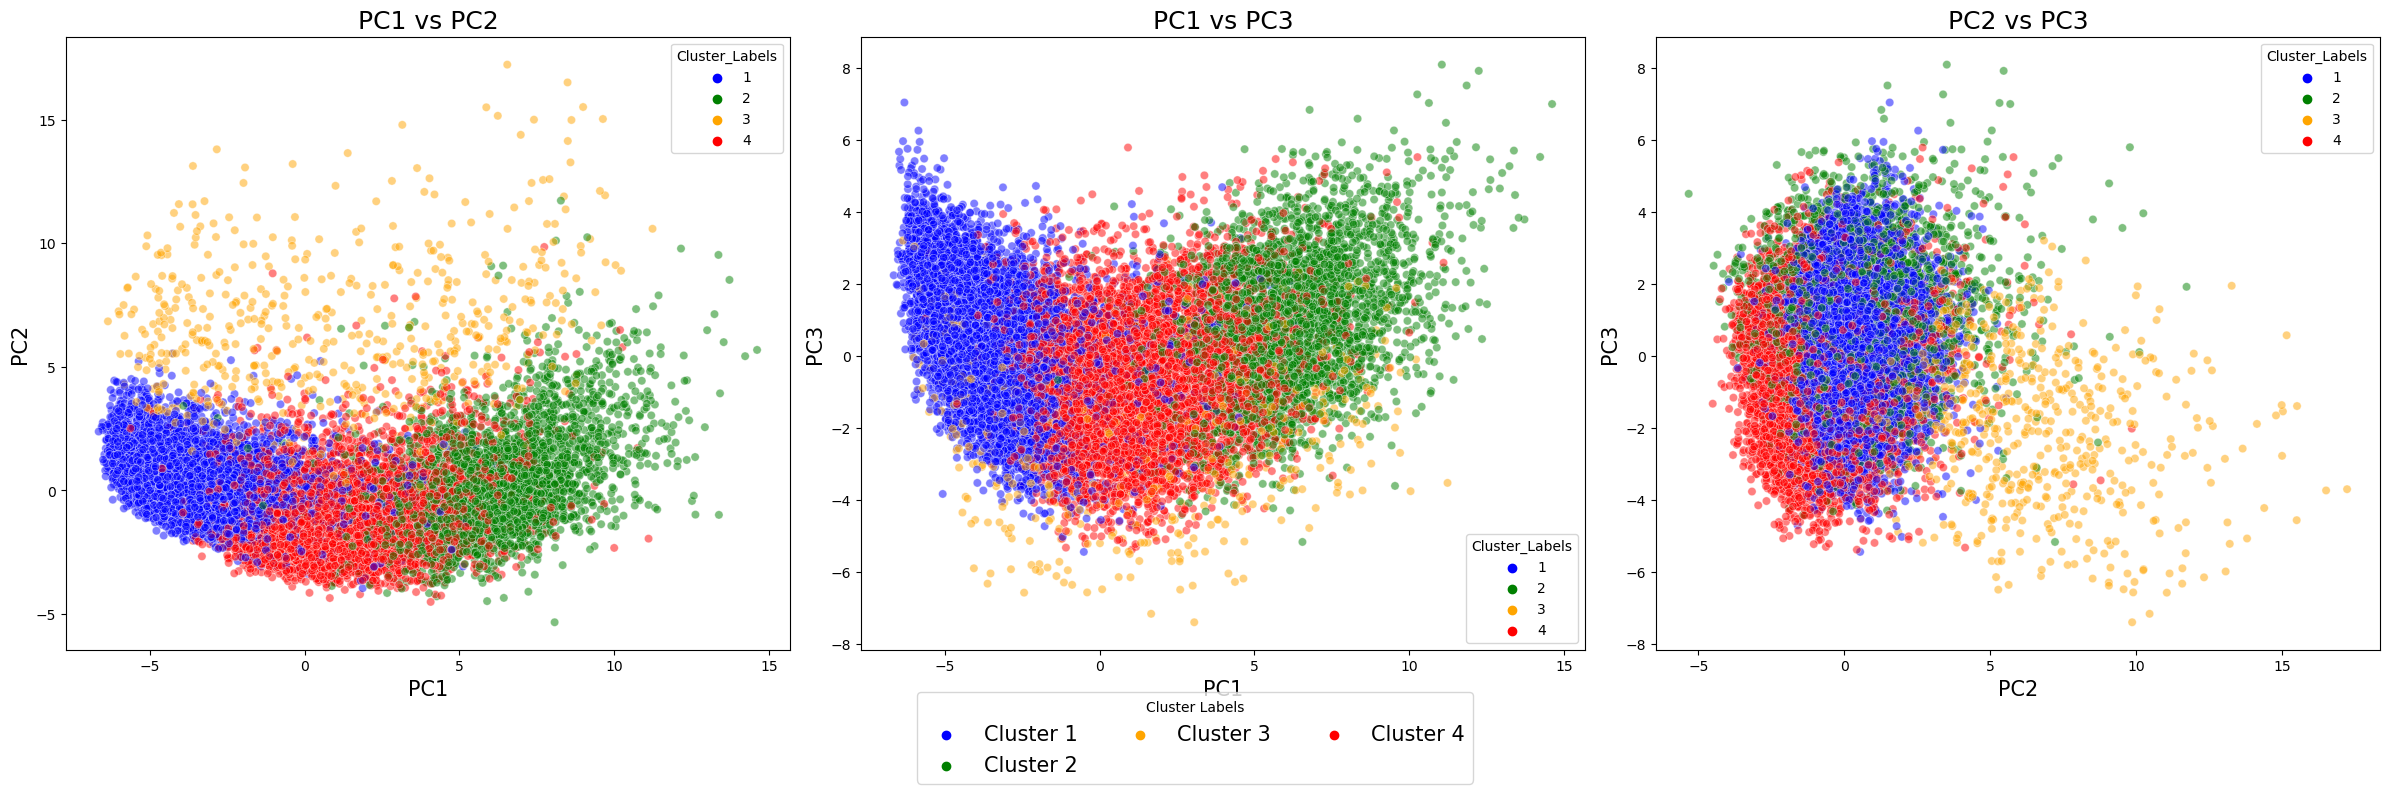

In [74]:
pca = PCA(n_components=3)
pca_result = pca.fit_transform(df_scd)

# PCA 결과를 DataFrame으로 변환
df_pca = pd.DataFrame(data=pca_result, columns=['PC1', 'PC2', 'PC3'])
df_pca['Cluster_Labels'] = cluster_labels.values

cluster_palette = {1: "blue"
                   , 2: "green"
                   , 3: "orange"
                   , 4: "red"
#                    , 5: "purple"
#                    , 6: "grey"
                  }
colors = df_pca["Cluster_Labels"].map(cluster_palette)

fontsize = 15
titlesize=18

# 2D PCA Scatter Plot 생성
fig, axes = plt.subplots(1, 3, figsize=(24, 8))  # 3개의 서브플롯 생성

# PC1 - PC2
sns.scatterplot(x=df_pca["PC1"], y=df_pca["PC2"],
                hue=df_pca["Cluster_Labels"],
                palette=cluster_palette,
                alpha=0.5, ax=axes[0])
axes[0].set_xlabel("PC1", fontsize= fontsize)
axes[0].set_ylabel("PC2", fontsize= fontsize)
axes[0].set_title("PC1 vs PC2" , fontsize= titlesize)

# PC1 - PC3
sns.scatterplot(x=df_pca["PC1"], y=df_pca["PC3"],
                hue=df_pca["Cluster_Labels"],
                palette=cluster_palette,
                alpha=0.5, ax=axes[1])
axes[1].set_xlabel("PC1", fontsize= fontsize)
axes[1].set_ylabel("PC3", fontsize= fontsize)
axes[1].set_title("PC1 vs PC3", fontsize= titlesize)

# PC2 - PC3
sns.scatterplot(x=df_pca["PC2"], y=df_pca["PC3"],
                hue=df_pca["Cluster_Labels"],
                palette=cluster_palette,
                alpha=0.5, ax=axes[2])
axes[2].set_xlabel("PC2", fontsize= fontsize)
axes[2].set_ylabel("PC3", fontsize= fontsize)
axes[2].set_title("PC2 vs PC3", fontsize= titlesize)

# 범례 수정: Cluster {label} 형태로 설정
handles, labels = axes[0].get_legend_handles_labels()
new_labels = [f"Cluster {lbl}" for lbl in labels]
fig.legend(handles=handles, labels=new_labels, title="Cluster Labels", loc='lower center', ncol=3, fontsize=fontsize)

# 레이아웃 조정
plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.show()

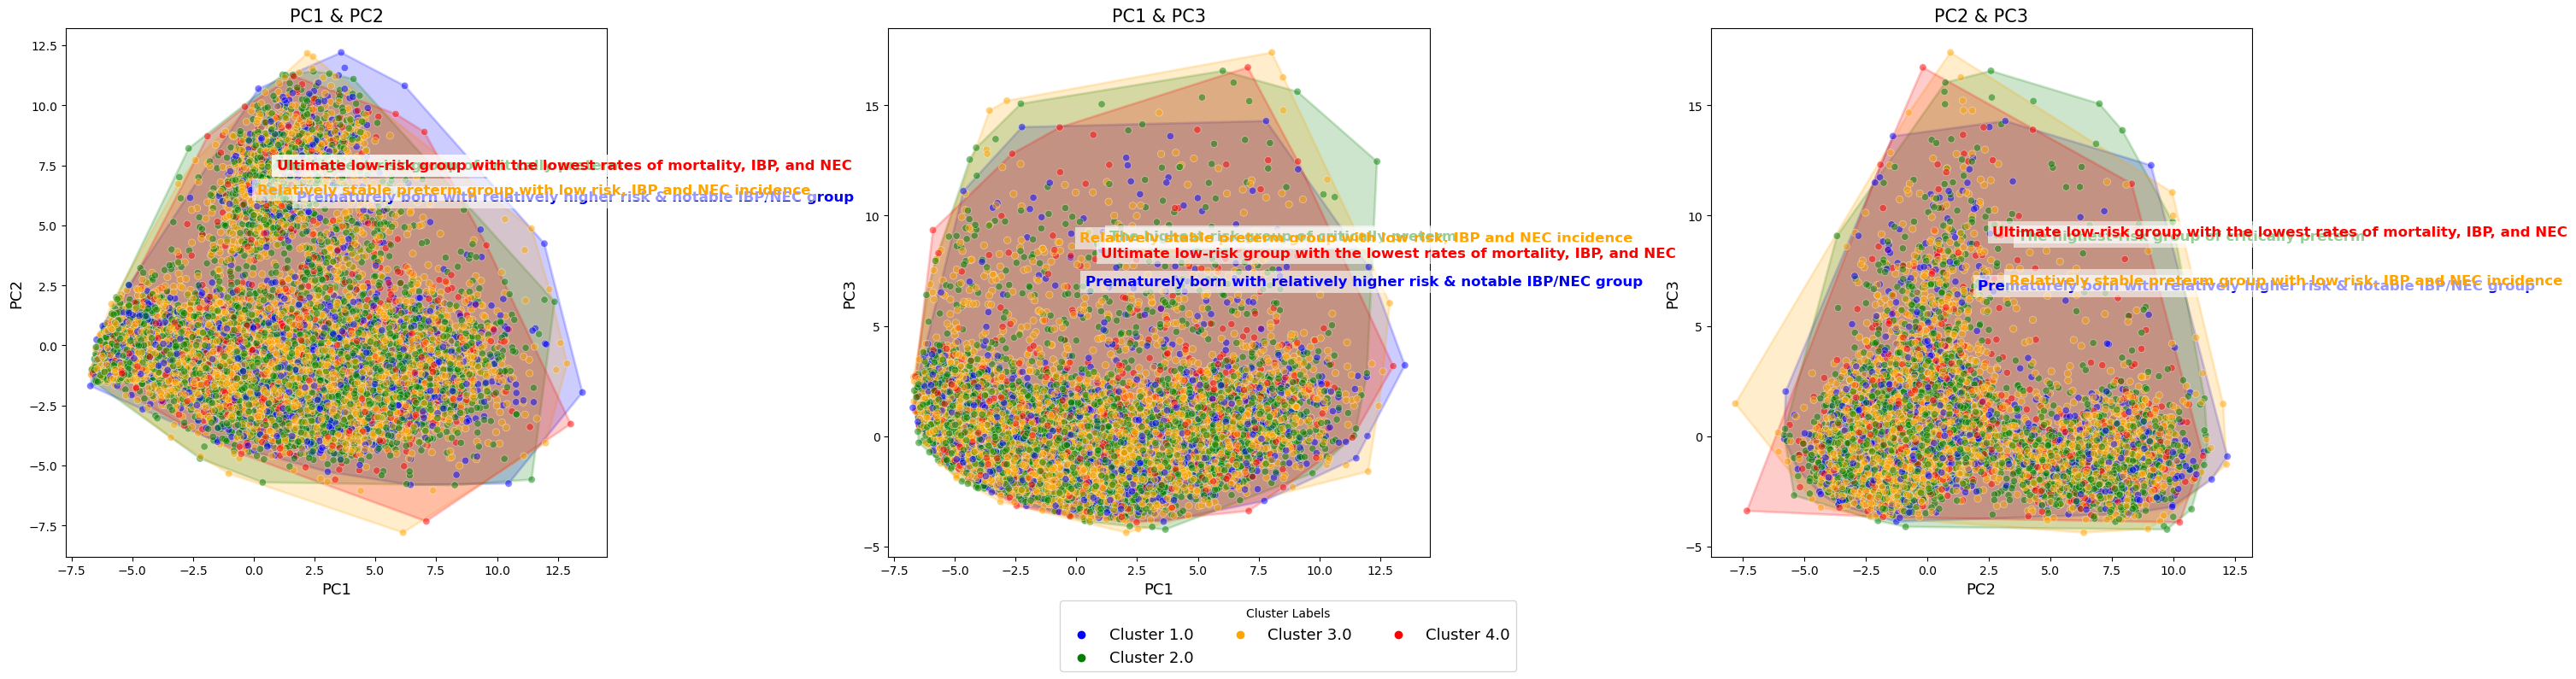

In [98]:
cluster_palette = {1: "blue"
                   , 2: "green"
                   , 3: "orange"
                   , 4: "red"
#                    , 5: "purple"
#                    , 6: "grey"
                  }
colors = df_pca["Cluster_Labels"].map(cluster_palette)

# 클러스터별 라벨 (각 클러스터의 주제)
cluster_labels_text = {
    1: "Prematurely born with relatively higher risk & notable IBP/NEC group"
    , 2: "The highest‐risk group of critically preterm"
    , 3: "Relatively stable preterm group with low risk, IBP and NEC incidence"
    , 4: "Ultimate low‐risk group with the lowest rates of mortality, IBP, and NEC"
#     , 5: "Group with moderate risk but comparatively higher IBP/NEC occurrences"
#     , 5: "Large representative cohort of moderately preterm with overall low risk"
}

fontsize = 13
titlesize = 15

# 3개의 2D PCA Scatter Plot 생성 (PC1-PC2, PC1-PC3, PC2-PC3)
fig, axes = plt.subplots(1, 3, figsize=(30, 8))

# PCA 조합 정의
pca_combinations = [
    ("PC1", "PC2", "PC1 & PC2"),
    ("PC1", "PC3", "PC1 & PC3"),
    ("PC2", "PC3", "PC2 & PC3")
]

# 각 서브플롯에 대해 Convex Hull과 산점도를 그림
for i, (pc_x, pc_y, title) in enumerate(pca_combinations):
    ax = axes[i]

    # 클러스터별 Convex Hull을 생성하여 경계를 그림
    for cluster, color in cluster_palette.items():
        cluster_points = df_pca[df_pca["Cluster_Labels"] == cluster][[pc_x, pc_y]].values

        if len(cluster_points) >= 3:  # Convex Hull은 최소 3개의 점이 필요
            hull = ConvexHull(cluster_points)
            hull_points = cluster_points[hull.vertices]

            # 클러스터 영역을 반투명한 색으로 채우기
            ax.fill(hull_points[:, 0], hull_points[:, 1]
                    , color=color, alpha=0.2, edgecolor=color
                    , linewidth=2
                   )

            # 클러스터 중심 좌표 계산
            cluster_center = np.mean(hull_points, axis=0)

            # 클러스터 라벨을 바깥쪽에 배치
            label_offset = 5  # 바깥쪽으로 밀기 위한 오프셋 값
            ax.text(cluster_center[0], cluster_center[1] + label_offset
                    , cluster_labels_text[cluster]
                    , fontsize=12, fontweight='bold', ha='left', color=color
                    , bbox=dict(facecolor='white', alpha=0.6, edgecolor='none')
                   )

    # 클러스터 산점도 그리기
    sns.scatterplot(x=df_pca[pc_x], y=df_pca[pc_y],
                    hue=df_pca["Cluster_Labels"],
                    palette=cluster_palette,
                    alpha=0.5, ax=ax)

    # 축 설정
    ax.set_xlabel(pc_x, fontsize=fontsize)
    ax.set_ylabel(pc_y, fontsize=fontsize)
    ax.set_title(title, fontsize=titlesize)
    
    # 개별 범례 제거 (공통 범례 사용)
    ax.legend_.remove()

# 범례를 가장 아래쪽에 배치
handles, labels = axes[0].get_legend_handles_labels()
new_labels = [f"Cluster {lbl}" for lbl in labels]
fig.legend(handles=handles, labels=new_labels
           , title="Cluster Labels", loc='lower center', ncol=3, fontsize=fontsize)

# 레이아웃 조정
plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.show()

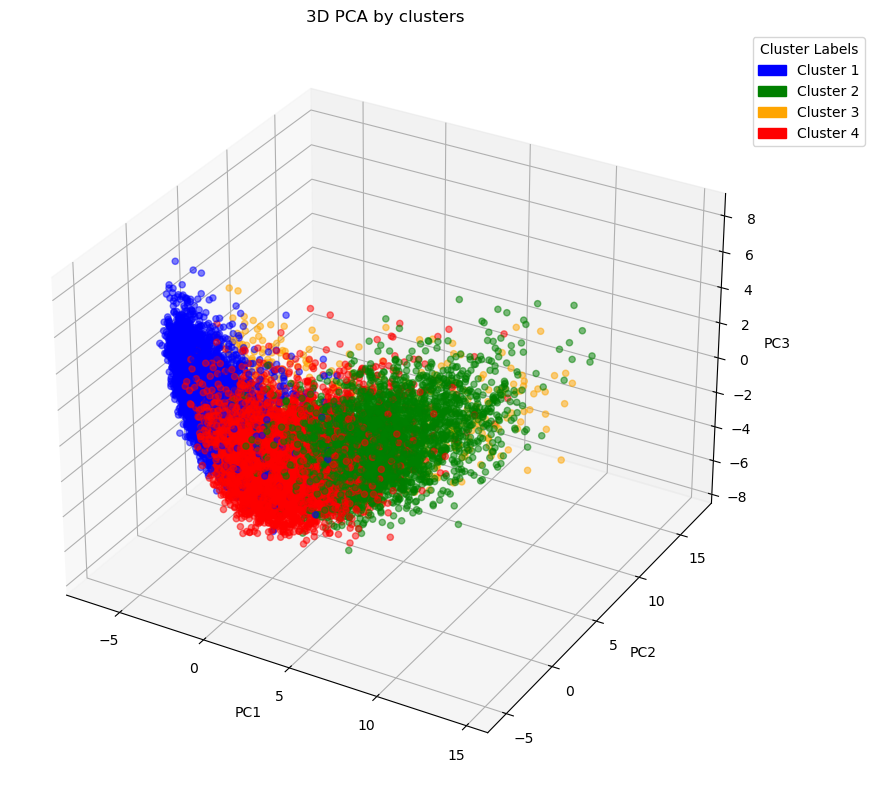

In [75]:
# 3D Scatter Plot (PC1 vs PC2 vs PC3)
pca = PCA(n_components=3)
pca_result = pca.fit_transform(df_scd)

# PCA 결과를 DataFrame으로 변환
df_pca = pd.DataFrame(data=pca_result, columns=['PC1', 'PC2', 'PC3'])
df_pca['Cluster_Labels'] = cluster_labels.values

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 각 클러스터별로 색상 적용
ax.scatter(df_pca["PC1"], df_pca["PC2"], df_pca["PC3"],
           c=colors,
           alpha=0.5)
# Label 잘림 방지 -> 'labelpad'
ax.set_xlabel("PC1", labelpad=5)
ax.set_ylabel("PC2", labelpad=5)
ax.set_zlabel("PC3", labelpad=5)
ax.set_title("3D PCA by clusters")

# 범례 추가
legend_patches = [mpatches.Patch(color=color, label=f"Cluster {label}"
                                ) for label, color in cluster_palette.items()
                 ]
plt.legend(handles=legend_patches
           , title="Cluster Labels", loc='upper right'
           , bbox_to_anchor=(1.15, 1)
          )

# 레이아웃 조정 (z축 라벨이 잘리지 않도록)
plt.tight_layout()

plt.show()

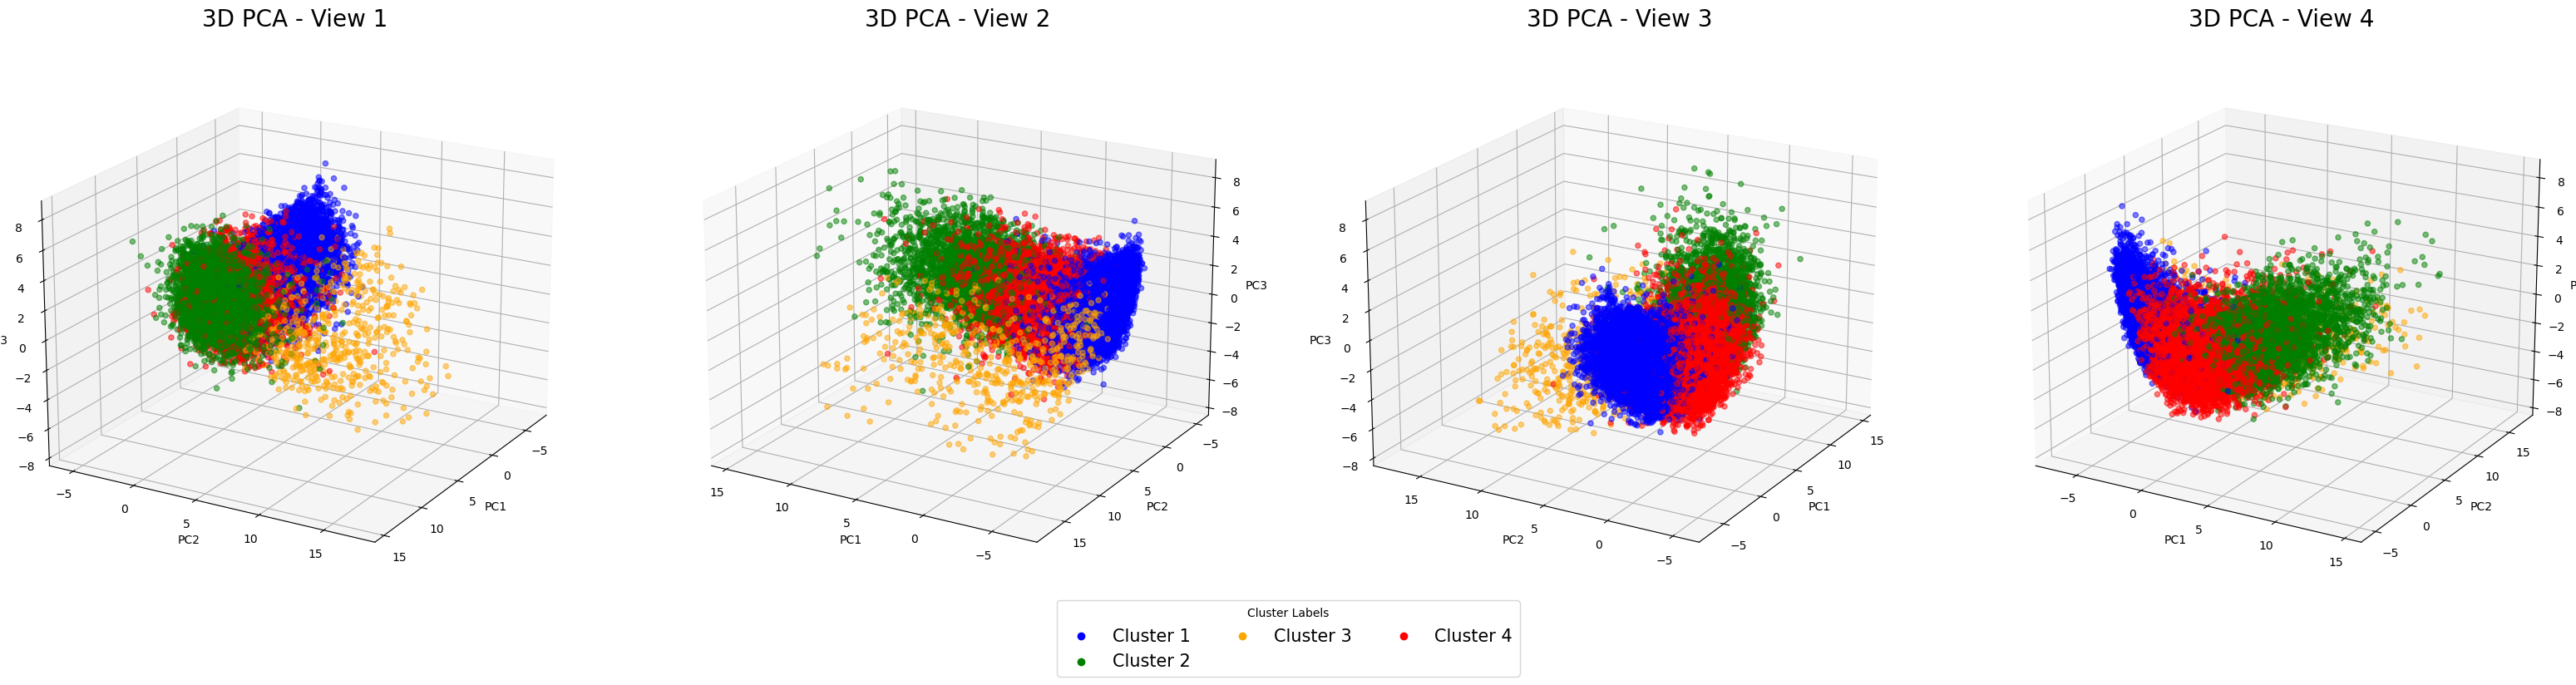

In [76]:
# 3D PCA Scatter Plot을 다양한 시점에서 시각화
fig = plt.figure(figsize=(32, 8))

# 시점 리스트 (각도 설정: (elevation, azimuth))
view_angles = [(20, 30), (20, 120), (20, 210), (20, 300)]

for i, (elev, azim) in enumerate(view_angles, 1):
    ax = fig.add_subplot(1, 4, i, projection='3d')
    
    # 각 클러스터별로 색상 적용
    ax.scatter(df_pca["PC1"], df_pca["PC2"], df_pca["PC3"],
               c=colors, alpha=0.5)
    
    # Label 잘림 방지 -> 'labelpad'
    ax.set_xlabel("PC1", labelpad=3)
    ax.set_ylabel("PC2", labelpad=3)
    ax.set_zlabel("PC3", labelpad=3)
    ax.set_title(f"3D PCA - View {i}", fontsize= 20)

    # 시점 변경
    ax.view_init(elev=elev, azim=azim)

handles, labels = axes[0].get_legend_handles_labels()
new_labels = [f"Cluster {lbl}" for lbl in labels]
fig.legend(handles=handles, labels=new_labels
           , title="Cluster Labels", loc='lower center'
#            , bbox_to_anchor=(0.5, 0)
           , ncol=3, fontsize=fontsize
          )

# 레이아웃 조정
# plt.subplots_adjust(left=0.06
#                     , right=0.94
#                     , bottom=0.15
#                     , top=0.9
#                     , wspace=0.5
#                    )
plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.show()

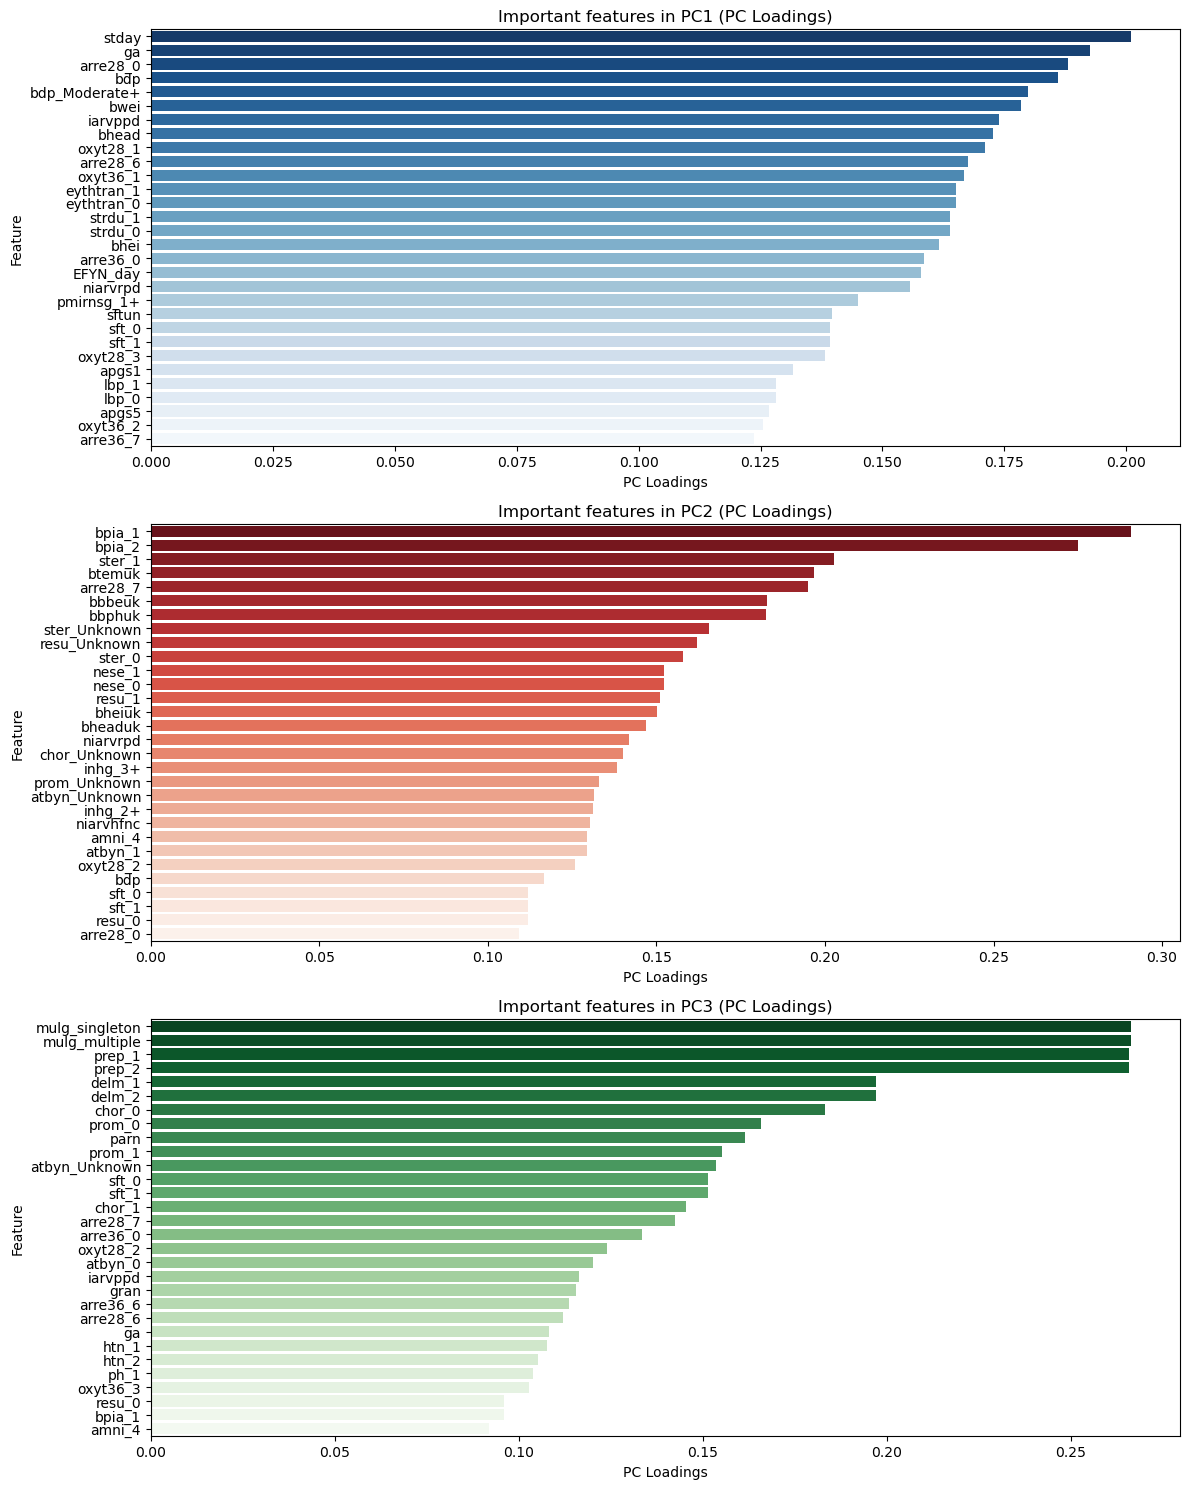

In [69]:
# Fixing the title issue in the Feature Importance plots
fig, axes = plt.subplots(3, 1, figsize=(12, 15))

# PC1 Feature Importance
sns.barplot(x=top_features_PC1.values, y=top_features_PC1.index
            , ax=axes[0]
            , palette="Blues_r"
           )
axes[0].set_title("Important features in PC1 (PC Loadings)")
axes[0].set_xlabel("PC Loadings")
axes[0].set_ylabel("Feature")

# PC2 Feature Importance
sns.barplot(x=top_features_PC2.values, y=top_features_PC2.index
            , ax=axes[1]
            , palette="Reds_r"
           )
axes[1].set_title("Important features in PC2 (PC Loadings)")
axes[1].set_xlabel("PC Loadings")
axes[1].set_ylabel("Feature")

# PC3 Feature Importance
sns.barplot(x=top_features_PC3.values, y=top_features_PC3.index
            , ax=axes[2]
            , palette="Greens_r"
           )
axes[2].set_title("Important features in PC3 (PC Loadings)")
axes[2].set_xlabel("PC Loadings")
axes[2].set_ylabel("Feature")

plt.tight_layout()
plt.show()

In [599]:
# P-value 리스트의 길이를 Feature 리스트와 정확히 맞춤

feature_pvalues = {
    "Feature": [
        "ga", "arre28_0", "bdp", "bwei", "bdp_Moderate+", "oxyt28_1", "iarvppd", "bhead", 
        "arre28_6", "oxyt36_1", "strdu_1", "bhei", "arre36_0", "pdatr_15", "resui_1", "sft_1", 
        "niarvrpd", "sftun", "pda_non-treatment", "rds_1", "oxyt28_3", "apgs1", "pdad_2", "lbp_1",
        "apgs5", "pdadty_2", "pdatr_13", "sftup_1", "strdut1", "oxyt36_2", "arre36_7", "resup_1",
        "paddr1", "acl_2", "seps_2", "strdud1", "seps_1", "bsf1", "inhg_2+"
    ],
    "P-value": [
        3.6664e-275, 0.0000e+00, 9.2028e-127, 0.0000e+00, 7.6381e-16, 2.1682e-129, 
        2.5945e-102, 0.0000e+00, 0.0099, 0.0000e+00, 3.5910e-27, 0.0000e+00, 5.5793e-06, 
        0.0000e+00, 7.1781e-81, 0.0000e+00, 5.5953e-118, 0.0000e+00, np.nan, 
        5.1738e-125, 0.0006, 1.9213e-28, 0.0000e+00, np.nan, 3.0405e-27, 0.0000e+00, 
        np.nan, np.nan, np.nan, 7.9070e-304, 0.0000e+00, 3.2999e-46, 8.5473e-136, 
        0.0000e+00, np.nan, 4.2803e-239, 9.7494e-251
    ]
}

# 데이터프레임 생성
df_feature_pvalues = pd.DataFrame(feature_pvalues)

# P-value를 기준으로 정렬 (낮을수록 중요)
df_feature_pvalues_sorted = df_feature_pvalues.sort_values(by="P-value")


ValueError: All arrays must be of the same length

In [8]:
data = {
    "Model": ["Hierarchical", "Hierarchical", "Hierarchical", "K-Means", "K-Means", "K-Means", 
              "GM", "GM", "GM", "HDBSCAN", "HDBSCAN", "HDBSCAN"],
    "Cluster": ["Cluster 1", "Cluster 2", "Cluster 3"] * 4,
    "Total": [11333, 3621, 2875, 5936, 11450, 443, 15884, 1925, 20, 234, 5439, 12156],
    "Positive Rate (iperr_Pos)": [1.66, 1.88, 5.88, 5.80, 0.71, 0.00, 1.79, 7.27, 0.00, 2.99, 3.57, 1.84],
    "Positive Rate (ntet_Pos)": [4.89, 5.80, 14.30, 14.08, 2.93, 0.68, 5.25, 17.45, 25.00, 8.12, 9.08, 5.45],
    "Positive Rate (death36_Pos)": [1.91, 1.33, 2.64, 4.33, 0.72, 0.23, 1.57, 4.73, 0.00, 8.12, 2.41, 1.56]
}

df = pd.DataFrame(data)
df

,Model,Cluster,Total,Positive Rate (iperr_Pos),Positive Rate (ntet_Pos),Positive Rate (death36_Pos)
0,Hierarchical,Cluster 1,11333,1.66,4.89,1.91
1,Hierarchical,Cluster 2,3621,1.88,5.80,1.33
2,Hierarchical,Cluster 3,2875,5.88,14.30,2.64
3,K-Means,Cluster 1,5936,5.80,14.08,4.33
4,K-Means,Cluster 2,11450,0.71,2.93,0.72
5,K-Means,Cluster 3,443,0.00,0.68,0.23
6,GM,Cluster 1,15884,1.79,5.25,1.57
7,GM,Cluster 2,1925,7.27,17.45,4.73
8,GM,Cluster 3,20,0.00,25.00,0.00
9,HDBSCAN,Cluster 1,234,2.99,8.12,8.12


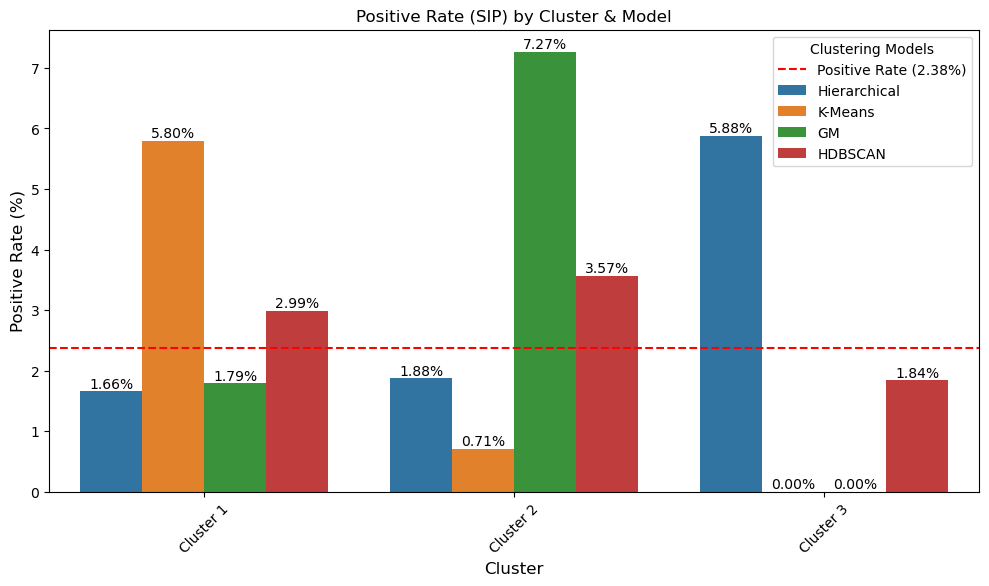

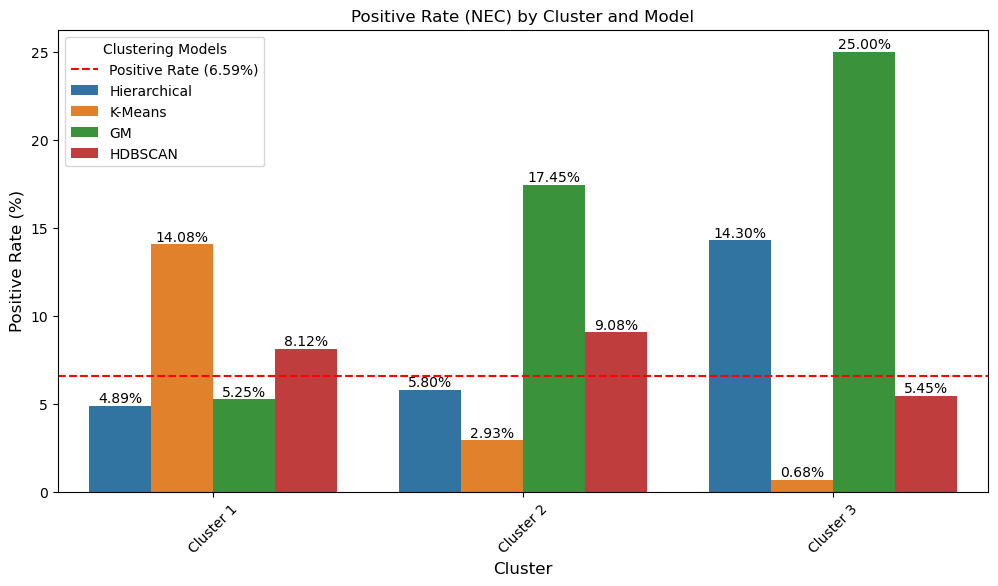

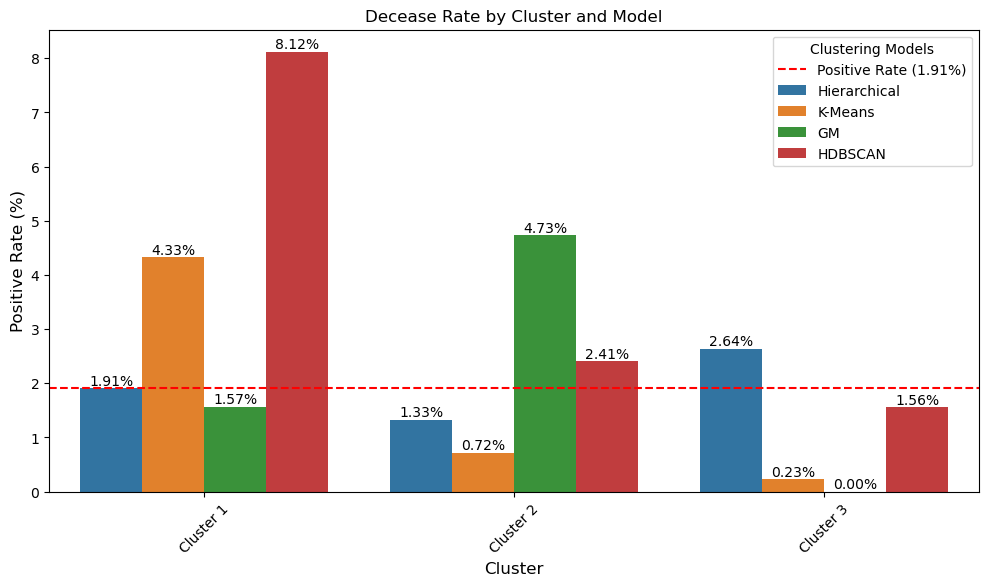

In [21]:
# Threshold 값 설정
thresholds = {
    "Positive Rate (iperr_Pos)": 2.38,
    "Positive Rate (ntet_Pos)": 6.59,
    "Positive Rate (death36_Pos)": 1.91
}

# 시각화 함수 정의
def plot_bar_with_threshold(y_col, title, threshold):
    plt.figure(figsize=(12, 6))
    ax = sns.barplot(x="Cluster", y=y_col, hue="Model", data=df)

    # Bar 위에 값(%) 표기
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.2f}%",  # 값 표기
                    (p.get_x() + p.get_width() / 2., p.get_height()),  # 위치 조정
                    ha="center", va="bottom", fontsize=10, color="black")

    # Threshold 점선 추가
    plt.axhline(threshold, color="red", linestyle="dashed", linewidth=1.5, label=f"Positive Rate ({threshold}%)")

    plt.title(title)
    plt.ylabel("Positive Rate (%)", fontsize=12)
    plt.xlabel("Cluster", fontsize=12)
    plt.xticks(rotation=45)
    plt.legend(title="Clustering Models")
    plt.show()


plot_bar_with_threshold("Positive Rate (iperr_Pos)"
                        , "Positive Rate (SIP) by Cluster & Model"
                        , thresholds["Positive Rate (iperr_Pos)"]
                       )
plot_bar_with_threshold("Positive Rate (ntet_Pos)"
                        , "Positive Rate (NEC) by Cluster and Model"
                        , thresholds["Positive Rate (ntet_Pos)"]
                       )
plot_bar_with_threshold("Positive Rate (death36_Pos)"
                        , "Decease Rate by Cluster and Model"
                        , thresholds["Positive Rate (death36_Pos)"]
                       )



# plt.figure(figsize=(12, 6))
# sns.barplot(x="Cluster", y="Positive Rate (iperr_Pos)", hue="Model", data=df)
# plt.title("Positive Rate (iperr_Pos) by Cluster and Model")
# plt.ylabel("Positive Rate (%)")
# plt.xlabel("Cluster")
# plt.xticks(rotation=45)
# plt.legend(title="Clustering Model")
# plt.show()

# # ntet_Pos Positive Rate 시각화
# plt.figure(figsize=(12, 6))
# sns.barplot(x="Cluster", y="Positive Rate (ntet_Pos)", hue="Model", data=df)
# plt.title("Positive Rate (ntet_Pos) by Cluster and Model")
# plt.ylabel("Positive Rate (%)")
# plt.xlabel("Cluster")
# plt.xticks(rotation=45)
# plt.legend(title="Clustering Model")
# plt.show()

# # death36_Pos Positive Rate 시각화
# plt.figure(figsize=(12, 6))
# sns.barplot(x="Cluster", y="Positive Rate (death36_Pos)", hue="Model", data=df)
# plt.title("Positive Rate (death36_Pos) by Cluster and Model")
# plt.ylabel("Positive Rate (%)")
# plt.xlabel("Cluster")
# plt.xticks(rotation=45)
# plt.legend(title="Clustering Model")
# plt.show()

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_3524\2814283329.py:3: FutureWarning: In a future version of pandas all arguments of DataFrame.pivot will be keyword-only.
  df_pivot = df.pivot("Cluster", "Model", y_col)  # Cluster x Model 구조로 변환


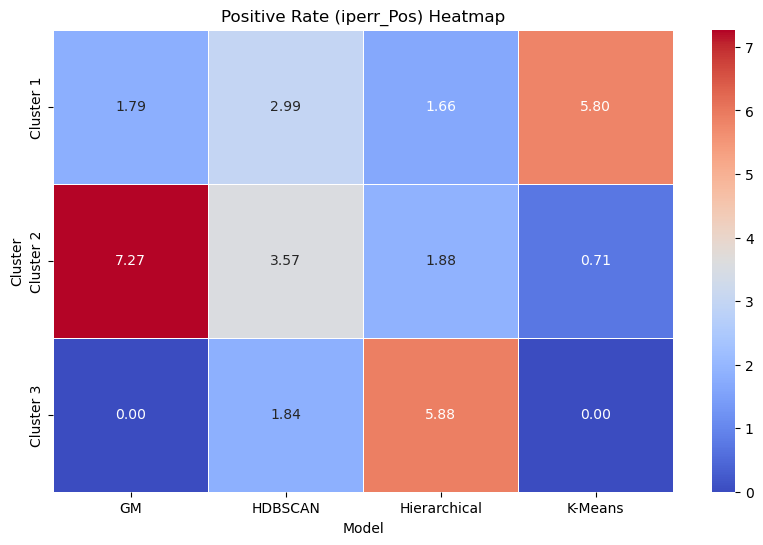

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_3524\2814283329.py:3: FutureWarning: In a future version of pandas all arguments of DataFrame.pivot will be keyword-only.
  df_pivot = df.pivot("Cluster", "Model", y_col)  # Cluster x Model 구조로 변환


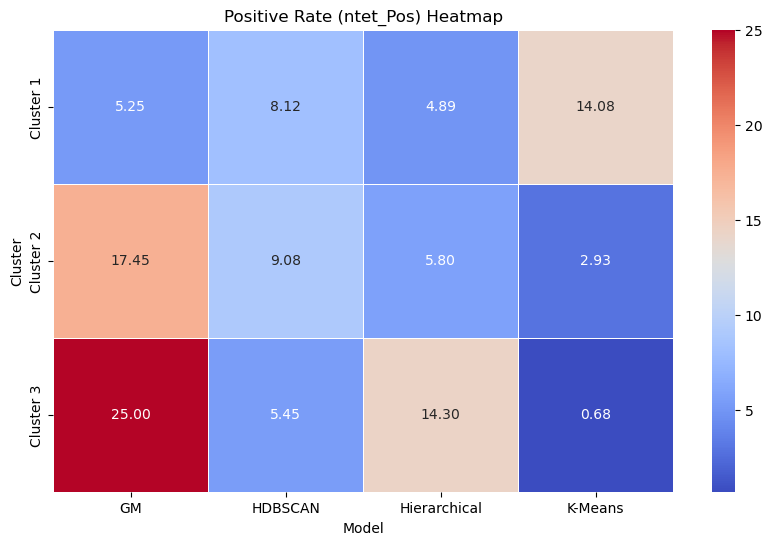

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_3524\2814283329.py:3: FutureWarning: In a future version of pandas all arguments of DataFrame.pivot will be keyword-only.
  df_pivot = df.pivot("Cluster", "Model", y_col)  # Cluster x Model 구조로 변환


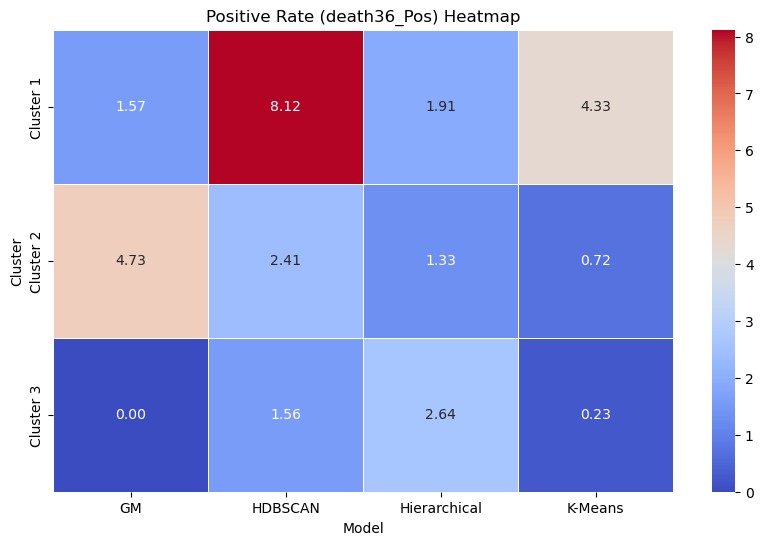

In [15]:
def plot_heatmap(y_col, title):
    plt.figure(figsize=(10, 6))
    df_pivot = df.pivot("Cluster", "Model", y_col)  # Cluster * Model 구조로 변환
    sns.heatmap(df_pivot, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

    plt.title(title)
    plt.show()

# 3가지 Positive Rate에 대해 Heatmap 생성
plot_heatmap("Positive Rate (iperr_Pos)", "Positive Rate (iperr_Pos) Heatmap")
plot_heatmap("Positive Rate (ntet_Pos)", "Positive Rate (ntet_Pos) Heatmap")
plot_heatmap("Positive Rate (death36_Pos)", "Positive Rate (death36_Pos) Heatmap")

In [6]:


# 중복 제거
final_columns = list(set(lower_cols))

# 데이터에서 필요한 칼럼들만 추출
knn_df_cols = knn_df.columns.intersection(final_columns)
# knn_df_ftd = knn_df[knn_df_cols]

# 데이터셋에 없는 칼럼 찾기
missing_columns = list(set(req_cols) - set(knn_df_cols))

# 결과 출력
# print("선택된 칼럼의 데이터:")
print("len(knn_df_cols):", len(knn_df_cols))
print(knn_df_cols)
print()
# print("\n데이터셋에 없는 칼럼:")
print("len(missing_columns):", len(missing_columns))
print(missing_columns)

len(knn_df_cols): 154
Index(['sex_sys_val', 'sex', 'mulg', 'bir1', 'bir2', 'bir3', 'bir4', 'prep',
       'dm', 'htn',
       ...
       'menifs', 'invfpod', 'ntet', 'ntetdt', 'ntety', 'ntetoy', 'ntetdty',
       'iperr', 'iperroy', 'iperrdt'],
      dtype='object', length=154)

len(missing_columns): 173
['ADMD', 'NESE', 'DATE36', 'STRDUD1', 'INHG', 'BHTCUT', 'SFTTHDT', 'PDADDTH', 'BSF3', 'FSF2', 'BHEADUK', 'IPERRDT', 'BSF2', 'INC3', 'SFTUH', 'PHH', 'FSFDT2', 'NTETOY', 'LBPD3', 'CMT2', 'birthdt_sys_val', 'APGUK1', 'BSFFS1', 'BTEM', 'MENIDT', 'ARRE36', 'BHEAD', 'NTETDT', 'PROM', 'FSFFS2', 'DATE362', 'GAGED', 'PADDR1', 'STERD2', 'FSF1', 'MCOU', 'IPERROY', 'MEDU', 'DM', 'MERR', 'PHUD6', 'PHUDOT', 'BDP_J', 'MENI', 'PDADDT', 'GRAN', 'GAGEW', 'SFT', 'BIRD', 'BTEMUK', 'NTET', 'PREP', 'FETC', 'BSFDT2', 'CMT1', 'LBP', 'INC1', 'PHUD7', 'BBBE', 'NIARVHFNC', 'PADDR2', 'BIRDH', 'BBBEUK', 'SEPS', 'NTETDTY', 'METC', 'ATBYN', 'BSFFS3', 'CHOR', 'STRDUD4', 'PROMN', 'PHUD2', 'age_sys_val', 'STRDUT1', 'ME

In [7]:
knn_df_cols

Index(['sex_sys_val', 'sex', 'mulg', 'bir1', 'bir2', 'bir3', 'bir4', 'prep',
       'dm', 'htn',
       ...
       'menifs', 'invfpod', 'ntet', 'ntetdt', 'ntety', 'ntetoy', 'ntetdty',
       'iperr', 'iperroy', 'iperrdt'],
      dtype='object', length=154)

In [8]:
filtered_knn_df = knn_df_ftd[(knn_df_ftd['ntet'] == 2) | (knn_df_ftd['iperr'] == 2)]

# 결과 출력
print("필터링된 데이터의 크기:", filtered_knn_df.shape)
print(filtered_knn_df)

필터링된 데이터의 크기: (1174, 43)
      subjnm  sex_sys_val     birthdt  mulg  bir1  bir2  bir3  bir4  prep  \
0        ㅂㅈㅂ            1  2013-01-05     1   NaN   NaN   NaN   NaN     1   
17       ㅎㅅㅈ            1  2013-02-09     1   NaN   NaN   NaN   NaN     1   
29      ㅈㅇㅎ2            2  2013-04-27     2   NaN   2.0   NaN   NaN     1   
40      ㅂㅈㅇ1            1  2013-07-13     2   1.0   NaN   NaN   NaN     2   
50       ㄱㅈㅇ            1  2013-03-29     1   NaN   NaN   NaN   NaN     1   
...      ...          ...         ...   ...   ...   ...   ...   ...   ...   
14474    ㄱㅅㅇ            1  2019-12-04     1   NaN   NaN   NaN   NaN     2   
14490    ㅊㅅㅇ            2  2019-07-26     1   NaN   NaN   NaN   NaN     2   
14491   ㄱㅅㅎ2            1  2019-07-26     2   NaN   2.0   NaN   NaN     2   
14500    ㅇㅇㄴ            2  2019-10-03     1   NaN   NaN   NaN   NaN     1   
14507    ㅇㅈㅇ            2  2019-11-30     1   NaN   NaN   NaN   NaN     2   

       htn  ...  paddr2  pdadty      pdaddt  pdadd

In [9]:
filtered_knn_df.to_csv(f"{raw_path}/knn_p3.csv")

In [10]:
for column in filtered_knn_df.columns:
    print(f"칼럼 이름: {column}")
    print(f"데이터 타입: {filtered_knn_df[column].dtype}")
    print(f"유니크한 값:")
    print(filtered_knn_df[column].unique())
    print("-" * 40)

칼럼 이름: subjnm
데이터 타입: object
유니크한 값:
['ㅂㅈㅂ' 'ㅎㅅㅈ' 'ㅈㅇㅎ2' 'ㅂㅈㅇ1' 'ㄱㅈㅇ' 'ㅇㅂㄹ' 'ㅊㅇㅎ' 'ㅂㅊㅎ' 'ㅈㅇㅈ3' 'ㅇㅈㅎ1' 'ㅇㄷㅇ2'
 'ㅈㅇㅈ2' 'ㅂㅁㄱ' 'ㅂㅂㄹ' 'ㅊㅈㅇ' 'ㅎㅎㅎ1' 'ㅎㅎㄴ2' 'ㅇㅈㅇ2' 'ㄹㅇㅇ' 'ㅂㄱㅎ' 'ㅇㅇㄹ' 'ㅇㅎㅈ'
 'ㅂㅈㅎ' 'ㅈㅎㅇ' 'ㄱㅎㄴ' 'ㅇㅈㅎ' 'ㅇㅎㅇ' 'ㄱㅎㄹ1' 'ㅁㄱㅇ2' 'ㅇㅊㅅ' 'ㄱㅇㅈ' 'ㅈㅎㄹ' 'ㅇㅇㅈ2'
 'ㅈㅈㅇ' 'ㅇㅅㅇ' 'ㄱㅁㅈ' 'ㅇㅁㅇ1' 'ㅈㅁㅅ1' 'ㅎㅎㅇ' 'ㄱㅈㅎ1' 'ㅇㅎㅎ' 'ㅅㅇㅎ' 'ㅊㄱㅅ' 'ㅈㅎㅈ'
 'ㅂㅇㅈ2' 'ㄱㅈㅎ2' 'ㅇㅎㅅ' 'ㅇㅇㅈ' 'ㄱㅈㅇ2' 'ㄱㄱㅇ' 'ㅊㅈ' 'ㄱㅇ' 'ㅈㅁㅇ' 'ㄱㄱㄹ' 'ㅂㅈㅎ2'
 'ㄱㅇㅅ2' 'ㅂㅎㅈ' 'ㅇㄱㅇ' 'ㅂㅈㅇ' 'ㅇㅂㅇ' 'ㄱㅅㅈ' 'ㅊㅇㅇ' 'ㅇㅈㅅ' 'ㅂㅇㄹ' 'ㅇㅅㅎ' 'ㅅㅂㅎ' 'ㄹㅌㅈ'
 'ㅇㅇㅁ' 'ㅈㅅㅎ' 'ㄱㄷㅇ' 'ㅂㅁㅇ' 'ㄱㅅㅁ3' 'ㅇㅁㄹ' 'ㅇㅈㅇ' 'ㅈㅈㅎ' 'ㄱㅁㅇ' 'ㅂㅅㅇ' 'ㅇㅎㅈㅇㄱ'
 'ㅊㅇㅈ' 'ㅈㅇㅇ' 'ㅂㅅㅎ' 'ㅂㅇㅁ' 'ㄱㅇㄹ' 'ㄱㅈㅇㅇㄱ2' 'ㅇㅅㅇㅇㄱ2' 'ㅊㅇㅁㅇㄱ' 'ㅂㅅㅈ' 'ㅇㅇㅎ'
 'ㅅㅇㅈ1' 'ㄱㅅㅎ' 'ㅊㅎㅅ' 'ㄱㄴㅇ' 'ㅈㅈㅇ1' 'ㄱㅅㅇ2' 'ㅈㅁㅅ' 'ㄱㅊㄹ' 'KHJB' 'ㅊㅈㅎ' 'ㅈㅎㅁ'
 'ㅇㄱㅎ' 'ㄱㅁㅅ' 'ㄱㅅㅎ2' 'ㅎㅁㅎ' 'ㅂㅅㅁ' 'ㅁㅎㅅ1' 'ㅅㅎㄹ2' 'ㄱㅅㅁ' 'ㄹㅅㅅ1' 'ㅈㅅㄹ2' 'ㅂㅇㅅ'
 'ㄹㅅㅅ2' 'ㅂㅅㅎ2' 'ㅎㅅㅂ' 'ㅇㅅㅇ1' 'ㅅㅇㅁ1' 'ㄴㅅㅎ' 'ㅇㅅㅁ1' 'ㄱㅎㅈ' 'ㅅㅈㅎ' 'ㅊㅅㅎ' 'ㄱㅈㅅ'
 'ㄱㅂㄱ' 'ㅈㅂㅇ' 'ㄴㅈㅅ' 'ㅈㅇㅇ2' 'ㅈㅁㅈ2' 'ㄱㅁㅇ2' 'ㅊㅁㄹ2' 'CB' 'ㄱㅈㅎ' 'ㅇㅁㅇ2' 'ㅂㅅㅇ2'
 'ㅇㅁㅈ' '김준서' '정이빈' 'ㄱㅇㅈ1' 'ㅁㅎㅇ' 'ㄱㅅㅇ' 'ㄱㅈㅁ' 'ㅈㅇㄹ' 'ㅎㅈㅇ' 'ㅊㅇㄹ1' 'ㅊㅇㄹ2'
 'ㅇㄷㅇ' 'ㄱㅇㅅ' 'ㅅㄱㅎ1' 'ㅇㅁㅈ1' 'ㅇㅁㅈ2' 'ㅁㅇㅇ' '

In [11]:
df = filtered_knn_df

# 1. 칼럼 'sex_sys_val' 처리
df = df[(df['sex_sys_val'] == 1) | (df['sex_sys_val'] == 2)]
df['sex_sys_val'] = df['sex_sys_val'].replace({1: 0, 2: 1})

# 2. 칼럼 'birthdt' 삭제
df.drop('birthdt', axis=1, inplace=True)

# 3. 칼럼 'mulg'로부터 더미 변수 생성
mulg_dummies = pd.get_dummies(df['mulg'], prefix='mulg', drop_first=False)
mulg_dummies.columns = ['mulg_single', 'mulg_twin', 'mulg_triplet']
df = pd.concat([df, mulg_dummies], axis=1)
df.drop('mulg', axis=1, inplace=True)

# 4. 'ntety', 'bir1', 'bir2', 'bir3' 값 변환
df['ntety'] = df['ntety'].fillna(0)
df['bir1'] = df['bir1'].fillna(0)
df['bir2'] = df['bir2'].fillna(0).replace({2: 1})
df['bir3'] = df['bir3'].fillna(0).replace({3: 1})

# 5. 칼럼 'bir4' 삭제
df.drop('bir4', axis=1, inplace=True)

# 6. 칼럼 'prep' 값 변환
df['prep'] = df['prep'].replace({1: 0, 2: 1})

# 7. 칼럼 'htn' 더미 변수 생성
htn_dummies = pd.get_dummies(df['htn'], prefix='htn')
df = pd.concat([df, htn_dummies], axis=1)
df.drop('htn', axis=1, inplace=True)

'''
# 8. 칼럼 'dm' 더미 변수 생성
dm_dummies = pd.get_dummies(df['dm'], prefix='dm')
df = pd.concat([df, dm_dummies], axis=1)
df.drop('dm', axis=1, inplace=True)
'''

# 9-11. 'prom' 및 'ster', 'resu'처리 (Convert to binary + Nan value)
df['prom'] = df['prom'].replace({1: 0, 2: 1, 3: 2})
df['ster'] = df['ster'].replace({1: 0, 2: 1, 3: 2})
df['resu'] = df['resu'].replace({1: 0, 2: 1, 3: 2})

# 11. 'delm' 값 변환
df['delm'] = df['delm'].replace({1: 0, 2: 1})

# 12. 'sterd2' 값 변환
df['sterd2'] = df['sterd2'].fillna(0).replace({2: 1})

# 14-18. 'resuo', 'resup', 'resui', 'resuh', 'resue' 처리
for column in ['resuo', 'resup', 'resui', 'resuh', 'resue']:
    if df[column].isnull().mean() < 0.5:
        df[column] = df[column].fillna(0).replace({1: 0, 2: 1})
    else:
        df.drop(column, axis=1, inplace=True)

# 19. 'pdad' 처리
if df['pdad'].isnull().mean() < 0.5:
    df['pdad'] = df['pdad'].replace({1: 0, 2: 1})
else:
    df.drop('pdad', axis=1, inplace=True)

# 20. 'paddr2' 값 변환
df['paddr2'] = df['paddr2'].fillna(0).replace({2: 1})

# 21. 'pdadty' 더미 변수 생성 후 조건에 따라 삭제
if df['pdadty'].isnull().mean() < 0.5:
    if (df['pdadty'] == 3).mean() < 0.5:
        pdadty_dummies = pd.get_dummies(df['pdadty'], prefix='pdadty')
        df = pd.concat([df, pdadty_dummies], axis=1)
    df.drop('pdadty', axis=1, inplace=True)

# 22. 'ntet', 'iperr' 값 변환
df['ntet'] = df['ntet'].replace({1: 0, 2: 1, 3: 0, 4: 1})
df['iperr'] = df['iperr'].replace({1: 0, 2: 1, 3: 0, 4: 1})

# 23. 'dcdhm5' 값 변환
df['dcdhm5'] = df['dcdhm5'].fillna(0).replace({5: 1})

# 24. Drop columns
df.drop('pdaddt', axis=1, inplace=True)
df.drop('ntetdt', axis=1, inplace=True)
df.drop('pdad', axis=1, inplace=True)
df.drop('paddr2', axis=1, inplace=True)
df.drop('pdadty', axis=1, inplace=True)
df.drop('pdaddth', axis=1, inplace=True)
df.drop('dthage1', axis=1, inplace=True)
df.drop('subjnm', axis=1, inplace=True)


# 데이터 전처리 후 결과 확인
print(df)

ftd_knn_df = df

       sex_sys_val  bir1  bir2  bir3  prep  prom  ster  delm  sterd2  gagew  \
0                0   0.0   0.0   0.0     0     0     1     1     0.0     27   
17               0   0.0   0.0   0.0     0     0     1     1     0.0     28   
29               1   0.0   1.0   0.0     0     0     1     1     0.0     27   
40               0   1.0   0.0   0.0     1     0     1     1     0.0     27   
50               0   0.0   0.0   0.0     0     1     1     1     0.0     28   
...            ...   ...   ...   ...   ...   ...   ...   ...     ...    ...   
14474            0   0.0   0.0   0.0     1     0     0     1     0.0     26   
14490            1   0.0   0.0   0.0     1     1     1     0     1.0     25   
14491            0   0.0   1.0   0.0     1     1     1     1     1.0     25   
14500            1   0.0   0.0   0.0     0     0     1     1     1.0     26   
14507            1   0.0   0.0   0.0     1     1     1     1     1.0     27   

       ...  ntet  ntety  iperr  dcdhm5  mulg_single

C:\Users\AIWM_W01\AppData\Local\Temp\ipykernel_5112\743477656.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['sex_sys_val'] = df['sex_sys_val'].replace({1: 0, 2: 1})
C:\Users\AIWM_W01\AppData\Local\Temp\ipykernel_5112\743477656.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop('birthdt', axis=1, inplace=True)


In [12]:
def analyse_dataframe(df):
    # NaN 개수, 비율 및 고유 값 개수 계산
    nan_counts = df.isnull().sum()
    nan_ratios = df.isnull().mean() * 100  # 백분율로 표시
    unique_values_count = df.nunique()

    # 결과 데이터 프레임 생성
    analysis_result = pd.DataFrame({
        'NaN Counts': nan_counts,
        'NaN Ratios (%)': nan_ratios,
        'Unique Values Count': unique_values_count
    })

    return analysis_result

analyse_dataframe(ftd_knn_df)

,NaN Counts,NaN Ratios (%),Unique Values Count
sex_sys_val,0,0.000000,2
bir1,0,0.000000,2
bir2,0,0.000000,2
bir3,0,0.000000,2
prep,0,0.000000,2
prom,0,0.000000,3
ster,0,0.000000,3
delm,0,0.000000,2
sterd2,0,0.000000,2
gagew,0,0.000000,15


In [13]:
def fill_na_with_mean(df, columns, decimal_places=None):
    """
    지정된 칼럼의 NaN 값을 해당 칼럼의 평균값으로 채웁니다. 
    필요한 경우 평균값을 정수로 변환하거나 소수점을 지정된 자리수로 반올림합니다.
    """
    for column in columns:
        mean_value = df[column].mean()
        if decimal_places is not None:
            mean_value = round(mean_value, decimal_places)
        elif decimal_places is None and column in integer_columns:
            mean_value = int(round(mean_value))
        df[column] = df[column].fillna(mean_value)
    return df

# 데이터프레임 df를 사용한다고 가정
# 정수로 채워야 하는 칼럼
integer_columns = ['apgs1', 'apgs5']
ftd_knn_df = fill_na_with_mean(ftd_knn_df, integer_columns, decimal_places=0)
# 소수점 두 자리로 채워야 하는 칼럼
decimal_columns = ['bhei', 'bhead', 'btem', 'bbph']
ftd_knn_df = fill_na_with_mean(ftd_knn_df, decimal_columns, decimal_places=2)

ftd_knn_df

,sex_sys_val,bir1,bir2,bir3,prep,prom,ster,delm,sterd2,gagew,...,ntet,ntety,iperr,dcdhm5,mulg_single,mulg_twin,mulg_triplet,htn_1,htn_2,htn_3
0,0,0.0,0.0,0.0,0,0,1,1,0.0,27,...,1,1.0,0,0.0,1,0,0,0,0,1
17,0,0.0,0.0,0.0,0,0,1,1,0.0,28,...,1,2.0,0,0.0,1,0,0,0,1,0
29,1,0.0,1.0,0.0,0,0,1,1,0.0,27,...,1,2.0,0,0.0,0,1,0,1,0,0
40,0,1.0,0.0,0.0,1,0,1,1,0.0,27,...,1,2.0,0,0.0,0,1,0,1,0,0
50,0,0.0,0.0,0.0,0,1,1,1,0.0,28,...,0,0.0,1,0.0,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14474,0,0.0,0.0,0.0,1,0,0,1,0.0,26,...,1,1.0,0,0.0,1,0,0,0,1,0
14490,1,0.0,0.0,0.0,1,1,1,0,1.0,25,...,0,0.0,1,0.0,1,0,0,1,0,0
14491,0,0.0,1.0,0.0,1,1,1,1,1.0,25,...,1,2.0,0,0.0,0,1,0,1,0,0
14500,1,0.0,0.0,0.0,0,0,1,1,1.0,26,...,1,2.0,0,0.0,1,0,0,1,0,0


In [14]:
analyse_dataframe(ftd_knn_df)

,NaN Counts,NaN Ratios (%),Unique Values Count
sex_sys_val,0,0.0,2
bir1,0,0.0,2
bir2,0,0.0,2
bir3,0,0.0,2
prep,0,0.0,2
prom,0,0.0,3
ster,0,0.0,3
delm,0,0.0,2
sterd2,0,0.0,2
gagew,0,0.0,15


In [15]:
ftd_knn_df.to_csv(f"{raw_path}/knn_p4_fin.csv")

In [123]:
## CLUSTERING

'''
def perform_hierarchical_clustering(df, n_clusters):
    """
    Hierarchical clustering을 수행하고 클러스터 할당 결과를 반환합니다.

    Parameters:
        df (pandas.DataFrame): 클러스터링할 데이터프레임.
        n_clusters (int): 생성할 클러스터의 수.

    Returns:
        array: 각 데이터 포인트의 클러스터 할당 정보.
    """
    # linkage 함수를 사용해 계층적 클러스터 생성
    Z = linkage(df, method='ward')  # Ward 방법을 사용

    # Dendrogram 그리기 (시각화를 위해)
    plt.figure(figsize=(10, 7))
    dendrogram(Z)
    plt.title("Dendrogram")
    plt.xlabel('Data Points')
    plt.ylabel('Euclidean Distance')
    plt.show()

    # fcluster 함수를 사용해 데이터 포인트에 클러스터 라벨 할당
    clusters = fcluster(Z, t=n_clusters, criterion='maxclust')
    return clusters
'''

For n_clusters = 2 The average silhouette_score is : 0.11290105766142103
For n_clusters = 3 The average silhouette_score is : 0.09728612518857442
For n_clusters = 4 The average silhouette_score is : 0.07246467113094282
For n_clusters = 5 The average silhouette_score is : 0.08665260715686983
For n_clusters = 6 The average silhouette_score is : 0.0853346227124348
For n_clusters = 7 The average silhouette_score is : 0.09362713006483946
For n_clusters = 8 The average silhouette_score is : 0.0972106750679064
For n_clusters = 9 The average silhouette_score is : 0.11047667422357514
Best number of clusters: 2


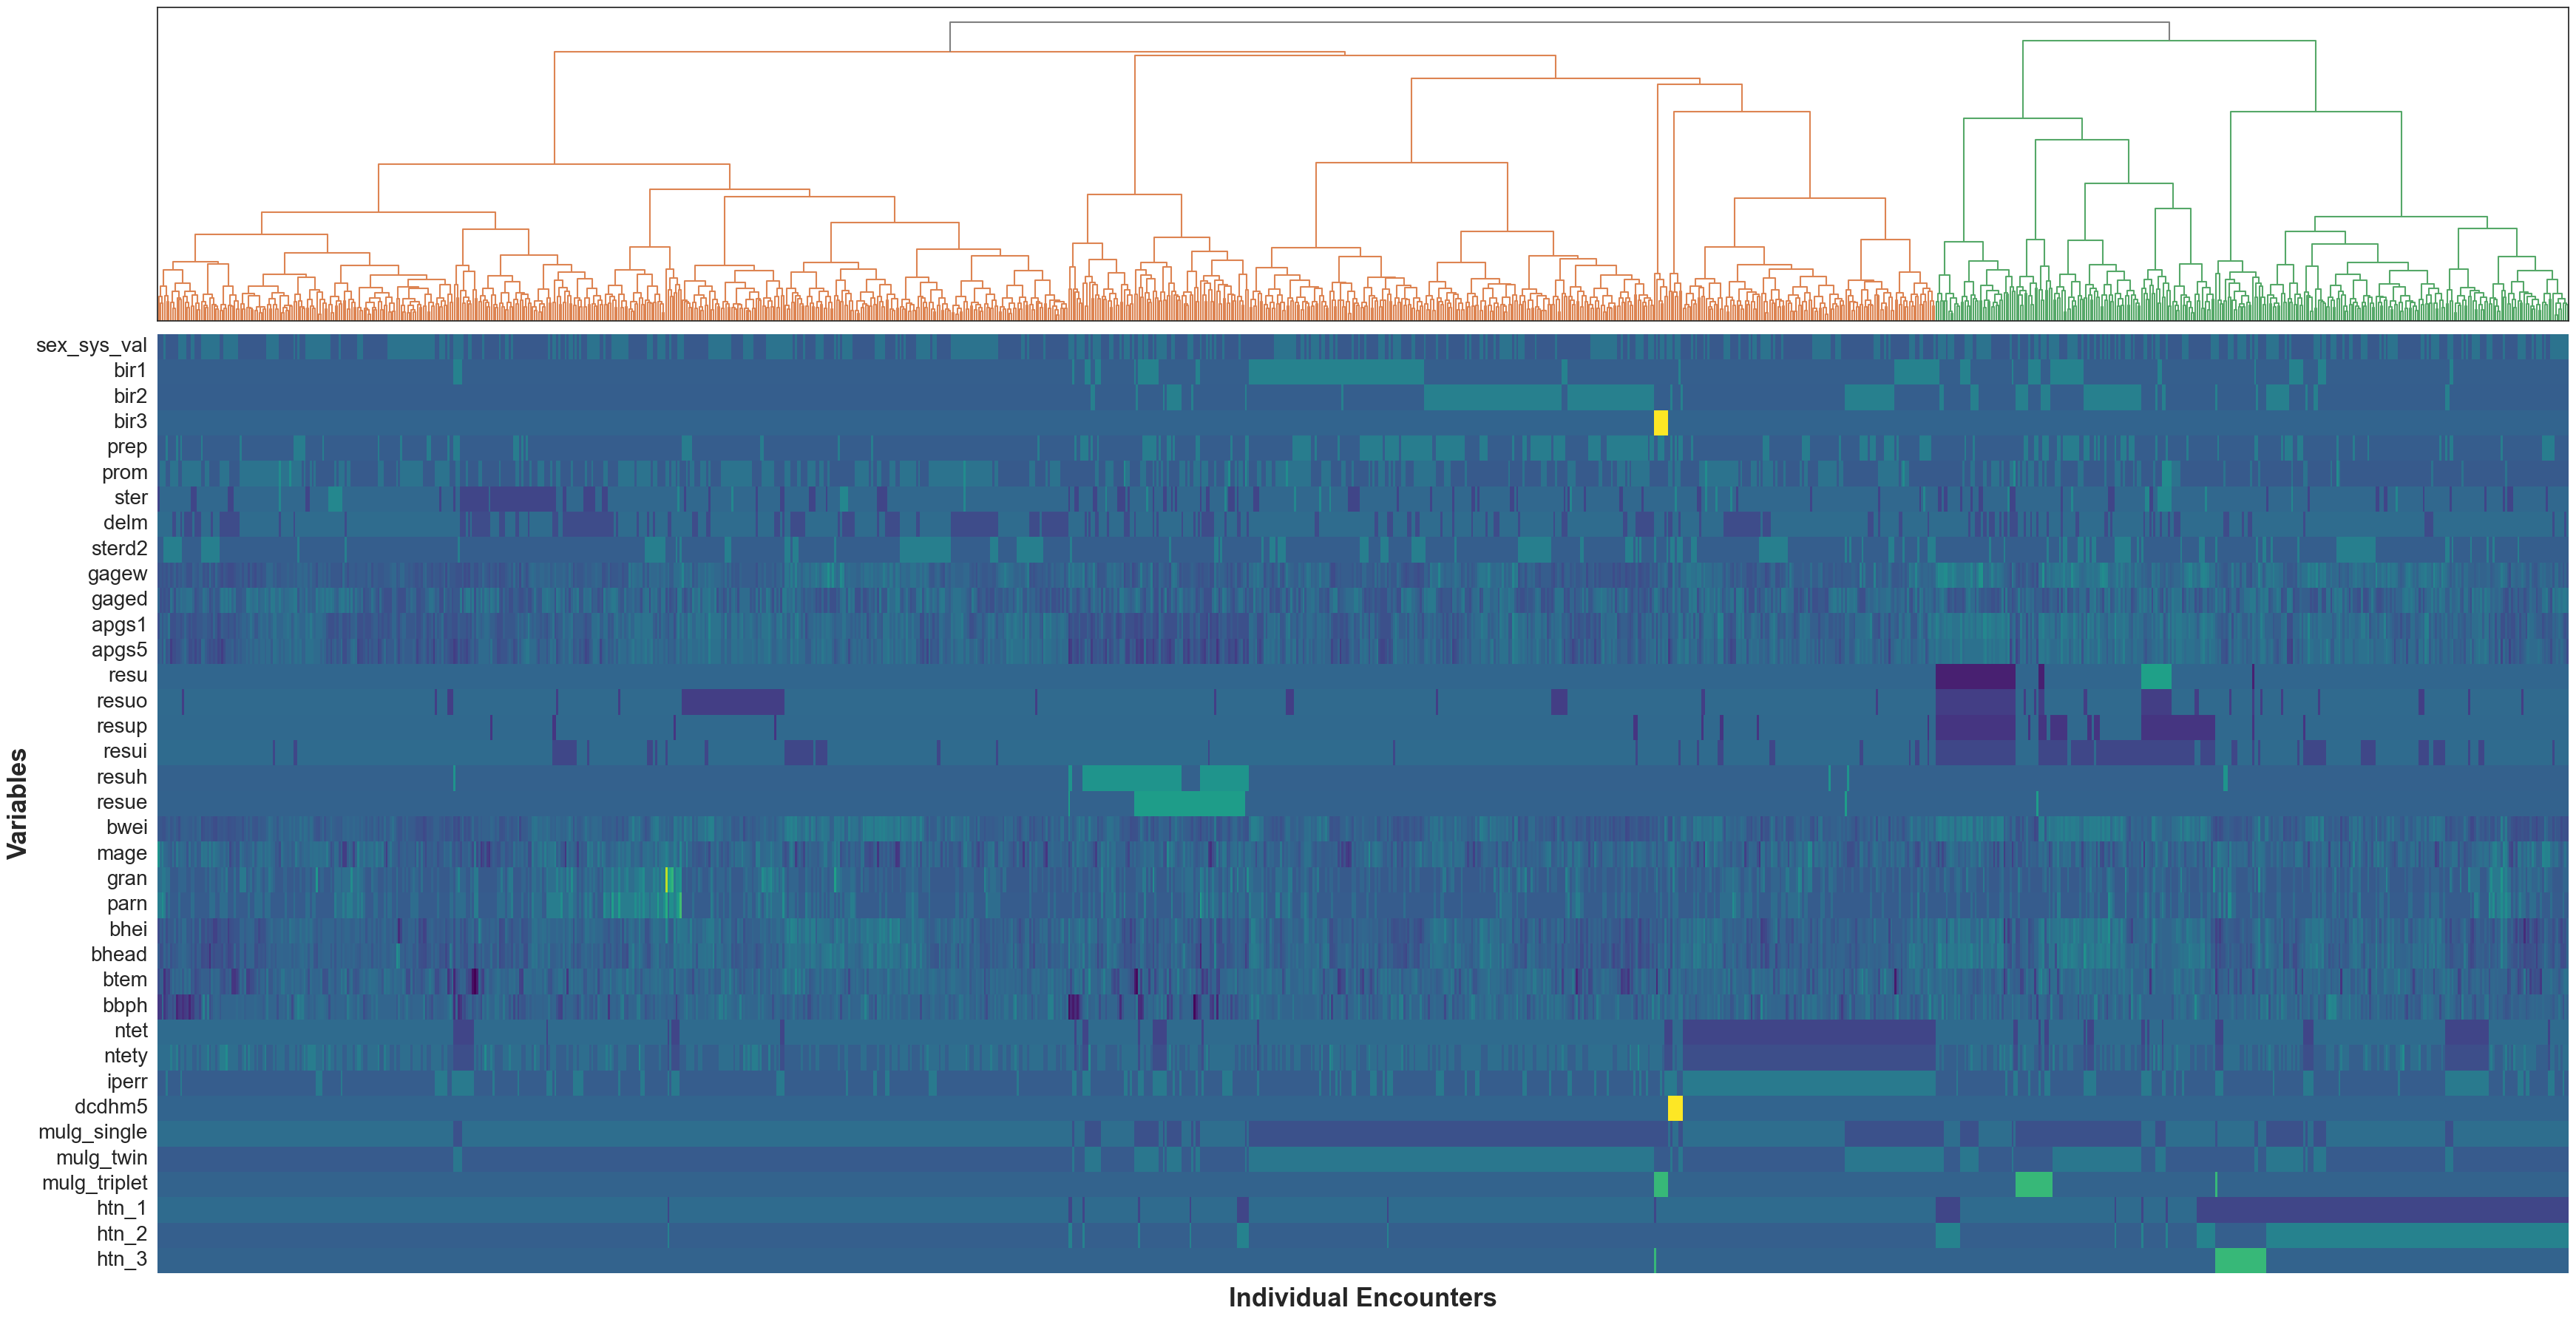

          sex_sys_val  bir1  bir2  bir3  prep  prom  ster  delm  sterd2  \
subj_ind                                                                  
0                   0   0.0   0.0   0.0     0     0     1     1     0.0   
17                  0   0.0   0.0   0.0     0     0     1     1     0.0   
29                  1   0.0   1.0   0.0     0     0     1     1     0.0   
40                  0   1.0   0.0   0.0     1     0     1     1     0.0   
50                  0   0.0   0.0   0.0     0     1     1     1     0.0   
...               ...   ...   ...   ...   ...   ...   ...   ...     ...   
14474               0   0.0   0.0   0.0     1     0     0     1     0.0   
14490               1   0.0   0.0   0.0     1     1     1     0     1.0   
14491               0   0.0   1.0   0.0     1     1     1     1     1.0   
14500               1   0.0   0.0   0.0     0     0     1     1     1.0   
14507               1   0.0   0.0   0.0     1     1     1     1     1.0   

          gagew  ...  nt

In [57]:
# Data import
ftd_knn_df = pd.read_csv(f"{raw_path}/knn_p4_fin.csv")
ftd_knn_df.rename(columns={'Unnamed: 0': 'subj_ind'}, inplace=True)
ftd_knn_df.set_index('subj_ind', inplace=True)

# 데이터 표준화 (이진 값을 제외하고 표준화 수행)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(ftd_knn_df)

# scaled_data 반영
ftd_scd_knn_df = pd.DataFrame(scaled_data, index=ftd_knn_df.index, columns=ftd_knn_df.columns)

Z_objects = linkage(ftd_scd_knn_df, method='ward')

# 실루엣 점수를 통한 최적의 클러스터 수 찾기
silhouette_scores = []
range_n_clusters = list(range(2, 10))  # 클러스터 수를 2부터 10까지 시도
for n_clusters in range_n_clusters:
    cluster_labels = fcluster(Z_objects, t=n_clusters, criterion='maxclust')
    silhouette_avg = silhouette_score(ftd_scd_knn_df, cluster_labels)
    silhouette_scores.append(silhouette_avg)
    print("For n_clusters =", n_clusters, "The average silhouette_score is :", silhouette_avg)

best_n_clusters = range_n_clusters[np.argmax(silhouette_scores)]
print("Best number of clusters:", best_n_clusters)

# 최적의 클러스터 수를 사용하여 클러스터 라벨을 다시 할당
final_cluster_labels = fcluster(Z_objects, t=best_n_clusters, criterion='maxclust')

# 덴드로그램 및 히트맵 시각화
sns.set(style="white")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(35, 18), gridspec_kw={'height_ratios': [1, 3]})

# Dendrogram
dendro_objects = dendrogram(Z_objects, ax=ax1, orientation='top', color_threshold=0.94 * max(Z_objects[:, 2]), above_threshold_color='grey')
ax1.set_xticks([])
ax1.set_yticks([])

# 데이터 정렬 및 히트맵 추가
sorted_idx = dendro_objects['leaves']
data_sorted = ftd_scd_knn_df.iloc[sorted_idx]

# Heatmap
sns.heatmap(data_sorted.T
            , ax=ax2
            , cbar=False
            , cmap='viridis'
            , yticklabels=ftd_scd_knn_df.columns
           )
ax2.set_xlabel('Individual Encounters', fontsize=25, fontweight='bold')
ax2.set_ylabel('Variables', fontsize=25, fontweight='bold')
ax2.set_xticklabels([])
ax2.tick_params(axis='y', labelsize=20)  # Y축 레이블의 글자 크기 조절 (축소)

plt.tight_layout()
plt.show()

# 클러스터 라벨을 데이터프레임에 추가
ftd_knn_df['Cluster_Labels'] = final_cluster_labels
# 결과 출력
print(ftd_knn_df)

In [58]:
# len(ftd_knn_df.columns[:-1])
analyse_dataframe(ftd_knn_df)

,NaN Counts,NaN Ratios (%),Unique Values Count
sex_sys_val,0,0.0,2
bir1,0,0.0,2
bir2,0,0.0,2
bir3,0,0.0,2
prep,0,0.0,2
prom,0,0.0,3
ster,0,0.0,3
delm,0,0.0,2
sterd2,0,0.0,2
gagew,0,0.0,15


In [36]:
print(ftd_knn_df, '\n\n', ftd_scd_knn_df)

          sex_sys_val  bir1  bir2  bir3  prep  prom  ster  delm  sterd2  \
subj_ind                                                                  
0                   0   0.0   0.0   0.0     0     0     1     1     0.0   
17                  0   0.0   0.0   0.0     0     0     1     1     0.0   
29                  1   0.0   1.0   0.0     0     0     1     1     0.0   
40                  0   1.0   0.0   0.0     1     0     1     1     0.0   
50                  0   0.0   0.0   0.0     0     1     1     1     0.0   
...               ...   ...   ...   ...   ...   ...   ...   ...     ...   
14474               0   0.0   0.0   0.0     1     0     0     1     0.0   
14490               1   0.0   0.0   0.0     1     1     1     0     1.0   
14491               0   0.0   1.0   0.0     1     1     1     1     1.0   
14500               1   0.0   0.0   0.0     0     0     1     1     1.0   
14507               1   0.0   0.0   0.0     1     1     1     1     1.0   

          gagew  ...  nt

In [59]:
filtered_knn_df = pd.read_csv(f"{raw_path}/knn_p1.csv")
filtered_knn_df.rename(columns={'Unnamed: 0': 'subj_ind'}, inplace=True)
filtered_knn_df.set_index('subj_ind', inplace=True)
filtered_knn_df.drop('subjnm', axis=1, inplace=True)
filtered_knn_df.rename(columns={'dthage1': 'death_label'}, inplace=True)
filtered_knn_df['death_label'] = filtered_knn_df['death_label'].notna().astype(int)

dthage_data = filtered_knn_df['death_label']
print(dthage_data)

subj_ind
0        0
17       0
29       0
40       0
50       0
        ..
14474    0
14490    0
14491    0
14500    0
14507    0
Name: death_label, Length: 1174, dtype: int32


In [60]:
ftd_knn_df = ftd_knn_df.merge(dthage_data, left_index=True, right_index=True, how='left')
ftd_knn_df

,sex_sys_val,bir1,bir2,bir3,prep,prom,ster,delm,sterd2,gagew,...,iperr,dcdhm5,mulg_single,mulg_twin,mulg_triplet,htn_1,htn_2,htn_3,Cluster_Labels,death_label
subj_ind,,,,,,,,,,,,,,,,,,,,,
0,0,0.0,0.0,0.0,0,0,1,1,0.0,27,...,0,0.0,1,0,0,0,0,1,2,0
17,0,0.0,0.0,0.0,0,0,1,1,0.0,28,...,0,0.0,1,0,0,0,1,0,2,0
29,1,0.0,1.0,0.0,0,0,1,1,0.0,27,...,0,0.0,0,1,0,1,0,0,1,0
40,0,1.0,0.0,0.0,1,0,1,1,0.0,27,...,0,0.0,0,1,0,1,0,0,1,0
50,0,0.0,0.0,0.0,0,1,1,1,0.0,28,...,1,0.0,1,0,0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14474,0,0.0,0.0,0.0,1,0,0,1,0.0,26,...,0,0.0,1,0,0,0,1,0,2,0
14490,1,0.0,0.0,0.0,1,1,1,0,1.0,25,...,1,0.0,1,0,0,1,0,0,1,0
14491,0,0.0,1.0,0.0,1,1,1,1,1.0,25,...,0,0.0,0,1,0,1,0,0,1,0


In [61]:
ftd_knn_df.describe()
ftd_knn_df.to_csv(f"{crt_path}/knn_standardised_p2+dthage_M02.csv")

In [64]:
ftd_knn_df = pd.read_csv(f"{crt_path}/knn_standardised_p2+dthage_M02.csv", index_col='subj_ind')
print(ftd_knn_df['Cluster_Labels'].value_counts())
print(ftd_knn_df.isnull().sum())

1    865
2    308
Name: Cluster_Labels, dtype: int64
sex_sys_val       0
bir1              0
bir2              0
bir3              0
prep              0
prom              0
ster              0
delm              0
sterd2            0
gagew             0
gaged             0
apgs1             0
apgs5             0
resu              0
resuo             0
resup             0
resui             0
resuh             0
resue             0
bwei              0
mage              0
gran              0
parn              0
bhei              0
bhead             0
btem              0
bbph              0
ntet              0
ntety             0
iperr             0
dcdhm5            0
mulg_single       0
mulg_twin         0
mulg_triplet      0
htn_1             0
htn_2             0
htn_3             0
Cluster_Labels    0
death_label       0
dtype: int64


In [74]:
## WILCOXON TESTING
ftd_knn_df = pd.read_csv(f"{crt_path}/knn_standardised_p2+dthage_M02.csv", index_col='subj_ind')

# 결과 저장을 위한 DataFrame 초기화
stats_df = pd.DataFrame()
p_values_df = pd.DataFrame()

# 각 클러스터 및 변수에 대해 계산
for i in range(1, (best_n_clusters+1)):
    cluster_data = ftd_knn_df[ftd_knn_df['Cluster_Labels'] == i]
    outside_data = ftd_knn_df[ftd_knn_df['Cluster_Labels'] != i]
    stats = {}
    p_values = {}

    for column in ftd_knn_df.columns[:-2]:  # 'Cluster_Labels'와 'death_label' 컬럼 제외
        u_stat, p_value = mannwhitneyu(cluster_data[column]
                                       , outside_data[column]
                                       , alternative='two-sided'
                                      )
        mean_val = cluster_data[column].mean()
        std_dev = cluster_data[column].std()

        # 평균과 표준편차 저장
        stats[column] = f"{mean_val:.2f} ± {std_dev:.4f}"
        
        # p-value의 조건에 따라 형식 지정
        if p_value < 0.05:
            if p_value < 0.0001:
                formatted_p_value = f"{p_value:.4e}"  # 매우 작은 값에 대해 지수 표현식 사용
            else:
                formatted_p_value = f"{p_value:.4f}"
            p_values[column] = formatted_p_value
        else:
            p_values[column] = "n.s."

    stats_df[f'Cluster {i}'] = pd.Series(stats)
    p_values_df[f'Cluster {i}'] = pd.Series(p_values)

# 결과 출력
print("Mean and Standard Deviation:")
print(stats_df)
print("\nP-values:")
print(p_values_df)

Mean and Standard Deviation:
                      Cluster 1          Cluster 2
sex_sys_val       0.43 ± 0.4960      0.45 ± 0.4981
bir1              0.15 ± 0.3609      0.15 ± 0.3570
bir2              0.17 ± 0.3778      0.21 ± 0.4110
bir3              0.01 ± 0.0896      0.00 ± 0.0000
prep              0.23 ± 0.4233      0.19 ± 0.3967
prom              0.49 ± 0.5205      0.21 ± 0.4611
ster              0.88 ± 0.4135      0.94 ± 0.3788
delm              0.72 ± 0.4503      0.85 ± 0.3602
sterd2            0.20 ± 0.4011      0.19 ± 0.3942
gagew            25.79 ± 2.2013     28.07 ± 2.5603
gaged             2.87 ± 2.0021      2.97 ± 2.0233
apgs1             3.53 ± 1.8262      4.72 ± 1.8721
apgs5             5.89 ± 1.8850      6.98 ± 1.6599
resu              1.00 ± 0.0000      0.91 ± 0.4250
resuo             0.91 ± 0.2816      0.76 ± 0.4259
resup             0.99 ± 0.1170      0.69 ± 0.4626
resui             0.93 ± 0.2600      0.48 ± 0.5005
resuh             0.09 ± 0.2849      0.01 ± 0.0805
re

In [76]:
stats_df.to_excel(f"{crt_path}/knn_wilcoxon_M02_siluette.xlsx")
p_values_df.to_excel(f"{crt_path}/knn_wilcoxon_M02_p_val_siluette.xlsx")

In [73]:
## DEATH RATIO
results_df = pd.DataFrame()

# 각 클러스터의 사망률 계산
for i in range(1, (best_n_clusters+1)):
    # 해당 클러스터 데이터 추출
    cluster_data = ftd_knn_df[ftd_knn_df['Cluster_Labels'] == i]
    total_count = cluster_data.shape[0]
    death_count = cluster_data['death_label'].sum()
    
    # 사망률 계산
    mortality_rate = (death_count / total_count) * 100
    
    # 결과 저장
    results_df.loc[f'Cluster {i}', 'Total'] = total_count
    results_df.loc[f'Cluster {i}', 'Deaths'] = death_count
    results_df.loc[f'Cluster {i}', 'Mortality Rate'] = f"{mortality_rate:.2f}%"
    results_df.loc[f'Cluster {i}', 'Deaths / Total'] = f"{death_count} / {total_count}"

# 결과 출력
print(results_df)

           Total  Deaths Mortality Rate Deaths / Total
Cluster 1  865.0    11.0          1.27%       11 / 865
Cluster 2  308.0     1.0          0.32%        1 / 308



1. blank value & nan value 50% 이하 : 소거
2. 칼럼 '*dt' 등 disease related columns, 'ntet', 'iperr', 'subjnm' 제거
3. 데이터 값들을 one-hot encoding, vector화

4. clustering